In [1]:
import scarches as sca
#import torch
import scanpy as sc
import pandas as pd
import random, numpy as np
random.seed(0)
np.random.seed(0)

import seaborn as sns
from matplotlib import pyplot as plt
import os
import time
import pickle
from itertools import chain
import itertools
from tqdm.auto import tqdm
from scipy.sparse import csr_matrix

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

'''
IMPORTANT:
### To Make Python hashing deterministic, set these environment variables BEFORE starting Jupyter Notebook!
### Otherwise the result of Leiden-clustering may lead to different results upon Kernel restart!

export PYTHONHASHSEED=0        # Python's hash randomization
export NUMBA_NUM_THREADS=1      # must not change after numba loads
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
export OPENBLAS_NUM_THREADS=1
# then start Jupyter/Lab/Kernel from the same shell

'''

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.3-CAPI-1.17.3) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/spatialdata/__init__.py:11: UserWarning: Geopandas was set to use PyGEOS, changing to shapely 2.0 with:

	geopandas.options.use_pygeos = True

If you intended to use PyGEOS, set the option to False.
  _check_geopandas_using_shapely()
 captum (see https://github.com/pytorch/captum).


"\nIMPORTANT:\n### To Make Python hashing deterministic, set these environment variables BEFORE starting Jupyter Notebook!\n### Otherwise the result of Leiden-clustering may lead to different results upon Kernel restart!\n\nexport PYTHONHASHSEED=0        # Python's hash randomization\nexport NUMBA_NUM_THREADS=1      # must not change after numba loads\nexport OMP_NUM_THREADS=1\nexport MKL_NUM_THREADS=1\nexport OPENBLAS_NUM_THREADS=1\n# then start Jupyter/Lab/Kernel from the same shell\n\n"

# FUNCTIONS

In [2]:
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes")

####=============================
## Return the set of parameters in search_space as a string, to distinguish models trained with different parameter sets
def return_parameter_set(final_search_space):
    
    # Create a list of dictionaries where each dictionary represents a set of hyperparameters
    parameter_combinations = list(itertools.product(*final_search_space.values()))
    hyperparameter_sets = [{key: value for key, value in zip(final_search_space.keys(), combination)} for combination in parameter_combinations]
    
    # Print the list of hyperparameter sets
    for n,hyperparameters in enumerate(hyperparameter_sets):
        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in hyperparameters.items()]
        param_set_string='-'.join(pairs)

    return param_set_string

####=============================
def load_sparse_df(path_pickle, curr_names):
    """
    Load the labeled SparseDataFrame, reindex to current adata.obs_names
    (handles subsetting), and convert back to CSR sparse matrix.
    """
    sdf = pd.read_pickle(path_pickle)             # labeled SparseDataFrame
    # Reindex ensures correct order and lets you subset
    sdf = sdf.reindex(index=curr_names, columns=curr_names)
    return sdf.sparse.to_coo().tocsr()

####=============================
def leiden_own(adata,neighbors_key,resolution,key_added):
    import igraph as ig
    import leidenalg as la
    from scipy.sparse import coo_matrix
    import numpy as np

    conn_key=f'{neighbors_key}_connectivities'
    A = adata.obsp[conn_key].tocsr()
    A.sort_indices()
    
    # Convert to igraph with weights
    coo = A.tocoo()
    g = ig.Graph(n=A.shape[0], edges=list(zip(coo.row, coo.col)), directed=False)
    g.es["weight"] = coo.data.tolist()
    
    # Deterministic Leiden (Reichardt–Bornholdt, same as Scanpy default)
    part = la.find_partition(
        g,
        la.RBConfigurationVertexPartition,
        weights=g.es["weight"],
        resolution_parameter=resolution,
        seed=0,                      # <-- critical
    )
    
    labels = np.array(part.membership, dtype=object)
    adata.obs[key_added] = labels.astype(str)

    return adata



# LOAD BATCH CORRECTED DATA

In [ ]:
#proc_dir='../../xenium_data/processed_data/baysor_processed_output'

ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']



## SET NUMBER OF TOP HVG
n_top_genes=4000

COUNTS_THR_MIN=200
GENES_THR_MIN=200
MT_THR=0.2

adata_dict={}
adata_dict_norm={}

batch2_bool_list=['','_no_batch_2']

for intron_status in ['with_intron','without_intron'][:]:
    adata_dict[intron_status]={}
    
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)


    
        ## LOAD ADATA AND PATIENT METADATA
        #fn=os.path.join('../../data/',ref_genome+'_data_QC_norm.h5ad')
        fn=os.path.join(f'../../data/{ref_genome}_{intron_status}_data_QC_norm.h5ad')
        adata=sc.read_h5ad(fn)
    
        
        adata.var=adata.var.reset_index().set_index('gene_id',drop=False).rename(columns={'index':'HGNC_NAME'})
        adata.var_names_make_unique()
    
        ## Add celbender corrected counts as default X layer
        adata.X=adata.layers['cellbender']
    
        ## Read metadata
        metadata=pd.read_excel('../../data/ScSeq_Patinfo_270623.xlsx',header=1,index_col=0)
        metadata.index=[x.replace(' ','') for x in metadata.index]
    
        ## Add metadata to .obs df of Anndata
        met_cols_for_corr=['Age','Sex','Hypertension','AHA classification','Diabetes','Smoking','Dyslipidemia','CHD','BMI','Statin']
        for met_col in met_cols_for_corr:
            d=pd.Series(metadata[met_col],index=metadata.index).to_dict()
            adata.obs[met_col]=adata.obs['patient'].map(d)
    
        ## Add new column to .obs where Diseased cells get further split up as 'stable' or 'unstable'
        adata.obs['Stability']=adata.obs['condition']
        d=pd.Series(metadata['stability (+/-)'],index=metadata.index).to_dict()
        adata.obs['Stability']=adata.obs['patient'].map(d)
        adata.obs['Stability']=adata.obs['Stability'].replace({r'+':'unstable',r'-':'stable'})
        adata.obs.loc[adata.obs['condition']=='H','Stability']='healthy'
    
        ##  Add column with sequencing facility information
        adata.obs.loc[:,'seq_facility']='HH'
        adata.obs.loc[adata.obs['batch'].isin(['5','6']),'seq_facility']='NG'
        
        ## Add log UMI and genes counts to .obs dataframe
        for coln in ['n_counts_raw','n_genes_raw','n_counts_cellbender','n_genes_cellbender']:
            adata.obs['log_'+coln]=np.log10(adata.obs[coln])
    
        ## Save adata.obs for usage in Harmony as metadata dataframe
        #adata.obs.to_csv('../../data/'+ref_genome+'_adata_obs_with_metadata.csv')
        
        
        ## EXTRACT THE HVG GENES 
        sc.pp.highly_variable_genes(
            adata,
            n_top_genes=n_top_genes,
            subset=False,
            layer="cellbender",
            flavor="seurat_v3",
            #batch_key='batch',
        )
    
        ## Drop low quality cells
        adata=adata[(adata.obs['mt_frac']<=MT_THR)&\
                        (adata.obs['n_counts_cellbender']>COUNTS_THR_MIN)&\
                        (adata.obs['n_genes_cellbender']>GENES_THR_MIN)\
                        ,:].copy()
    
        ## LOAD SCPOLI CELLTYPES
        #fn=os.path.join('../../data/',f'{ref_genome}_scpoli_pred_celltypes.csv.gz')
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_scpoli_pred_celltypes.csv.gz')
        scpoli_preds=pd.read_csv(fn,index_col=0)

        #barcodes_scpoli = scpoli_preds.reset_index()['index'].str.split('-',expand=True)[0]
        #barcodes_adata = adata.obs.reset_index()['index'].str.split('-',expand=True)[0]
        
        #comm_idx=list(set(barcodes_scpoli) & set(barcodes_adata))
        #print('barcodes_scpoli',len(barcodes_scpoli),'barcodes_adata',len(barcodes_adata),'comm idx',len(comm_idx))

        
        comm_idx=list(set(scpoli_preds.index) & set(adata.obs.index))
        adata=adata[comm_idx,:].copy()
        scpoli_preds=scpoli_preds.loc[comm_idx,:].copy()
        print('adata shape',adata.shape,'scpoli repr. shape',scpoli_preds.shape,'comm idx:',len(comm_idx))
        adata.obs[['scpoli_pred_celltype','scpoli_uncert']]=scpoli_preds.values
    
        ## Subset to HVG genes
        #sc.pl.highly_variable_genes(adata,log=True)
        adata_hvg=adata[:,adata.var['highly_variable']==True]
    
        ## Sort gene names
        hvg_genes=adata_hvg.var.index.tolist()
        hvg_genes.sort()
        adata_hvg=adata_hvg[:,hvg_genes]
    
        ## Add information to the original adata object as well
        adata.var['highly_variable_'+str(n_top_genes)]=adata.var['highly_variable'].values
        
    
        ## In one case drop batch 2 patients, as their cells have abnormal distribution on the UMAP after scVI correction
        adata_dict[intron_status][ref_genome]=adata
        



# Load the trained scVI models and latent representation

In [ ]:
import scvi
###====== DEFINE HYPERPARAMETERS FOR MODELS TO TRAIN
search_space={
        "n_hidden":[128,256],
        "n_latent":[10,20], #20
        "n_layers": [1,2], #2
        #"lr": [1e-4, 1e-3],
        'gene_likelihood':['zinb'],
        'max_epochs':[600]}

# Create a list of dictionaries where each dictionary represents a set of hyperparameters
parameter_combinations = list(itertools.product(*search_space.values()))
hyperparameter_sets = [{key: value for key, value in zip(search_space.keys(), combination)} for combination in parameter_combinations]


## SET NUMBER OF TOP HVG
n_top_genes=4000


batch2_bool_list=['','_no_batch_2']

adata_vae_dict={}

for intron_status in ['with_intron','without_intron'][:]:
    adata_vae_dict[intron_status]={}
    
    for ref_genome in ref_genomes[:1]:

    
        adata=adata_dict[intron_status][ref_genome]
        
        adata_vae_dict[intron_status][ref_genome]={}
        
    
        for batch2_bool in batch2_bool_list[:]:
            
            print(f'====Batch2 bool:{batch2_bool}====')
            
            if batch2_bool=='_no_batch_2':
                ## Drop Batch 2 patients, as their cells are distributed all over the UMAP after Batch correction
                adata_=adata[adata.obs['batch']!='2',:].copy()
            else:
                adata_=adata.copy()
    
            print(adata_.shape)
            
            ## Setup scvi model and train it
            adata_hvg=adata_[:,adata_.var['highly_variable_'+str(n_top_genes)]==True,].copy()
    
            ## Sort gene names
            hvg_genes=adata_hvg.var.index.tolist()
            hvg_genes.sort()
            adata_hvg=adata_hvg[:,hvg_genes].copy()
            
            print(adata_.shape)
        
            adata_vae_dict[intron_status][ref_genome][batch2_bool]={}
            
            for hyperparameters in hyperparameter_sets[:]:
        
                ## Create string from parameters==> add to the name of the model when saving
                pairs=[f"{key}:{value}" for key, value in hyperparameters.items()]
                param_set_string='-'.join(pairs)
                print(ref_genome,param_set_string)
                
                ## LOAD MODEL
                #path=os.path.join(proc_dir,"scvi_models",panel+"_batch_corr_model_"+param_set_string)
                #path=os.path.join('../../data',"scvi_models",f'{ref_genome}_batch_corr_model_{param_set_string}_{n_top_genes}_hvg')
                path=os.path.join('../../data',"scvi_models",
                                  f'{ref_genome}_{intron_status}_batch_corr_model_{param_set_string}_{n_top_genes}_hvg{batch2_bool}')
                #print(path)
                try:
                    vae=scvi.model.SCVI.load(path, adata=adata_hvg)
                except ValueError:
                    print(f'\n++++Model not found: {ref_genome} {param_set_string}_{n_top_genes}_hvg{batch2_bool}++++\n')
                    continue
                adata_vae_dict[intron_status][ref_genome][batch2_bool][param_set_string]=vae

# Define marker gene dictionaries

## Map HGNC symbols to ENSEMBL Gene IDs of marker genes provided by Trusha

In [ ]:
from pybiomart import Server,Dataset
import itertools


def map_hugo_to_ensembl(hugo_symbols, dataset='hsapiens_gene_ensembl'):
    server = Server(host="http://www.ensembl.org/")
    mart = server['ENSEMBL_MART_ENSEMBL']
    dataset = mart['hsapiens_gene_ensembl']

    # Set the dataset and attributes
    attributes = ['ensembl_gene_id', 'hgnc_symbol']

    # Query the BioMart database
    lookup_table= dataset.query(attributes)
    ensembl_ids=lookup_table.loc[lookup_table['HGNC symbol'].isin(hugo_symbols),'Gene stable ID']

    ## Create dictionary with mathcing ENSEMBL IDS to HUGO symbols. If HUGO not found in lookup tanle, return np.nan
    mapping={hugo:lookup_table.loc[lookup_table['HGNC symbol']==hugo,'Gene stable ID'].tolist() if hugo in lookup_table['HGNC symbol'].tolist() else [np.nan]
                for hugo in hugo_symbols}
    return mapping


## Read marker genes provided by Trusha, and map the ENSEMBL IDs to the HGNC symbols
trusha_df=pd.read_excel('../../data/trusha_top_5_markers.xlsx')
trusha_hgnc_dict=trusha_df.groupby('cluster').apply(lambda x: x['gene'].tolist()).to_dict()

marker_genes_ensem_trusha={}

for cell_type,mark_genes_hgnc in trusha_hgnc_dict.items():
    mapping=map_hugo_to_ensembl(mark_genes_hgnc)
    marker_genes_ensem_trusha[cell_type]=list(itertools.chain(*mapping.values()))

    
    if [np.nan] in mapping.values():
        print(cell_type,mapping)


## Create a dictionary with the positive markers containing both HGNC and ENSEMBL ids
trusha_marker_genes={}

for celltype in trusha_hgnc_dict.keys():
    
    trusha_marker_genes[celltype]={'positive':{'HGNC':[],
                                              'ENSEMBL':[]},
                                  'negative':{'HGNC':[],
                                              'ENSEMBL':[]}}

    trusha_marker_genes[celltype]['positive']['HGNC'].extend(trusha_hgnc_dict[celltype])
    trusha_marker_genes[celltype]['positive']['ENSEMBL'].extend(marker_genes_ensem_trusha[celltype])



## Extract myeloid marker genes from Monaco paper

In [ ]:
## Load myeolid marker genes from monaco paper : https://www.nature.com/articles/s44161-023-00295-x#Abs1
myeloid_df=pd.read_excel('../../data/Myeloid_markers_monaco.xlsx',skiprows=[0,1],usecols=[1,2,3,4,5,6])

myeloid_df['Cluster name']=myeloid_df['Cluster name'].str.replace(' ','_')

## Keep positive marker genes with sufficiently low padj value 
a=myeloid_df.groupby('Cluster name').apply(lambda x: x.loc[(x['p.adj']<1e-15)&(x['avg_logFC']>0),].sort_values('p.adj',ascending=True))

## For each celltype keep the top n marker genes
top_n_genes=10
top_markers_per_celltype=a.drop(columns=['Cluster name']).reset_index().drop(columns=['level_1']).groupby('Cluster name').apply(lambda x: x.loc[x.index[:top_n_genes],:])
top_markers_per_celltype=top_markers_per_celltype.drop(columns=['Cluster name']).reset_index().drop(columns=['level_1'])

## Convertselected marker genes from dataframe to dictionary
monaco_myeloid_hgnc_dict=top_markers_per_celltype.groupby('Cluster name').apply(lambda x: x.loc[~x['gene_id'].isna(),'gene'].tolist()).to_dict()
monaco_myeloid_ensem_dict=top_markers_per_celltype.groupby('Cluster name').apply(lambda x: x.loc[~x['gene_id'].isna(),'gene_id'].tolist()).to_dict()

## Set the genes that define a cluster
d={'PLIN2hi/TREM1hi':['PLIN2','TREM1'],
  'HMOX1':['HMOX1'],
  'TREM2':['TREM2'],
  'IL10+/TNFAIP3+':['IL10','TNFAIP3']}


## Create a dictionary with the positive markers containing both HGNC and ENSEMBL ids
monaco_myeloid_marker_genes={}

for celltype in monaco_myeloid_ensem_dict.keys():
    
    monaco_myeloid_marker_genes[celltype]={'positive':{'HGNC':[],
                                              'ENSEMBL':[]},
                                  'negative':{'HGNC':[],
                                              'ENSEMBL':[]}}

    monaco_myeloid_marker_genes[celltype]['positive']['HGNC'].extend(monaco_myeloid_hgnc_dict[celltype])
    monaco_myeloid_marker_genes[celltype]['positive']['ENSEMBL'].extend(monaco_myeloid_ensem_dict[celltype])

    ## Add genes that define the cluster (if they have not been added yet)
    if celltype in d.keys():
        monaco_myeloid_marker_genes[celltype]['positive']['HGNC'].extend(d[celltype])
        
        enseml_ids=adata.var[adata.var['HGNC_NAME'].isin(d[celltype])].index.tolist()
        monaco_myeloid_marker_genes[celltype]['positive']['ENSEMBL'].extend(enseml_ids)

        monaco_myeloid_marker_genes[celltype]['positive']['HGNC']=list(set(monaco_myeloid_marker_genes[celltype]['positive']['HGNC']))
        monaco_myeloid_marker_genes[celltype]['positive']['ENSEMBL']=list(set(monaco_myeloid_marker_genes[celltype]['positive']['ENSEMBL']))
    


## Extract lymphoid marker genes from Monaco paper

In [ ]:
## Load myeolid marker genes from monaco paper : https://www.nature.com/articles/s44161-023-00295-x#Abs1
lymphoid_df=pd.read_excel('../../data/Lymphoid_markers_monaco.xlsx',skiprows=[0,1],usecols=[1,2,3,4,5,6])

lymphoid_df['Cluster name']=lymphoid_df['Cluster name'].str.replace(' ','_')

## Keep positive marker genes with sufficiently low padj value 
a=lymphoid_df.groupby('Cluster name').apply(lambda x: x.loc[(x['p.adj']<1e-15)&(x['avg_logFC']>0),].sort_values('p.adj',ascending=True))

## For each celltype keep the top n marker genes
top_n_genes=10
top_markers_per_celltype=a.drop(columns=['Cluster name']).reset_index().drop(columns=['level_1']).groupby('Cluster name').apply(lambda x: x.loc[x.index[:top_n_genes],:])
top_markers_per_celltype=top_markers_per_celltype.drop(columns=['Cluster name']).reset_index().drop(columns=['level_1'])

## Convertselected marker genes from dataframe to dictionary
monaco_lymphoid_hgnc_dict=top_markers_per_celltype.groupby('Cluster name').apply(lambda x: x.loc[~x['gene_id'].isna(),'gene'].tolist()).to_dict()
monaco_lymphoid_ensem_dict=top_markers_per_celltype.groupby('Cluster name').apply(lambda x: x.loc[~x['gene_id'].isna(),'gene_id'].tolist()).to_dict()


## Create a dictionary with the positive markers containing both HGNC and ENSEMBL ids
monaco_lymphoid_marker_genes={}

for celltype in monaco_lymphoid_ensem_dict.keys():
    
    monaco_lymphoid_marker_genes[celltype]={'positive':{'HGNC':[],
                                              'ENSEMBL':[]},
                                  'negative':{'HGNC':[],
                                              'ENSEMBL':[]}}

    monaco_lymphoid_marker_genes[celltype]['positive']['HGNC'].extend(monaco_lymphoid_hgnc_dict[celltype])
    monaco_lymphoid_marker_genes[celltype]['positive']['ENSEMBL'].extend(monaco_lymphoid_ensem_dict[celltype])
    


## Marker genes -  Fine-grained collected from literature (by Daniel)

In [ ]:
marker_genes_fine_grained={'MyoFB':{'positive':{'HGNC':['ACTA2',     
                                                    'VIM',
                                                    'SPP1',
                                                    'RBP1'],
                                          'ENSEMBL':['ENSG00000107796',
                                                     'ENSG00000026025',
                                                     'ENSG00000118785',
                                                     'ENSG00000114115'],
                                          'source':['https://sci-hub.se/https://www.sciencedirect.com/science/article/abs/pii/S0021929009005119',
                                                    'https://www.ahajournals.org/doi/full/10.1161/01.RES.0000155951.62152.2e',
                                                    'https://www.ahajournals.org/doi/full/10.1161/01.RES.0000155951.62152.2e',
                                                    'https://www.ahajournals.org/doi/full/10.1161/01.RES.0000155951.62152.2e'
                                                            ]},
                              'negative':{'HGNC':['DES',        
                                                  'MYH11',
                                                  'CALD1',
                                                  'SMTN',
                                                 ],
                                          'ENSEMBL':['ENSG00000175084',
                                                    'ENSG00000133392',
                                                    'ENSG00000122786',
                                                    'ENSG00000183963'],
                                           'source':['https://sci-hub.se/https://www.sciencedirect.com/science/article/abs/pii/S0021929009005119',
                                                     'https://sci-hub.se/https://www.sciencedirect.com/science/article/abs/pii/S0021929009005119',
                                                     'https://sci-hub.se/https://www.sciencedirect.com/science/article/abs/pii/S0021929009005119',
                                                     'https://sci-hub.se/https://www.sciencedirect.com/science/article/abs/pii/S0021929009005119',
                                                    ]}},
                      
                        'M1-Macrophage':{'positive':{'HGNC':['IL1B',     
                                                           'IL6',
                                                           'IL12A',
                                                           'IL12B',
                                                           'IL23A',
                                                           'TNF',
                                                          'CXCL9',
                                                          'CXCL10',
                                                          'CXCL11',
                                                          'HLA-DRA',
                                                          'CD86',
                                                          'CD80',
                                                          'MARCO'],
                                                     
                                                  'ENSEMBL':['ENSG00000125538',
                                                             'ENSG00000136244',
                                                             'ENSG00000168811',
                                                             'ENSG00000113302',
                                                             'ENSG00000110944',
                                                             'ENSG00000232810',
                                                             'ENSG00000138755',
                                                             'ENSG00000169245',
                                                             'ENSG00000169248',
                                                            'ENSG00000204287',
                                                            'ENSG00000114013',
                                                            'ENSG00000121594',
                                                            'ENSG00000019169'],
                                                  'source':['https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                            'https://sci-hub.yncjkj.com/10.1111/imr.12218',

                                                                            ]},
                                          'negative':{'HGNC':[],
                                                      'ENSEMBL':[],
                                                       'source':[]}},
                      
                      
                      'M2a-Macrophage':{'positive':{'HGNC':['HLA-DRA',
                                                            'MRC1',
                                                            'IL1RN',
                                                            'AMAC1',
                                                            'ARG1',
                                                            'IL10',
                                                            'TGFB1',
                                                            'CCL17',
                                                            'CCL22',
                                                            'CCL18',
                                                            'CCL24',
                                                            'STAT6',
                                                            'IRF4',
                                                            'PPARG',
                                                            
                                                           ],
                                          'ENSEMBL':['ENSG00000204287',
                                                     'ENSG00000260314',
                                                     'ENSG00000136689',
                                                     'ENSG00000164729',
                                                     'ENSG00000118520',
                                                     'ENSG00000136634',
                                                     'ENSG00000105329',
                                                     'ENSG00000102970',
                                                     'ENSG00000102962',
                                                     'ENSG00000275385',
                                                     'ENSG00000106178',
                                                     'ENSG00000166888',
                                                     'ENSG00000137265',
                                                     'ENSG00000132170',
                                                     ],
                                          'source':[
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                  'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                  'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                  'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                      'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                      'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                              'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                               'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                              ]
                                                   },
                                      'negative':{'HGNC':[],
                                                  'ENSEMBL':[],
                                                   'source':[]}},
                           
                           
                    'M2b-Macrophage':{'positive':{'HGNC':['HLA-DRA',
                                                          'MRC1',
                                                          'CD86',
                                                          'IL1B',
                                                          'IL6',
                                                          'TNF',
                                                          'IL10',
                                                          'CCL1',
                                                           ],
                                          'ENSEMBL':['ENSG00000204287',
                                                     'ENSG00000260314',
                                                     'ENSG00000114013',
                                                     'ENSG00000125538',
                                                     'ENSG00000136244',
                                                     'ENSG00000232810',
                                                     'ENSG00000136634',
                                                     'ENSG00000108702',
                                                     ],
                                                  
                                          'source':['https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                   ]
                                                 },
                                      'negative':{'HGNC':[],
                                                  'ENSEMBL':[],
                                                   'source':[]}},
                           
                           
                    'M2c-Macrophage':{'positive':{'HGNC':['MRC1',
                                                          'CD163',
                                                          'IL10',
                                                          'TGFB1',
                                                          'STAT3',
                                                          'TLR1',
                                                          'TLR8',
                                                          'CCL16',
                                                          'CCL18',
                                                          'CXCL13',
                                                            ],
                                          'ENSEMBL':['ENSG00000260314',
                                                     'ENSG00000177575',
                                                     'ENSG00000136634',
                                                    'ENSG00000105329',
                                                    'ENSG00000168610',
                                                     'ENSG00000174125',
                                                     'ENSG00000101916',
                                                     'ENSG00000275152',
                                                     'ENSG00000275385',
                                                     'ENSG00000156234',
                                                    ],
                                                  
                                          'source':['https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    ]},
                                      'negative':{'HGNC':[],
                                                  'ENSEMBL':[],
                                                   'source':[]}},
                           
                                                     
                                      
                                      
                    'M2d-Macrophage':{'positive':{'HGNC':['VEGFA',
                                                          'IL10',
                                                            ],
                                          'ENSEMBL':['ENSG00000112715',
                                                     'ENSG00000136634',
                                                    ],
                                                  
                                          'source':['https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    'https://sci-hub.yncjkj.com/10.1002/jcp.26429',
                                                    
                                                
                                            
                                                            ]},
                              'negative':{'HGNC':['TNF',
                                                  'IL12A',
                                                 ],
                                          'ENSEMBL':['ENSG00000232810',
                                                     'ENSG00000168811',
                                                    ],
                                           'source':['https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                     'https://sci-hub.yncjkj.com/10.1111/imr.12218',
                                                    ]}},
                           
                           
                      
                      
                      
                      'FB':{'positive':{'HGNC':['CD55',
                                                'LOX',
                                                'CXCL14',
                                                'VIM',
                                                'PDGFRA',
                                                'LUM',
                                                'DCN'],
                                                
                                        
                                          'ENSEMBL':['ENSG00000196352',
                                                     'ENSG00000113083',
                                                     'ENSG00000145824',
                                                     'ENSG00000026025',
                                                     'ENSG00000134853',
                                                     'ENSG00000139329',
                                                     'ENSG00000011465'
                                                  ],
                                          'source':['https://academic.oup.com/cardiovascres/article/119/7/1509/7016360',
                                                    'https://academic.oup.com/cardiovascres/article/119/7/1509/7016360',
                                                    'https://academic.oup.com/cardiovascres/article/119/7/1509/7016360',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9192344/',
                                                    'https://www.intechopen.com/chapters/77138',
                                                    'https://cris.maastrichtuniversity.nl/ws/portalfiles/portal/63828692/Sluimer_2020_Fibroblasts_in_atherosclerosis_heterogeneous.pdf',
                                                    'https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2022.798331/full'
                                                            ]},
                              'negative':{'HGNC':['MYH11',
                                                 ],
                                          'ENSEMBL':['ENSG00000133392',],
                                           'source':['https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2022.798331/full',
                                                    ]}},
                      
                      'B1-cell':{'positive':{'HGNC':['MS4A1',
                                                    'CD27',
                                                    'SPN',
                                                    'CXCR4'],
                                                                                        
                                          'ENSEMBL':['ENSG00000156738',
                                                    'ENSG00000139193',
                                                    'ENSG00000197471',
                                                    'ENSG00000121966'],
                                          'source':['https://www.sciencedirect.com/science/article/pii/S2452302X21000255',
                                                    'https://www.sciencedirect.com/science/article/pii/S2452302X21000255',
                                                    'https://www.sciencedirect.com/science/article/pii/S2452302X21000255',
                                                    'https://www.sciencedirect.com/science/article/pii/S2452302X21000255',
                                                   ]},
                               'negative':{'HGNC':[
                                                 ],
                                          'ENSEMBL':[],
                                           'source':[
                                                    ]}},
                      
                      'B2-cell':{'positive':{'HGNC':['NIBAN3',
                                                    'RALGPS2',
                                                    'ZNF860',
                                                    'AFF3',
                                                    'CD22'],
                                                                                        
                                          'ENSEMBL':['ENSG00000167483',
                                                    'ENSG00000116191',
                                                    'ENSG00000197385',
                                                    'ENSG00000144218',
                                                    'ENSG00000012124'],
                                          'source':['Lars',
                                                   'Lars',
                                                   'Lars',
                                                   'Lars',
                                                   'Lars']},
                               'negative':{'HGNC':[
                                                 ],
                                          'ENSEMBL':[],
                                           'source':[
                                                    ]}},
                      
                      'Treg-cell':{'positive':{'HGNC':['CD45',
                                                       'FOXP3', 
                                                       'IL2RA', 
                                                       'TIGIT', 
                                                       'CTLA4',
                                                       'TNFRSF4', 
                                                       'TNFRSF18'
                                                      ],
                                                                                        
                                          'ENSEMBL':['ENSG00000081237',
                                                     'ENSG00000049768',
                                                     'ENSG00000134460',
                                                     'ENSG00000181847',
                                                     'ENSG00000163599',
                                                     'ENSG00000186827',
                                                     'ENSG00000186891',],
                                               
                                          'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.nature.com/articles/s44161-022-00208-4#Sec9',]},
                               'negative':{'HGNC':['CD127',
                                                 ],
                                          'ENSEMBL':['ENSG00000168685'],
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    ]}},
                      
                      'Th1-cell':{'positive':{'HGNC':['CD45',
                                                      'TBX21', 
                                                      'CXCR3', 
                                                      'CCR5', 
                                                      'CD4',
                                                      'IFNG', 
                                                      'CD3G',
                                                      'CD3D',
                                                      'CD3E',
                                                      'IL2',
                                                      'IL3',
                                                      'TNF',
                                                      'LTA',
                                                      'LTAB'],
                                                                                        
                                          'ENSEMBL':['ENSG00000081237',
                                                     'ENSG00000073861',
                                                     'ENSG00000186810',
                                                     'ENSG00000160791',
                                                     'ENSG00000010610',
                                                     'ENSG00000111537',
                                                     'ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                     'ENSG00000109471',
                                                     'ENSG00000164399',
                                                     'ENSG00000232810',
                                                    'ENSG00000226979',
                                                    'ENSG00000227507'],
                                               
                                          'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/'
                                                   ]},
                               'negative':{'HGNC':['CD8A',
                                                   'CD8B'
                                                 ],
                                          'ENSEMBL':['ENSG00000153563',
                                                    'ENSG00000172116'],
                                           
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/'
                                                    ]}},
                      'Th2-cell':{'positive':{'HGNC':['CD45',                                                     
                                                      'CD4',                                                     
                                                      'CD3G',
                                                      'CD3D',
                                                      'CD3E',
                                                      'IL4',
                                                      'GATA3',
                                                      'IL5',
                                                      'IL13',
                                                      'AREG',
                                                      'CXCR4',
                                                      'CCR4',
                                                      'CCR8',
                                                      'PTGDR2',
                                                      'HAVCR1',
                                                      'IL17RB',
                                                      'STAT6',
                                                     
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000081237',                                                
                                                     'ENSG00000010610',                                            
                                                     'ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                     'ENSG00000113520',
                                                     'ENSG00000107485',
                                                     'ENSG00000113525',
                                                     'ENSG00000169194',
                                                     'ENSG00000109321',
                                                     'ENSG00000121966',
                                                     'ENSG00000183813',
                                                     'ENSG00000179934',
                                                     'ENSG00000183134',
                                                     'ENSG00000113249',
                                                     'ENSG00000056736',
                                                     'ENSG00000166888'
                                                     ],
                                               
                                          'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/t-helper-2-cell-overview.html',
                                   
                                                   ]},
                               'negative':{'HGNC':['CD8A',
                                                   'CD8B'
                                                 ],
                                          'ENSEMBL':['ENSG00000153563',
                                                    'ENSG00000172116'],
                                           
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/'
                                                    ]}},
                      
                      
                      'Th9-cell':{'positive':{'HGNC':['CD45',                                                   
                                                      'CD4',                                                   
                                                      'CD3G',
                                                      'CD3D',
                                                      'CD3E',
                                                      'IL9',
                                                      'CCL17',
                                                      'CCL22',
                                                      'IRF4',
                                                      'SPI1',
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000081237',                                                     
                                                     'ENSG00000010610',                                                   
                                                     'ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                     'ENSG00000145839',
                                                     'ENSG00000102970',
                                                     'ENSG00000102962',
                                                     'ENSG00000137265',
                                                     'ENSG00000066336'
                                                    ],
                                               
                                          'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9',                                            
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',                                             
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th9-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th9-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th9-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th9-cell-markers',
                                                    
                                                   ]},
                               'negative':{'HGNC':['CD8A',
                                                   'CD8B'
                                                 ],
                                          'ENSEMBL':['ENSG00000153563',
                                                    'ENSG00000172116'],
                                           
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/'
                                                    ]}},
                      
                      'Th17-cell':{'positive':{'HGNC':['CD45',                                                   
                                                      'CD4',                                                   
                                                      'CD3G',
                                                      'CD3D',
                                                      'CD3E',
                                                       'RORC',
                                                       'IL17A',
                                                       'IL17R',
                                                       'IL21',
                                                       'IL22',
                                                       'STAT3',
                                                       'IL26',
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000081237',                                                     
                                                     'ENSG00000010610',                                                   
                                                     'ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                     'ENSG00000143365',
                                                     'ENSG00000112115',
                                                     'ENSG00000112116',
                                                     'ENSG00000138684',
                                                     'ENSG00000127318',
                                                     'ENSG00000168610',
                                                     'ENSG00000111536'
                                                  
                                                    ],
                                               
                                          'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9',                                            
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',                                             
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th17-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th17-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th17-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th17-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th17-cell-markers',                                                  
                                
                                                   ]},
                                   
                               'negative':{'HGNC':['CD8A',
                                                   'CD8B'
                                                 ],
                                          'ENSEMBL':['ENSG00000153563',
                                                    'ENSG00000172116'],
                                           
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/'
                                                    ]}},
                      
                      'Th22-cell':{'positive':{'HGNC':['CD45',                                                   
                                                      'CD4',                                                   
                                                      'CD3G',
                                                      'CD3D',
                                                      'CD3E',
                                                       'AHR',
                                                       'IL22',
                                                       'CCR4',
                                                       'CCR6',
                                                       'CCR10',
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000081237',                                                     
                                                     'ENSG00000010610',                                                   
                                                     'ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                     'ENSG00000106546',
                                                     'ENSG00000127318',    
                                                     'ENSG00000183813',
                                                     'ENSG00000112486',
                                                     'ENSG00000184451',
                                                  
                                                    ],
                                               
                                          'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9',                                            
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',                                             
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                   'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th22-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th22-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th22-cell-markers',
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD8A',
                                                   'CD8B',
                                                   'IL17A',
                                                    'IL17R',
                                                   'IFNG',
                                                   'IL4',
                                                 ],
                                          'ENSEMBL':['ENSG00000153563',
                                                    'ENSG00000172116',
                                                    'ENSG00000112115',
                                                     'ENSG00000112116',
                                                    'ENSG00000111537',
                                                    'ENSG00000113520',],
                                           
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                     'https://www.rndsystems.com/resources/cell-markers/immune-cells/helper-t-cells/th22-cell-markers',
                                                    ]}},
                      'Teff-cell':{'positive':{'HGNC':['CD8A',
                                                     'CD8B',
                                                     'CD45',
                                                     'GZMB',
                                                     'GZMK',
                                                     'GZMA',
                                                     'GZMH',
                                                     'GNLY',
                                                     'PRF1',
                                                     'NKG7',
                                                     'CD69',
                                                     'KLRG1',
                                                     'TNFRSF8',
                                                     'TNFRSF4',
                                                     'ICOS',
                                                     'HAVCR2',
                                                     'TBX21',
                                                     'PRF1',
                                                     'IL2',
                                                     'IFNG'
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000153563',
                                                     'ENSG00000172116',
                                                     'ENSG00000081237',
                                                     'ENSG00000100453',
                                                     'ENSG00000113088',
                                                     'ENSG00000145649',
                                                     'ENSG00000100450',
                                                     'ENSG00000115523',
                                                     'ENSG00000180644',
                                                     'ENSG00000105374',
                                                     'ENSG00000110848',
                                                     'ENSG00000139187',
                                                     'ENSG00000120949',
                                                     'ENSG00000186827',
                                                     'ENSG00000163600',
                                                     'ENSG00000135077',
                                                     'ENSG00000073861',
                                                     'ENSG00000180644',
                                                     'ENSG00000109471',
                                                     'ENSG00000111537',
                                                  
                                                    ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD4',
                                                 ],
                                          'ENSEMBL':['ENSG00000010610'],
                                           
                                           'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    ]}},
                      
                      
                      'Teff_memory-cell':{'positive':{'HGNC':['CD8A',
                                                             'CD8B',
                                                             'CD45',
                                                             'GZMB',
                                                             'KLRG1',                                                     
                                                             'TBX21',
                                                             'PRF1',
                                                             'IL2',
                                                             'IFNG'
                                                             'CD44',
                                                             'PTPRC',
                                                              'IL7R',
                                                              'EOMES',
                                                              'TNF',
                                                            
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000153563',
                                                     'ENSG00000172116',
                                                     'ENSG00000081237',
                                                     'ENSG00000100453',
                                                     'ENSG00000139187',                                                     
                                                     'ENSG00000073861',
                                                     'ENSG00000180644',
                                                     'ENSG00000109471',
                                                     'ENSG00000111537',
                                                     'ENSG00000026508',
                                                     'ENSG00000081237',
                                                     'ENSG00000168685',
                                                     'ENSG00000163508',
                                                     'ENSG00000232810',
                                                  
                                                    ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9',                                                     
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD4',
                                                   'SELL',
                                                   'CCR7',
                                                   
                                                 ],
                                          'ENSEMBL':['ENSG00000010610',
                                                    'ENSG00000188404',
                                                    'ENSG00000126353',],
                                           
                                           'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    ]}},
                      
                      
                      'Teff_exhausted-cell':{'positive':{'HGNC':['CD8A',
                                                                 'CD8B',
                                                                 'CD45',                                                             
                                                                 'KLRG1',
                                                                 'CD57',   
                                                                 'LAG3',
                                                                 'PDCD1',
                                                                 'FOXP3',
                                                                 'EGR1',
                                                                 'HOPX',
                                                                 'TOX',
                                                            
                                                     ],
                                                                                        
                                          'ENSEMBL':['ENSG00000153563',
                                                     'ENSG00000172116',
                                                     'ENSG00000081237',                                                     
                                                     'ENSG00000139187', 
                                                     'ENSG00000109956',
                                                     'ENSG00000089692',
                                                     'ENSG00000188389',
                                                     'ENSG00000049768',
                                                     'ENSG00000120738',
                                                     'ENSG00000171476',
                                                     'ENSG00000198846',
                                                  
                                                    ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7872210/',
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9',                                                                                                    
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                    'https://www.nature.com/articles/s44161-022-00208-4#Sec9',
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD4',
                                                   'CD28',
                                                   'IL2',
                                                 
                                                   
                                                 ],
                                          'ENSEMBL':['ENSG00000010610',
                                                     'ENSG00000178562',
                                                     'ENSG00000109471',
                                                    ],
                                           
                                           'source':['https://www.nature.com/articles/s44161-022-00208-4#Sec9', 
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/cytotoxic-t-cell-overview.html',
                                                     
                                                    ]}},
                      
                      'CD56_bright_NK-cell':{'positive':{'HGNC':['CD56',
                                                                 'CCR7',
                                                                 'CSF2',
                                                                 'CXCR3',
                                                                 'IFNG',
                                                                 'IL2RB',
                                                                 'IL7R',
                                                                 'KIT',
                                                                 'KLRC1',
                                                                 'KLRD1',
                                                                 'NCR1',
                                                                 'SELL',
                                                                 'KLRK1',
                                                                 ],
                                                                                        
                                          'ENSEMBL':['ENSG00000149294',
                                                     'ENSG00000126353',
                                                     'ENSG00000164400',
                                                     'ENSG00000186810',
                                                     'ENSG00000111537',
                                                     'ENSG00000100385',
                                                     'ENSG00000168685',
                                                     'ENSG00000157404',
                                                     'ENSG00000134545',
                                                     'ENSG00000134539',
                                                     'ENSG00000189430',
                                                     'ENSG00000188404',
                                                     'ENSG00000213809',
                                                    ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6639781/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD3G'
                                                  'CD3D'
                                                  'CD3E',  
                                                   'CD16',
                                                   
                                                 ],
                                          'ENSEMBL':['ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                     'ENSG00000203747',
                                                    ],
                                           
                                           'source':['https://www.nature.com/articles/s41598-023-48111-7',
                                                     'https://www.nature.com/articles/s41598-023-48111-7',
                                                     'https://www.nature.com/articles/s41598-023-48111-7',
                                                     'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6639781/',
                                                     
                                                    ]}},
                      
                      'CD56_dim_NK-cell':{'positive':{'HGNC':['CD56',
                                                              'FCGR3A',
                                                              'CX3CR1',
                                                              'CXCR1',
                                                              'ITGB2',
                                                              'KLRC2',
                                                              'KLRG1',
                                                              'PRF1',
                                                              'CD16',
                                                              
                                                                 
                                                                 ],
                                                                                        
                                          'ENSEMBL':['ENSG00000149294',
                                                     'ENSG00000203747',
                                                     'ENSG00000168329',
                                                     'ENSG00000163464',
                                                     'ENSG00000160255',
                                                     'ENSG00000205809',
                                                     'ENSG00000139187',
                                                     'ENSG00000180644',
                                                     'ENSG00000203747',
                                                     
                                                    ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6639781/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.biocompare.com/Editorial-Articles/576304-A-Guide-to-NK-Cell-Markers/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6639781/',                                                                                                       
                                                
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD3G'
                                                  'CD3D'
                                                  'CD3E',                                               
                                                   
                                                 ],
                                          'ENSEMBL':['ENSG00000160654',
                                                     'ENSG00000167286',
                                                     'ENSG00000198851',
                                                    ],
                                           
                                           'source':['https://www.nature.com/articles/s41598-023-48111-7',
                                                     'https://www.nature.com/articles/s41598-023-48111-7',
                                                     'https://www.nature.com/articles/s41598-023-48111-7',
                                                     
                                                    ]}},
                      
                      'Monocyte-classical':{'positive':{'HGNC':['CD14',                                                             
                                                                'FCGR1A',# CD64
                                                                'SELL',  # CD62L
                                                                'TNFRSF1A',
                                                                'CX3CR1',
                                                                'CX3CL1', # fractalkine receptor
                                                                'CCR2', #CD192
                                                              
                                                                 
                                                                 ],
                                                                                        
                                          'ENSEMBL':['ENSG00000170458',                                             
                                                     'ENSG00000150337',
                                                     'ENSG00000188404',
                                                     'ENSG00000067182',
                                                     'ENSG00000168329',
                                                     'ENSG00000006210',
                                                     'ENSG00000121807',
                                                     
                                                    ],
                                               
                                          'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                    
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD16', 
                                                   'TNFRSF1B',
                                                   'CXCR1',
                                                   
                                                 ],
                                          'ENSEMBL':['ENSG00000203747',
                                                     'ENSG00000028137',
                                                     'ENSG00000163464',
                                                    ],
                                           
                                           'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                     
                                                     
                                                    ]}},
                      
                      'Monocyte-nonclassical':{'positive':{'HGNC':['CD16', 
                                                                    'CX3CR1',
                                                                    'CX3CL1', # fractalkine receptor                                                                   
                                                                   'TNFRSF1B',
                                                                   'FCGR2A', #CD32
                                                                   'IL1RN',
                                                              
                                                                 
                                                                 ],
                                                                                        
                                          'ENSEMBL':['ENSG00000203747',  
                                                     'ENSG00000168329',
                                                     'ENSG00000006210',                                                    
                                                     'ENSG00000028137',
                                                     'ENSG00000143226',
                                                     'ENSG00000136689',
                                                     
                                                    ],
                                               
                                          'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',                                        
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',                                                
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2813241/',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':['CD14',                                             
                                                   'TNFRSF1A',
                                                  
                                                   
                                                 ],
                                          'ENSEMBL':['ENSG00000170458',                                                      
                                                     'ENSG00000067182',
                                                     
                                                    ],
                                           
                                           'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/monocyte-cell-overview.html',
                                                  
                                                    ]}},
                      
                      'Neutrophil':{'positive':{'HGNC':['CEACAM8', # CD66b
                                                        'MPO',
                                                        'MME', #CD10
                                                        'CD24',
                                                        'CR1', #CD35
                                                        'SPN', # CD43
                                                        'CEACAM1', # CD66a
                                                        'CEACAM6', # CD66c
                                                        'CEACAM3', # CD66d     
                                                        'FCAR', # CD89
                                                        'CD93',
                                                        'NECTIN2',
                                                        'CSF3R',
                                                        'CSF2RA',
                                                        'BST1',
                                                        'CD177',
                                                        'CXCR1', # CD181
                                                        'TLR2',  # CD282
                                                        'TLR4', # CD284
                                                        'TLR6', # CD286
                                                        'S100A9',
                                                        'S100A8',
                                                        'TLR1',
                                                        'TLR9',
                                                        'CMTM2',
                                                         'MGAM',
                                                        'ELANE',
                                                                 
                                                        ],
                                                                                        
                                          'ENSEMBL':['ENSG00000124469',
                                                     'ENSG00000005381',
                                                     'ENSG00000196549',
                                                     'ENSG00000272398',
                                                     'ENSG00000203710',
                                                     'ENSG00000197471',
                                                     'ENSG00000079385',
                                                     'ENSG00000086548',
                                                     'ENSG00000170956',
                                                     'ENSG00000186431',
                                                     'ENSG00000125810',
                                                     'ENSG00000130202',
                                                     'ENSG00000119535',
                                                     'ENSG00000198223',
                                                     'ENSG00000109743',
                                                     'ENSG00000204936',
                                                     'ENSG00000163464',
                                                     'ENSG00000137462',
                                                     'ENSG00000136869',
                                                     'ENSG00000174130',
                                                     'ENSG00000163220',
                                                     'ENSG00000143546',
                                                     'ENSG00000174125',
                                                     'ENSG00000239732',
                                                     'ENSG00000140932',
                                                     'ENSG00000257335',
                                                     'ENSG00000197561',
                                                     
                                                    ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/ATVBAHA.110.209296',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.110.209296',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'Lars',
                                                    'Lars',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':[
                                                  
                                                   
                                                 ],
                                          'ENSEMBL':[
                                                     
                                                    ],
                                           
                                           'source':[                                                  
                                                    ]}},
                      
                      'Mast-cell':{'positive':{'HGNC':['FCER1A',
                                                       'FCER1B', #MS4A2
                                                       'FCER1G',
                                                       'KIT', #CD117
                                                       'CD9',
                                                       'FUT4', # CD15
                                                       'CD24', 
                                                       'CR1', # CD35
                                                       'SPN', # CD43
                                                       'TRIB2',
                                                       'CMA1',
                                                       'CPA3',
                                                       'CST7',
                                                       'CTSG',
                                                       'HDC',
                                                       'HPGDS',
                                                       'TPSAB1',
                                                       'FCGR1A', # CD64
                                                       'CSF2RA', #CD116
                                                       'IL3RA', # CD123
                                                       'IL5RA', #CD125
                                                       'IL6R', # CD126
                                                       'IL1RL1',#IL33R
                                                                 
                                                        ],
                                                                                        
                                          'ENSEMBL':['ENSG00000179639',
                                                     'ENSG00000149534',
                                                     'ENSG00000158869',
                                                     'ENSG00000157404',
                                                     'ENSG00000010278', 
                                                     'ENSG00000196371',
                                                     'ENSG00000272398',
                                                     'ENSG00000203710',
                                                     'ENSG00000197471',
                                                     'ENSG00000071575',
                                                     'ENSG00000092009',
                                                     'ENSG00000163751',
                                                     'ENSG00000077984',
                                                     'ENSG00000100448',
                                                     'ENSG00000140287',
                                                     'ENSG00000163106',
                                                     'ENSG00000172236',
                                                     'ENSG00000150337',
                                                     'ENSG00000198223',
                                                     'ENSG00000185291',
                                                     'ENSG00000091181',
                                                     'ENSG00000160712',
                                                     
                                                    ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6523866/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6523866/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6523866/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6523866/',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.sciencedirect.com/science/article/pii/S1537189123000277',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                      
                                                   ]},
                                   
                               'negative':{'HGNC':[],
                                          'ENSEMBL':[],
                                           
                                           'source':[]}},
                      
                     'cDC1':{'positive':{'HGNC':['CD141',
                                                 'XCR1',
                                                 'CADM1',
                                                 'CLEC9A',
                                                 'TLR3',
                                                 'CD205',
                                                 'IRF8',
                                                 'BATF3',
                                                 'IRF4',
                                                 'ID2',
                                                 'ZBTB46',
                                                                 
                                                    ],
                                                                                        
                                          'ENSEMBL':['ENSG00000178726',
                                                     'ENSG00000173578',
                                                     'ENSG00000182985',
                                                     'ENSG00000197992',
                                                     'ENSG00000164342',
                                                     'ENSG00000054219',
                                                     'ENSG00000140968',
                                                     'ENSG00000123685',
                                                     'ENSG00000137265',
                                                     'ENSG00000115738',
                                                     'ENSG00000130584',
                                                     
                                                    ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':[],
                                          'ENSEMBL':[],
                                           
                                           'source':[]}},
                      
                      'cDC2':{'positive':{'HGNC':['ZBTB46',
                                                  'CD1C',
                                                  'SIRPA',
                                                  'ITGAX', #CD11C'
                                                  'ITGAM', # CD11b
                                                  'RBPJ',
                                                  'IRF4',
                                                  'IRF2',
                                                  'RELB',
                                                  'CLEC10A',
                                                  'CD2',
                                                  'LILRA2', #ILT1
                                                  'FCER1A',
                                                                 
                                                    ],
                                                                                        
                                          'ENSEMBL':['ENSG00000130584',
                                                     'ENSG00000158481',
                                                     'ENSG00000198053',
                                                     'ENSG00000140678',
                                                     'ENSG00000169896',
                                                     'ENSG00000168214',
                                                     'ENSG00000137265',
                                                     'ENSG00000168310',
                                                     'ENSG00000104856',
                                                     'ENSG00000132514',
                                                     'ENSG00000116824',
                                                     'ENSG00000239998',
                                                     'ENSG00000179639',
                                                    ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':[],
                                          'ENSEMBL':[],
                                           
                                           'source':[]}},
                     
                     'pDC':{'positive':{'HGNC':['IL3RA',  #CD123
                                                'CLEC4C', #CD303
                                                'NRP1', #CD304 
                                                'TLR7',
                                                'TLR9',
                                                'TCF4',
                                                
                                                ],
                                                                                        
                                          'ENSEMBL':['ENSG00000185291',
                                                     'ENSG00000198178',
                                                     'ENSG00000099250',
                                                     'ENSG00000196664',
                                                     'ENSG00000239732',
                                                     'ENSG00000196628',
                                                    ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',                                                 
                                                    
                                                
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':[],
                                          'ENSEMBL':[],
                                           
                                           'source':[]}}, 
                      
                      'moDC':{'positive':{'HGNC':['ITGAM',# CD11B
                                                  'ITGAX', #CD11C'
                                                  'FCGR1A', #CD64
                                                  'CD14',
                                                  'FCGR3A', #CD16
                                                  'MRC1', #CD206
                                                  'KLF4',
                                                  'MAFB',
                                                  'CD209',
                                                
                                                 ],
                                                                                        
                                          'ENSEMBL':['ENSG00000169896',
                                                     'ENSG00000140678',
                                                     'ENSG00000150337',
                                                     'ENSG00000170458',
                                                     'ENSG00000203747',
                                                     'ENSG00000260314',
                                                     'ENSG00000136826',
                                                     'ENSG00000204103',
                                                     'ENSG00000090659',                                                     
                                                    ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',                                                
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.ahajournals.org/doi/10.1161/ATVBAHA.114.303566',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/dendritic-cell-overview.html',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':[],
                                          'ENSEMBL':[],
                                           
                                           'source':[]}},
                      
                      'Plasma-cell':{'positive':{'HGNC':['CD9',
                                                         'CD24',
                                                         'CD27',
                                                         'CD38',
                                                         'CD40',
                                                         'FAS', # CD95
                                                         'SDC1', # CD138
                                                         'CXCR4',
                                                         'PRDM1', # BLIMP1
                                                         'XBP1',
                                                
                                                         ],
                                                                                        
                                          'ENSEMBL':['ENSG00000010278',  
                                                     'ENSG00000272398',
                                                     'ENSG00000139193',
                                                     'ENSG00000004468',
                                                     'ENSG00000101017',
                                                     'ENSG00000026103',
                                                     'ENSG00000115884',
                                                     'ENSG00000121966',
                                                     'ENSG00000057657',
                                                     'ENSG00000100219',
                                                    ],
                                               
                                          'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/b-cells/plasma-cell-markers',
                                                    'https://www.rndsystems.com/resources/cell-markers/immune-cells/b-cells/plasma-cell-markers',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':['CD20', #MS4A1
                                                   'CD19',
                                                  
                                                  ],
                                          'ENSEMBL':['ENSG00000156738',
                                                     'ENSG00000177455',
                                                    
                                                    ],
                                           
                                           'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                                     'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/b-cell-overview.html',
                                           
                                           
                                                   ]}},
                     'VSMC-contr':{'positive':{'HGNC':['MYH11',
                                                       'TAGLN',
                                                       'MYOCD',
                                                       'ACTA2',
                                                       'CNN1',
                                                
                                                         ],
                                                                                        
                                          'ENSEMBL':['ENSG00000133392',
                                                     'ENSG00000149591',
                                                     'ENSG00000141052',
                                                     'ENSG00000107796',
                                                     'ENSG00000130176',
                                                  
                                                      ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':[
                                                  
                                                  ],
                                          'ENSEMBL':[
                                                    
                                                    ],
                                           
                                           'source':[
                                           
                                                   ]}}, 
                      'VSMC-synth':{'positive':{'HGNC':['MYH10',
                                                        'ICAM1',
                                                        'SPP1',
                                                        'MMP3',
                                                        'MMP7',
                                                        'MMP9',
                                                        'TIMP1',
                                                       
                                                
                                                         ],
                                                                                        
                                          'ENSEMBL':['ENSG00000133026',
                                                     'ENSG00000090339',
                                                     'ENSG00000118785',
                                                     'ENSG00000149968',
                                                     'ENSG00000137673',
                                                     'ENSG00000100985',
                                                     'ENSG00000102265',
                                                      ],
                                               
                                          'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':['MYH11',
                                                   'TAGLN',
                                                   'ACTA2',
                                                   'CNN1',
                                                  
                                                  ],
                                          'ENSEMBL':['ENSG00000133392',
                                                     'ENSG00000149591',
                                                     'ENSG00000107796',
                                                     'ENSG00000130176',
                                                    
                                                    ],
                                           
                                           'source':['https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                     'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                     'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                     'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                     
                                           
                                                   ]}}, 
                      
                      'VSMC-foam':{'positive':{'HGNC':['CD68',
                                                       'CD36',
                                                       'LGALS3',
                                                       'ACTA2',
                                                       
                                                
                                                         ],
                                                                                        
                                          'ENSEMBL':['ENSG00000129226',
                                                     'ENSG00000135218',
                                                     'ENSG00000131981',
                                                     'ENSG00000107796',
                                                     
                                                      ],
                                               
                                          'source':['https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                    'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                    'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                    'https://biosignaling.biomedcentral.com/articles/10.1186/s12964-022-00993-2',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':[
                                                   ],
                                          'ENSEMBL':[                                                
                                                    ],
                                           
                                           'source':[                                           
                                                    ]}}, 
                      
                      'VSMC-macrophage-like':{'positive':{'HGNC':['CD68',
                                                                 'MCP1',
                                                                 'LGALS3',
                                                                 'ACTA2',
                                                                 'KLF4',
                                                                 'ABCA1',
                                                                 ],
                                                                                        
                                          'ENSEMBL':['ENSG00000129226',
                                                      'ENSG00000108691',
                                                     'ENSG00000131981',
                                                     'ENSG00000107796',
                                                     'ENSG00000136826',
                                                     'ENSG00000165029',
                                                     
                                                      ],
                                               
                                          'source':['https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                     'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                    'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                    'https://biosignaling.biomedcentral.com/articles/10.1186/s12964-022-00993-2',
                                                    'https://www.frontiersin.org/articles/10.3389/fcvm.2022.845942/full',
                                                    'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':['MYOCD',
                                                   ],
                                          'ENSEMBL':['ENSG00000141052',                                              
                                                    ],
                                           
                                           'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8545254/',                                      
                                                    ]}},
                      
                      'VSMC-adipocyte-like':{'positive':{'HGNC':['CFD', #adipsin
                                                                 'LEP',
                                                                 'PPARG',
                                                
                                                                 ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000197766',
                                                                 'ENSG00000174697',
                                                                 'ENSG00000132170',

                                                                  ],

                                                      'source':['https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',

                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                           
                                                                ],

                                                       'source':[                                    
                                                                ]}},
                      
                      
                      'VSMC-osteochondrogenic':{'positive':{'HGNC':['RUNX2',
                                                                    'SOX9',
                                                                    'TRPV4',
                                                                    'S100B',
                                                
                                                                 ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000124813',
                                                                 'ENSG00000125398',
                                                                 'ENSG00000111199',
                                                                 'ENSG00000160307',

                                                                  ],

                                                      'source':['https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':['TAGLN',
                                                               'ACTA2',
                                                               ],
                                                       
                                                      'ENSEMBL':['ENSG00000149591',
                                                                 'ENSG00000107796',                                     
                                                                ],

                                                       'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8545254/',
                                                                 'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8545254/',
                                                                ]}},
                      
                      'VSMC-myofb-like':{'positive':{'HGNC':['TCF21',
                                                            'TNFRSF11B',
                                                            'COL1A1',
                                                            'MGP',
                                                            'BGN',
                                                            'LUM',
                                                            'MMP2',
                                                            'DCN',
                                                            'FN1',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000118526',
                                                                 'ENSG00000164761',
                                                                 'ENSG00000108821',
                                                                 'ENSG00000111341',
                                                                 'ENSG00000182492',
                                                                 'ENSG00000139329',
                                                                 'ENSG00000087245',
                                                                 'ENSG00000011465',
                                                                 'ENSG00000115414',

                                                                  ],

                                                      'source':['https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
                      
                      
                      'VSMC-ec-like':{'positive':{'HGNC':['PECAM1',
                                                          'VCAM1',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000261371',
                                                                 'ENSG00000162692',
                                                                  ],

                                                      'source':[
                                                                'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
                      
                      'VSMC-msc-like':{'positive':{'HGNC':['SCA1',
                                                           'ENG',
                                                           'NT5E',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000124788',
                                                                 'ENSG00000106991',
                                                                 'ENSG00000135318',
                                                                  ],

                                                      'source':['https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
                      
                      'Endothelial':{'positive':{'HGNC':['VWF',
                                                         'PECAM1',
                                                         'CD34',
                                                         'ICAM2',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000110799',
                                                                 'ENSG00000261371',
                                                                 'ENSG00000174059',
                                                                 'ENSG00000108622',
                                                                  ],

                                                      'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                'https://www.biocompare.com/Editorial-Articles/598462-A-Guide-to-Endothelial-Cell-Markers/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
                    'Erythrocyte':{'positive':{'HGNC':['HBB',
                                                       'HBA1',
                                                       'HBA2',
                                                       'HEMGN',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000244734',
                                                                 'ENSG00000206172',
                                                                 'ENSG00000188536',
                                                                 'ENSG00000136929',
                                                                  ],

                                                      'source':['https://www.frontiersin.org/articles/10.3389/fphys.2022.828700/full',
                                                                'https://www.frontiersin.org/articles/10.3389/fphys.2022.828700/full',
                                                                'https://www.frontiersin.org/articles/10.3389/fphys.2022.828700/full',
                                                                'https://www.frontiersin.org/articles/10.3389/fphys.2022.828700/full',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
                      
                      'Pericyte':{'positive':{'HGNC':['CSPG4', #NG2
                                                      'ANPEP', #CD13
                                                      'MCAM', #CD146
                                                      'PDGFRB',
                                                      'ACTA2',
                                                      'DES',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000173546',
                                                                 'ENSG00000166825',
                                                                 'ENSG00000076706',
                                                                 'ENSG00000113721',
                                                                 'ENSG00000107796',
                                                                 'ENSG00000175084',
                                                                  ],

                                                      'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9570222/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9570222/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9570222/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9570222/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9570222/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9570222/',
                                                                
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
                      
                     }
        
 


## Marker genes -  High level collected from literature (by Daniel)

In [ ]:
marker_genes_high_level_lit={                         
                           'Endothelial':{'positive':{'HGNC':['VWF',
                                                             'PECAM1',
                                                             'CD34',
                                                             'VCAM1',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000110799',
                                                                 'ENSG00000261371',
                                                                 'ENSG00000174059',
                                                                 'ENSG00000162692',
                                                                  ],

                                                      'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                'https://www.biocompare.com/Editorial-Articles/598462-A-Guide-to-Endothelial-Cell-Markers/',
                                                                'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9724432/',
                                                                'Jessica',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[],
                                                       
                                                      'ENSEMBL':[],

                                                       'source':[]}},
                             
                             
                         
                         
                             
                             'VSMC-contr':{'positive':{'HGNC':['MYH11',
                                                       'TAGLN',
                                                       'MYOCD',
                                                       'ACTA2',
                                                       'CNN1',
                                                
                                                         ],
                                                                                        
                                          'ENSEMBL':['ENSG00000133392',
                                                     'ENSG00000149591',
                                                     'ENSG00000141052',
                                                     'ENSG00000107796',
                                                     'ENSG00000130176',
                                                  
                                                      ],
                                               
                                          'source':['https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                    'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5870355/',
                                                             
                                                   ]},
                                   
                               'negative':{'HGNC':[
                                                  
                                                  ],
                                          'ENSEMBL':[
                                                    
                                                    ],
                                           
                                           'source':[
                                           
                                                   ]}},
                            'VSMC-myofb-like':{'positive':{'HGNC':['TCF21',
                                                            'TNFRSF11B',
                                                            'COL1A1',
                                                            'MGP',
                                                            'BGN',
                                                            'LUM',
                                                            'MMP2',
                                                            'DCN',
                                                            'FN1',
                                                
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000118526',
                                                                 'ENSG00000164761',
                                                                 'ENSG00000108821',
                                                                 'ENSG00000111341',
                                                                 'ENSG00000182492',
                                                                 'ENSG00000139329',
                                                                 'ENSG00000087245',
                                                                 'ENSG00000011465',
                                                                 'ENSG00000115414',

                                                                  ],

                                                      'source':['https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.ahajournals.org/doi/10.1161/JAHA.123.031121',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://www.sciencedirect.com/science/article/pii/S2666350321000067',
                                                                'https://academic.oup.com/cardiovascres/article/117/11/2326/6130794',
                                                                
                                                                   ]},

                                           'negative':{'HGNC':[
                                                               ],
                                                       
                                                      'ENSEMBL':[                                     
                                                                ],

                                                       'source':[
                                                                 
                                                                ]}},
    
    
                            'Neutrophil':{'positive':{'HGNC':[
                                                                'MME', #CD10                                                        
                                                                'NECTIN2',
                                                                'CSF3R',
                                                                'CXCR1', # CD181                                                        
                                                                'TLR2',  # CD282                                                        
                                                                'TLR4', # CD284 
                                                                'S100A9',                                                        
                                                                'S100A8',                                                      
                                                                'CMTM2',                                                        
                                                                'MGAM',
                                                         
                                                        
                                                                 
                                                        ],
                                                                                        
                                          'ENSEMBL':[
                                                     'ENSG00000196549',                                                     
                                                     'ENSG00000130202',                                                     
                                                     'ENSG00000119535', 
                                                     'ENSG00000163464',                                                     
                                                     'ENSG00000137462',                                                     
                                                     'ENSG00000136869', 
                                                     'ENSG00000163220',                                                     
                                                     'ENSG00000143546',
                                                     'ENSG00000140932',                                                     
                                                     'ENSG00000257335',
                                
                                                    ],
                                               
                                          'source':[
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/neutrophil-overview.html',
                                                    'Lars',
                                                    'Lars',
                                                    
                                                    
                                                   ]},
                                   
                               'negative':{'HGNC':[
                                                  
                                                   
                                                 ],
                                          'ENSEMBL':[
                                                     
                                                    ],
                                           
                                           'source':[                                                  
                                                    ]}},
    
    
                        'Macrophage':{'positive':{'HGNC':['CD14'
                                                          'FUT4', # CD15
                                                          'FCGR3A', # CD16
                                                          'CD68',
                                                          'MARCO',
                                                          'CD163',
                                                         ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000170458',
                                                                 'ENSG00000196371',
                                                                 'ENSG00000203747',
                                                                 'ENSG00000129226',
                                                                 'ENSG00000019169',
                                                                 'ENSG00000177575',
                                                                  ],

                                                      'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/macrophage-cell-overview.html',
                                                                'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/macrophage-cell-overview.html',
                                                                'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/macrophage-cell-overview.html',
                                                                'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/macrophage-cell-overview.html',
                                                                'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/macrophage-cell-overview.html',
                                                                'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/macrophage-cell-overview.html',
                                                               ]},

                                           'negative':{'HGNC':[],
                                                       
                                                      'ENSEMBL':[],

                                                       'source':[]
                                                      }},
                                      
                        'Mast-cell':{'positive':{'HGNC':['KIT',
                                                         'FCER1A',
                                                         'CPA3',
                                                         'TPSAB1',
                                                         'CMA1',
                                                         
                                                            ],
                                                                                        
                                                      'ENSEMBL':['ENSG00000157404',
                                                                 'ENSG00000179639',
                                                                 'ENSG00000163751',
                                                                 'ENSG00000172236',
                                                                 'ENSG00000092009',
                                                                  ],

                                                      'source':['https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                                'https://www.thermofisher.com/au/en/home/life-science/cell-analysis/cell-analysis-learning-center/immunology-at-work/granulocyte-cell-overview/mast-cell-overview.html',
                                                                 'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8834431/', 
                                                                 'https://www.sciencedirect.com/science/article/pii/S0006497120348539?via%3Dihub',
                                                                 'https://www.sciencedirect.com/science/article/pii/S0006497120348539?via%3Dihub',
                                                                 ]},

                                           'negative':{'HGNC':[],
                                                       
                                                      'ENSEMBL':[],

                                                       'source':[]
                                                      }}}


## Extract Gene IDs of cell subtype & cell process marker genes provided by Lars
- Cell subtype: EC_1, EC_1 (endothelial cells) etc..
- Cell process: Apoptosis, DNA damage, etc..

In [ ]:
gene_info=pd.read_excel('../../xenium_data/Info about XENIUM panels_060923.xlsx')

'''
## EXTRACT ENSEMBL IDS OF CELL MARKER GENES + CELL CYCLE MARKERS + SENESENCE MARKERS
gene_label_df=gene_info[~gene_info['LABEL'].isna()].groupby('LABEL').apply(lambda x: x['Ensembl ID']).reset_index().drop(columns='level_1')
marker_genes_ensem_all_cell_proc_coll=gene_label_df.groupby('LABEL').apply(lambda x: x['Ensembl ID'].tolist()).to_dict()

## EXTRACT ENSEMBL IDS OF ONLY CELL MARKER GENES 
cell_processes=['DNA_damage','Apoptosis','UPR','G2M_phase','Senescence','S_phase','Lineage_markers']
marker_gene_df=gene_label_df[~gene_label_df['LABEL'].isin(cell_processes)]
marker_genes_ensem_only_cell_type_coll=marker_gene_df.groupby('LABEL').apply(lambda x: x['Ensembl ID'].tolist()).to_dict()

## Extract genes of cell processes (apoptosis, G2M, etc..)
cell_proc_gene_df=gene_label_df[gene_label_df['LABEL'].isin(cell_processes)]
marker_genes_ensem_only_cell_proc_coll=cell_proc_gene_df.groupby('LABEL').apply(lambda x: x['Ensembl ID'].tolist()).to_dict()

'''


## EXTRACT ENSEMBL IDS OF CELL MARKER GENES + CELL CYCLE MARKERS + SENESENCE MARKERS
gene_label_df=gene_info[~gene_info['LABEL'].isna()].groupby('LABEL').apply(lambda x: x['Gene']).reset_index().drop(columns='level_1')
marker_genes_ensem_all_cell_proc_coll=gene_label_df.groupby('LABEL').apply(lambda x: x['Gene'].tolist()).to_dict()

## EXTRACT ENSEMBL IDS OF ONLY CELL MARKER GENES 
cell_processes=['DNA_damage','Apoptosis','UPR','G2M_phase','Senescence','S_phase','Lineage_markers']
marker_gene_df=gene_label_df[~gene_label_df['LABEL'].isin(cell_processes)]
marker_genes_ensem_only_cell_type_coll=marker_gene_df.groupby('LABEL').apply(lambda x: x['Gene'].tolist()).to_dict()

## Extract genes of cell processes (apoptosis, G2M, etc..)
cell_proc_gene_df=gene_label_df[gene_label_df['LABEL'].isin(cell_processes)]
marker_genes_ensem_only_cell_proc_coll=cell_proc_gene_df.groupby('LABEL').apply(lambda x: x['Gene'].tolist()).to_dict()

## Merge marker genes of different sources for celltypes into one marker gene dictionary
 - i.e. source1: EC:[Gene1,Gene2]; source2: EC:[Gene3,Gene4,Gene5] => EC:[Gene1,Gene2Gene3,Gene4,Gene5]

In [ ]:
## DICTIONARY CONTAINING THE RESPECTIVE HIGHER LEVEL CELLTYPES OF THE CELL-SUBTYPES LARS PROVIDED 
high_level_celltype_to_merge={'Macrophage':['Mac_4', 'Mac_5', 'Mac_3'],
                             'T-cell':['T_Cell_5','T_Cell_4'],
                             'VSMC':['SMC_2','SMC_3'],
                             'Modulated-SMC':['Modulated_SMC'],
                             'Dendritic':['cDC','pDC'],
                             'Endothelial':['EC_1','EC_2'],
                             'B-cell':['B_cell_2'],
                             'Plasma-cell':['Plasma_cell'],
                             'Neutrophil':['Neutrophil'],
                             'Mast-cell':['Mast_cell'],
                             'NK-cell':['NK_cell']}


high_level_celltype_to_merge={'Mac_4':['Mac_4'], 
                              'Mac_5':['Mac_5'], 
                              'Mac_3':['Mac_3'],
                              'T-cell_5':['T_Cell_5'],
                              'T-cell_4':['T_Cell_4'],
                              'VSMC_2':['SMC_2'],
                              'VSMC_3':['SMC_3'],
                              'Modulated-SMC':['Modulated_SMC'],
                              'cDC':['cDC'],
                              'pDC':['pDC'],
                              'EC_1':['EC_1'],
                              'EC_2':['EC_2'],
                             'B-cell_2':['B_cell_2'],
                             'Plasma-cell':['Plasma_cell'],
                             'Neutrophil':['Neutrophil'],
                             'Mast-cell':['Mast_cell'],
                             'NK-cell':['NK_cell']}


## Dictionary to contain all the marker gene information
marker_genes_unified={}

## Load the marker genes provided by Lars
gene_info=pd.read_excel('../../xenium_data/Info about XENIUM panels_060923.xlsx')

for gene_id_format,gene_id_format_coln in zip(['HGNC','ENSEMBL'],['Gene','Ensembl ID']):
    
    ##### ==== EXTRACT MARKER GENES FOR CELLTYPES PROVIDED BY LARS'S GROUP
    ## EXTRACT ENSEMBL IDS OF CELL MARKER GENES + CELL CYCLE MARKERS + SENESENCE MARKERS
    gene_label_df=gene_info[~gene_info['LABEL'].isna()].groupby('LABEL').apply(lambda x: x[gene_id_format_coln]).reset_index().drop(columns='level_1')
    marker_genes_all_cell_proc_coll=gene_label_df.groupby('LABEL').apply(lambda x: x[gene_id_format_coln].tolist()).to_dict()

    ## EXTRACT ENSEMBL IDS OF ONLY CELL MARKER GENES 
    cell_processes=['DNA_damage','Apoptosis','UPR','G2M_phase','Senescence','S_phase','Lineage_markers']
    marker_gene_df=gene_label_df[~gene_label_df['LABEL'].isin(cell_processes)]
    marker_genes_only_cell_type_coll=marker_gene_df.groupby('LABEL').apply(lambda x: x[gene_id_format_coln].tolist()).to_dict()

    ## Extract genes of cell processes (apoptosis, G2M, etc..)
    cell_proc_gene_df=gene_label_df[gene_label_df['LABEL'].isin(cell_processes)]
    marker_genes_only_cell_proc_coll=cell_proc_gene_df.groupby('LABEL').apply(lambda x: x[gene_id_format_coln].tolist()).to_dict()

    
    #####===== LARS PROVIDED CELL-SUBTYPE LEVEL MARKER GENES. MERGE MARKERS OF CELL SUBTYPES FOR A INITIAL HIGH-LEVEL CELLTYPE ANNOTATION
    # i.e. EC_1,EC_2: endothelial cells ==> merge EC_1 & EC_2's marker genes to identify endothelial cells in dataset
    high_level_ensem_gene_coll={}

    for high_lev_celltype in [*high_level_celltype_to_merge]:
        keys_to_merge=high_level_celltype_to_merge[high_lev_celltype]

        # Extract values for specified keys
        values_to_merge = [marker_genes_only_cell_type_coll[key] for key in keys_to_merge]

        # Merge lists and convert to set to get unique values
        merged_set = set(item for sublist in values_to_merge for item in sublist)

        high_level_ensem_gene_coll[high_lev_celltype]=list(merged_set)
    
    
    #####===== ADD THE CELLTYPE-LEVEL MARKER GENES FROM A TO A UNIFIED DICTIONARY, WHICH CONTAINS:
    #  - positive & negative (if available) markers for the given celltype
    #  - both HGNC & ENSEMBL IDs of the genes indicated
    #  - source of marker gene
    for marker_dict,marker_dict_name in zip([high_level_ensem_gene_coll,marker_genes_only_cell_proc_coll],
                                            ['Lars_celltype_markers','Lars_cell_proc_markers']):
        
        for celltype in [*marker_dict]:

            if celltype not in [*marker_genes_unified]:
                marker_genes_unified[celltype]={}

                for marker_type in ['positive','negative']:
                    marker_genes_unified[celltype][marker_type]={}

                    for text in ['HGNC','ENSEMBL','HGNC_source','ENSEMBL_source']:
                        marker_genes_unified[celltype][marker_type][text]=[]


            marker_genes_to_add=[gene for gene in marker_dict[celltype] if gene not in marker_genes_unified[celltype]['positive'][gene_id_format]]
            source_to_add=[marker_dict_name,]*len(marker_genes_to_add)
            marker_genes_unified[celltype]['positive'][gene_id_format].extend(marker_genes_to_add)
            marker_genes_unified[celltype]['positive'][gene_id_format+'_source'].extend(source_to_add)



    #####===== ADD THE CELLTYPE-LEVEL MARKER GENES FROM OWN LITERATURE SEARCH TO A UNIFIED DICTIONARY, WHICH CONTAINS:
    #  - positive & negative (if available) markers for the given celltype
    #  - both HGNC & ENSEMBL IDs of the genes indicated
    #  - source of marker gene

    print(marker_genes_unified.keys())
    for marker_dict,marker_dict_name in zip([marker_genes_high_level_lit,marker_genes_fine_grained,trusha_marker_genes,
                                             monaco_myeloid_marker_genes,monaco_lymphoid_marker_genes],
                                            ['Daniel_high_level','Daniel_fine_grained','Trusha_fine_grained',
                                             'Myeloid_monaco','Lymphoid_monaco']):
        for celltype in [*marker_dict]:
            if celltype not in [*marker_genes_unified]:
                marker_genes_unified[celltype]={}

                for marker_type in ['positive','negative']:
                    marker_genes_unified[celltype][marker_type]={}

                    for text in ['HGNC','ENSEMBL','HGNC_source','ENSEMBL_source']:
                        marker_genes_unified[celltype][marker_type][text]=[]

            for marker_type in ['positive','negative']:
                marker_genes_to_add=[gene for gene in marker_dict[celltype][marker_type][gene_id_format] if gene not in marker_genes_unified[celltype][marker_type][gene_id_format]]
                #source_to_add=[marker_genes_own_lit[celltype][marker_type]['source'][n] for n,gene in enumerate(marker_genes_own_lit[celltype][marker_type][gene_id_format]) if gene not in marker_genes_unified[celltype][marker_type][gene_id_format]]
                source_to_add=[marker_dict_name,]*len(marker_genes_to_add)
                marker_genes_unified[celltype][marker_type][gene_id_format].extend(marker_genes_to_add)
                marker_genes_unified[celltype][marker_type][gene_id_format+'_source'].extend(source_to_add)

    

In [ ]:
marker_genes_unified.keys()

# Calculate cell type scores

### Define which celltypes to keep + define marker gene dictionary
- As the number of genes  in the panels are low, not all celltypes can be distinguished ==> keep celltypes that have different enough marker genes to be annotated 

In [ ]:
celtypes_to_keep=[
                ## Markers provided by Lars 
    
                #'Macrophage', 
                #'T-cell', 
                #'VSMC', 
                #'Modulated-SMC', 
                #'Dendritic', 
                #'B-cell', 
                'Plasma-cell', 
                'Plasma_cell',
                'Neutrophil', 
                'Mast-cell', 
                'NK-cell', 
                'Macrophage_4',
                'Macrophage_5',
                'Macrophage_3',
                'T-cell_5',
                'T-cell_4',
                'VSMC_2',
                'VSMC_3',
                'Modulated-SMC',
                'cDC',
                'pDC',
                'EC_1',
                'EC_2',
                'B-cell_2',
    
                ### High-level markers
                'VSMC', 
                'Endothelial', 
                'Myeloid-cell', 
                'T-cell', 
                'NK-cell', 
                'B-cell', 
                'Plasma-cell', 
                'Mast-cell',
                'Myo-FB',
                'Immune-cell',
                
                ### Fine-grained markers
    
                'MyoFB', 
                'Endothelial',
                'M1-Macrophage', 
                'M2a-Macrophage', 
                'M2b-Macrophage',
                'M2c-Macrophage',
                'M2d-Macrophage',
                'FB', 
                'B1-cell', 
                'B2-cell',
                'Treg-cell', 
                'Th1-cell', 
                'Th2-cell', 
                'Th9-cell', 
                'Th17-cell', 
                'Th22-cell', 
                'Teff-cell', 
                'Teff_memory-cell', 
                'Teff_exhausted-cell', 
                'CD56_bright_NK-cell', 
                'CD56_dim_NK-cell', 
                'Monocyte-classical', 
                'Monocyte-nonclassical', 
                'cDC1', 
                'cDC2', 
                'pDC', 
                'moDC', 
                'VSMC-contr', 
                'VSMC-synth', 
                'VSMC-foam', 
                'VSMC-macrophage-like', 
                'VSMC-adipocyte-like', 
                'VSMC-osteochondrogenic', 
                'VSMC-myofb-like', 
                'VSMC-ec-like', 
                'VSMC-msc-like', 
                #'Erythrocyte',
                'Pericyte'
    
    
                ## Cell process scores
                'DNA_damage',
                'Apoptosis',
                'UPR',
                'G2M_phase',
                'Senescence',
                'S_phase',

                 ]


## SELECT WHICH MARKER GENES TO USE FOR CELL TYPE SCORE CALCULATION
#  gene_id_format: ['HGNC','ENSEMBL']
#  sources: ['Lars','Daniel','Willy']
#  marker_type: ['positive','negative'] ==> positive or negative markers

gene_id_format='ENSEMBL'
sources=['Daniel_fine_grained']# ,'Daniel_high_level','Lars_cell_proc_markers']
#sources=['Daniel']

#Use only positive markers for cell type score calculation
marker_type='positive'

mark_genes_to_calc_celltype_scores={}
mark_gene_dict=marker_genes_unified



for celltype in [*mark_gene_dict]:
    print(celltype)
    if celltype in celtypes_to_keep:
        
        source_mask=[n for n,source in enumerate(mark_gene_dict[celltype][marker_type][gene_id_format+'_source']) if source in sources]
        mark_genes=[mark_gene_dict[celltype][marker_type][gene_id_format][n] for n in source_mask]
        
        if len(mark_genes)>0:
            mark_genes_to_calc_celltype_scores[celltype]=mark_genes

### Merge marker genes of fine-grained cell types into high-level celltype markers

In [ ]:

high_level_celltypes_from_unified={
                                #'VSMC-contr':['VSMC-contr','VSMC-myofb-like'],
                                #'VSMC-synth':['VSMC-synth'], 
                                #'VSMC-foam':['VSMC-foam'],
                                #'VSMC-macrophage-like':['VSMC-macrophage-like'],
                                #'VSMC-adipocyte-like':['VSMC-adipocyte-like'],
                                #'VSMC-osteochondrogenic':['VSMC-osteochondrogenic'],
                                #'VSMC-myofb-like':['VSMC-myofb-like'],
                                #'VSMC_3':['VSMC_3'],
                                #'VSMC_2':['VSMC_2'],
                                #'VSMC-ec-like':['VSMC-ec-like'],
                                #'VSMC-msc-like':['VSMC-msc-like'],
                                'VSMC':['VSMC-contr',
                                       'VSMC-myofb-like',
                                        'VSMC-ec-like',
                                        #'VSMC-msc-like',
                                        'VSMC-foam',
                                        #'VSMC-macrophage-like',
                                        'VSMC_3',
                                        'VSMC_2',
                                        'Modulated_VSMCs',
                                               ],
                                                            
                                  'FB':['FB'],
        
                                  'Macrophage':[#'Macrophage',
                                                #'M1-Macrophage',
                                                #'M2a-Macrophage', 
                                                #'M2b-Macrophage',
                                                #'M2c-Macrophage',
                                                #'M2d-Macrophage',
                                                #'Mac_4',
                                                #'Mac_5',
                                                #'Mac_3',
                                                
                                                 'Mac_C1Q',
                                                 'Mac_HMOX1',
                                                 'Mac_IL10',
                                                 'Mac_TREM2',
                                                
                                                'C1Q', 
                                                 'HMOX1',
                                                 'IFN_resp.', 
                                                 'IL10+/TNFAIP3+', 
                                                
                                                 'PLIN2hi/TREM1hi',
                                                 'S100A8/IL1B+', 
                                                 'S100A8/IL1B-', 
                                                 'TREM2hi', 
                                               ],
                                   
                                   'B-cell':['B1-cell', 
                                             'B2-cell',
                                             #'B-cell_2'
                                            ],
                                   
                                   'Plasma-cell':['Plasma-cell',
                                                  #'Plasma_cell'
                                                 ], 
                                   
                                    
                                   #'B/T/NK/Plasma-cell':[
                                   #                     'B1-cell', 
                                   #                     'B2-cell',
                                   #                     'B-cell_2',
                                   #                     'Treg-cell', 
                                   #                    'Th1-cell', 
                                   #                     'Th2-cell', 
                                   #                     'Teff-cell',
                                   #                     'T-cell_5',
                                   #                     'T-cell_4',
                                   #                     'NK-cell',
                                    #                    'CD56_bright_NK-cell', 
                                    #                    'CD56_dim_NK-cell',
                                    #                    'Plasma-cell'
                                    #                    ],
                                    
                                    'T-cell':['CD4_Exh.', 
                                              'CD4_TCM', 
                                              'CD4_TEM',
                                              'CD4_Tregs', 
                                              'CD8_IFN_resp.',
                                              'CD8_TEFF', 
                                              'CD8_TEM', 
                                              'MAIT',
                                              'Proliferating',
                                              
                                              'Treg-cell', 
                                              'Th1-cell', 
                                              'Th2-cell', 
                                                'Teff-cell',
                                                'T-cell_5',
                                                'T-cell_4',                                            
                                                'Teff_memory-cell',
                                                'Th2-cell', 
                                                'Th9-cell', 
                                                'Th17-cell', 
                                                'Th22-cell',
                                                'Teff_exhausted-cell'],


                                    #'Teff-cell':[
                                    #            'Teff-cell',
                                    #            'Teff_memory-cell', 
                                    #            'Teff_exhausted-cell', 
                                    #            ],
                                    #'Th-cell':[
                                    #            'Th1-cell', 
                                    #            'Th2-cell', 
                                    #            'Th9-cell', 
                                    #            'Th17-cell', 
                                    #            'Th22-cell',   
                                    #            ],
    
                                   'NK-cell':[#'NK-cell',
                                              #'NK_cell',
                                              #'CD56_bright_NK-cell', 
                                              #'CD56_dim_NK-cell'

                                              'NK_FCGR3A+',
                                              'NK_XCL1+', 
                                              ], 
    
                                   'Monocyte':[
                                               'Monocyte-classical', 
                                               'Monocyte-nonclassical',
                                               'Monocytes',
                                          ],
                                   
                                   'Dendritic-cell':[
                                                    'cDC1', 
                                                    'cDC2', 
                                                    'pDC', 
                                                    #'moDC',
                                                   'AS_DC',
                                                   'Mature_cDC2',
                                                   'Dendritic_cells'
                                                   ],
                                   
                                   'Neutrophil':[
                                                 'Neutrophil'
                                                ], 
                                   
                                   'Mast-cell':[
                                                'Mast-cell',
                                                #'Mast_cell',
                                               ],
                                   
                                   'Endothelial':[
                                                'EC_1',
                                                 'EC_2',
                                                 'Endothelial'
                                                ],
                                #'Pericyte':['Pericyte'
                                #                ], 
    
                                #'DNA_damage':['DNA_damage'],
                                #'Apoptosis':['Apoptosis'],
                                #'UPR':['UPR'],
                                #'G2M_phase':['G2M_phase'],
                                #'Senescence':['Senescence'],
                                #'S_phase':['S_phase']
                                                }


high_level_markers_merged_from_unified={}
#gene_info_merged=gene_info_merged.reset_index().set_index('ENSEMBL_ID',drop=False)

for high_lev_celltype in high_level_celltypes_from_unified.keys():
    #print(high_lev_celltype,'\n')

    
    high_level_markers_merged_from_unified[high_lev_celltype]={}

    for marker_type in ['positive','negative']:
        high_level_markers_merged_from_unified[high_lev_celltype][marker_type]={}

        for text in ['HGNC','ENSEMBL','HGNC_source','ENSEMBL_source']:
            high_level_markers_merged_from_unified[high_lev_celltype][marker_type][text]=[]
    
    celltypes_to_merge=high_level_celltypes_from_unified[high_lev_celltype]
    
    
    for marker_type in ['positive']:#,'negative']:
        for gene_id_format in ['ENSEMBL','HGNC'][:1]:
            for celltype in celltypes_to_merge:
                #print(celltype)
                mark_genes=marker_genes_unified[celltype][marker_type][gene_id_format]
                
                #mark_genes_overlap_xenium=list(set(mark_genes) & set(gene_info_merged['ENSEMBL_ID']))
                #if 'ENSG00000081237' in mark_genes:
                #    print(celltype)
                
                high_level_markers_merged_from_unified[high_lev_celltype][marker_type][gene_id_format].extend(mark_genes)
        
            #high_level_markers_merged_from_unified[high_lev_celltype][marker_type][gene_id_format]=list(set(high_level_markers_merged_from_unified[high_lev_celltype][marker_type][gene_id_format]))    
            
        
    
high_level_markers_merged_from_unified.keys()

In [ ]:
mark_genes

In [ ]:
print(np.sort(marker_genes_unified['Teff-cell']['positive']['ENSEMBL']))
np.sort(high_level_markers_merged_from_unified['T-cell']['positive']['ENSEMBL'])
##len(high_level_markers_merged_from_unified['T-cell']['positive']['ENSEMBL'])

### Run cell type score calculation

In [ ]:
from sklearn.preprocessing import StandardScaler



## Subset the unified dict to the low-level celltypes from "high_level_celltypes_from_unified" created in previous step
low_level_markers_from_merged_high_level={key:marker_genes_unified[key] for key in list(chain(*high_level_celltypes_from_unified.values()))}

### Select which marker gene dictionary to use for cell type score calculation
mark_genes_to_calc_celltype_scores=high_level_markers_merged_from_unified
#mark_genes_to_calc_celltype_scores= marker_genes_fine_grained
mark_genes_to_calc_celltype_scores={**high_level_markers_merged_from_unified, **low_level_markers_from_merged_high_level}

adata_dict_filt={}

## CALCULATE CELL TYPE SCORES

for intron_status in ['with_intron','without_intron'][:]:
    
    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]
        adata.X=adata.layers['acosh']
        #adata.X=adata.layers['cellbender']
    
        #adata.var=adata.var.reset_index().set_index('ENSEMBL_ID',drop=True).rename(columns={'index':'HGNC'})
    
        score_cols_to_drop=adata.obs.columns[adata.obs.columns.str.endswith('_score')].tolist()        
        adata.obs=adata.obs.drop(columns=score_cols_to_drop)
    
    
            
        #for cell_type,mark_genes in mark_genes_to_calc_celltype_scores.items():        
        for cell_type in mark_genes_to_calc_celltype_scores.keys():
            mark_genes=mark_genes_to_calc_celltype_scores[cell_type]['positive']['ENSEMBL']
            try:
                print(cell_type)
                sc.tl.score_genes(adata,gene_list=mark_genes,score_name=cell_type+'_score')
                #sc.tl.score_genes(adata_,gene_list=mark_genes,score_name=cell_type+'_score')
            except ValueError:
                pass
    
        adata_dict[intron_status][ref_genome]=adata
        #adata_dict_filt[ref_genome]=adata_


### Plot cell type scores - scVI representation

In [ ]:
import scvi
#import warnings
#warnings.filterwarnings("ignore")

###====== DEFINE TRAINIG KWARGS

train_kwargs = {
    "early_stopping": True,
    "early_stopping_monitor": "elbo_validation",
    "early_stopping_patience": 50,
    "early_stopping_min_delta": 0.01,
    "check_val_every_n_epoch":1,
    "plan_kwargs": {"weight_decay": 1e-6},
    'accelerator':'auto'}

search_space={
        "n_hidden":[128,256],
        "n_latent":[10,20], #10
        "n_layers": [1,2], #1
        'gene_likelihood':['zinb'],
        'max_epochs':[600]}

# Create a list of dictionaries where each dictionary represents a set of hyperparameters
parameter_combinations = list(itertools.product(*search_space.values()))
hyperparameter_sets = [{key: value for key, value in zip(search_space.keys(), combination)} for combination in parameter_combinations]


qc_vars=['log_n_counts_cellbender','log_n_genes_cellbender','Sex','Age','mt_frac','ribo_frac']

import time    
start=time.time()

for ref_genome in ref_genomes[:1]:
    print(ref_genome)
    
    adata=adata_dict[ref_genome]
    #adata=adata_dict_filt[ref_genome]
    
    for batch2_bool in batch2_bool_list[:1]:
        
        print(f'====Batch2 bool:{batch2_bool}====')
        if batch2_bool=='_no_batch_2':
            ## Drop Batch 2 patients, as their cells are distributed all over the UMAP after Batch correction
            adata_=adata[adata.obs['batch']!='2',:].copy()
        else:
            adata_=adata.copy()

        print(adata_.shape)
        
        ## Setup scvi model and train it
        adata_hvg=adata_[:,adata_.var['highly_variable_'+str(n_top_genes)]==True,].copy()
        
        ## Sort gene names
        hvg_genes=adata_hvg.var.index.tolist()
        hvg_genes.sort()
        adata_hvg=adata_hvg[:,hvg_genes]
        

        print(adata_.shape)
        #adata.var_names_make_unique()

        best_mean_val_elbo=np.inf
        
        # Print the list of hyperparameter sets
        for n,hyperparameters in enumerate(hyperparameter_sets[:]):
            ## Create string of the parameters
            pairs=[f"{key}:{value}" for key, value in hyperparameters.items()]
            param_set_string='-'.join(pairs)
            
            ## Load trained scVI model
            try:
                vae=adata_vae_dict[intron_status][ref_genome][batch2_bool][param_set_string]
            except KeyError:
                print(f'Model {ref_genome} batch_2 {batch2_bool} {param_set_string} not loaded!')
                continue
    
            ## Get the mean validation elbo
            pat_steps=train_kwargs['early_stopping_patience']
            d=vae.history
            mean_val_elbo_pat_steps=np.round(np.mean(d['elbo_validation']['elbo_validation'].values[-pat_steps:]),2)
            print(f'{param_set_string}: mean val. elbo last {pat_steps} steps: {mean_val_elbo_pat_steps}')
            
            if mean_val_elbo_pat_steps<best_mean_val_elbo:
                best_mean_val_elbo=mean_val_elbo_pat_steps
                best_params=param_set_string
                
            

        print('Best parameters model:',best_params)
        adata_.obsm["X_scVI_"+best_params]=vae.get_latent_representation()

        #adata_=adata_[adata_.obs['n_genes']>500,:].copy()
        
        sc.pp.neighbors(adata_, use_rep="X_scVI_"+best_params,n_neighbors=50,key_added="X_scVI_"+best_params,metric='cosine')
        #sc.tl.leiden(adata, key_added='scVI_leiden', resolution=0.6, neighbors_key="X_scVI_"+param_set_string)
        sc.tl.umap(adata_,n_components=2,neighbors_key="X_scVI_"+best_params,random_state=0)
        #print('calc done')
        
        #adata_dict[ref_genome][batch2_bool]=adata

        
        ## PLOT UMAPS
        
        marker_gene_cols=['patient','batch','scpoli_uncert'] + [x for x in adata_.obs.columns[adata_.obs.columns.str.endswith('_score')]] #['scVI_leiden_subclust'] + 
        ncols=3
        nrows=int(np.ceil(len(marker_gene_cols)/ncols))
        fig=plt.figure(figsize=(ncols*4,nrows*3))
        fig.suptitle('-'.join([ref_genome,batch2_bool,'\n'+best_params,]),
                         fontweight='bold',fontsize=15,y=1)
        plt.tight_layout()
        
        #fig2=plt.figure(figsize=(ncols*8,nrows*6))
        #fig2.suptitle('-'.join([panel,f'cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}']),
        #             fontweight='bold',fontsize=10,y=0.95)

        for n,col in enumerate(marker_gene_cols[:]): 
            ax=fig.add_subplot(nrows,ncols,n+1)
            leg_loc='right margin'
            if col in ['fastcluster','scVI_leiden','scVI_leiden_subclust']:
                leg_loc="on data"
            
            
            sc.pl.umap(adata_,color=col,s=2.5,cmap='viridis',show=False,ax=ax,vmax='p99',vmin='p1',
                       legend_fontsize=7,legend_loc=leg_loc,
                       #layer='norm_by_area_all',
                       layer='raw_counts',
                       #layer='acosh',
                       neighbors_key="X_scVI_"+best_params)
                       
            ax.set_title('-'.join([col]))
        
        

### Load scPoli representation & Plot cell type scores

In [ ]:
import math 


marker_type='positive'
gene_id_format='ENSEMBL'

for intron_status in ['with_intron','without_intron'][:]:
    
    for ref_genome in ref_genomes[:1]:

        adata=adata_dict[intron_status][ref_genome]
    

        #fn=f'../../data/{ref_genome}_batch_corr_PCA_harmony.csv'
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_scpoli_latent_repr.csv.gz')
        scpoli_repr=pd.read_csv(fn,index_col=0)

        repr_key_='scpoli_repr'
        adata.obsm[repr_key_]=scpoli_repr.loc[adata.obs.index,:].values


        ## LOAD NEIGHBOURS, CONNECTIVITES AND UMAP COORDINATES CALCULATED ON SCPOLI LATENT REPRESENTATION in ath_8_1 FOR CELL LABEL TRANSFER
        #.  ==> at each kernel restart, the umap representation changes, despite of the random seeds set in pp.neighbours and tl.umap
        #. ==> to ensure reproducebility, load these for later use
        # Connectivitites
        print('Loading connectivities')
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_connectivities_scpoli.pkl')  
        conn = load_sparse_df(fn, adata.obs_names)
        
        # Distances
        print('Loading Distances')
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_distances_scpoli.pkl')  
        dist = load_sparse_df(fn,      adata.obs_names)

        conn_key=f'{repr_key_}_connectivities'
        dist_key=f'{repr_key_}_distances'
        neighbors_key= repr_key_
        
        # Store them back into AnnData
        adata.obsp[conn_key] = conn
        adata.obsp[dist_key] = dist
        adata.uns[neighbors_key] = {"connectivities_key": f'{repr_key_}_connectivities',
                                  "distances_key": f'{repr_key_}_distances',
                                    
                                    # optional provenance (not required for plotting)
                                    "params": {"use_rep": repr_key_, "metric": "cosine", "n_neighbors": 30}}


        # UMAP
        print('Loading UMAP')
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_umap_scpoli_coords.csv.gz')   
        umap = pd.read_csv(fn, index_col=0)
        
        # Align rows to current adata exactly
        umap = umap.loc[adata.obs_names]
        
        # Store under a distinct key so plotting is easy
        adata.obsm['X_umap'] = umap.values
                
        '''
        sc.pp.neighbors(adata, use_rep='scpoli_repr',
                        n_neighbors=30,
                        key_added='scpoli_repr',
                        metric='cosine',
                        method='gauss',
                        #transformer='sklearn',
                        random_state=0,
                       )
        #sc.tl.leiden(adata, key_added='scVI_leiden', resolution=0.6, neighbors_key="X_scVI_"+param_set_string)
        sc.tl.umap(adata,n_components=2,neighbors_key='scpoli_repr',random_state=0,init_pos='spectral')
        '''

    
        #adata_dict_filt[ref_genome]=adata
        adata_dict[intron_status][ref_genome]=adata

        
        ### PLOT UMAPS    
        marker_gene_cols=['patient','batch','condition','scpoli_uncert']+ [x for x in adata.obs.columns[adata.obs.columns.str.endswith('_score')]] #['scVI_leiden_subclust'] + 
        #marker_gene_cols=['ENSG00000100292','ENSG00000275385','ENSG00000125538','ENSG00000118503']
        ncols=2
        nrows=math.ceil(len(marker_gene_cols)/ncols)
        fig=plt.figure(figsize=(ncols*3,nrows*3))
        #fig=plt.figure(figsize=(ncols*3,nrows*2))
        fig.suptitle('-'.join([ref_genome,intron_status]),
                     fontweight='bold',fontsize=10,y=1.02)
        
        #fig2=plt.figure(figsize=(ncols*8,nrows*6))
        #fig2.suptitle('-'.join([panel,f'cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}']),
        #             fontweight='bold',fontsize=10,y=0.95)
    
        for n,col in enumerate(marker_gene_cols[:]): 
            ax=fig.add_subplot(nrows,ncols,n+1)
            leg_loc='right margin'
            if col in ['fastcluster','scVI_leiden','scVI_leiden_subclust','free_annotation']:
                leg_loc="on data"
            
            
            sc.pl.umap(adata,color=col,s=2.5,cmap='viridis',show=False,ax=ax,vmax='p99',vmin='p1',
                       legend_fontsize=5,legend_loc=leg_loc,
                       #layer='norm_by_area_all',
                       #layer='raw_counts',
                       layer='acosh',
                       gene_symbols='HGNC_NAME',
                       neighbors_key="scpoli_repr")
                       
            #ax.set_title('-'.join([col]))
            if col in adata.var.index:
                ax.set_title(adata.var.loc[col,'HGNC_NAME'])
            else:
                ax.set_title('-'.join([col]))
            
            ## Plot cell type score histograms
            #ax2=fig2.add_subplot(nrows,ncols,n+1)
            #sns.kdeplot(data=adata.obs,x=col,ax=ax2,cut=0)
            #ax2.set_yscale('log')
            #ax2.set_xscale('log')
            #ax2.set_title('-'.join([col]))
    
    plt.tight_layout()
        

In [ ]:
adata.obsm

In [ ]:
adata.obsp

In [ ]:
adata.var[adata.var['HGNC_NAME']=='HMOX1'].index.tolist()[0]

In [ ]:
enseml_ids=adata.var[adata.var['HGNC_NAME']=='HMOX1'].index.tolist()

sc.pl.umap(adata,color='HMOX1_score',s=2.5,cmap='viridis',show=True,
                   vmax='p99',
                   vmin='p1',
                   legend_fontsize=5,legend_loc=leg_loc,
                   #layer='norm_by_area_all',
                   #layer='raw_counts',
                   #layer='acosh',
                   neighbors_key="scpoli_repr")

### Load Harmony representation & Plot cell type scores

In [ ]:
import math 


marker_type='positive'
gene_id_format='ENSEMBL'

for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]
    #adata=adata_dict_filt[ref_genome]
    

    fn=f'../../data/{ref_genome}_batch_corr_PCA_harmony.csv'
    harmony_pca=pd.read_csv(fn,index_col=0)
    
    common_cell_idx=list(set(harmony_pca.index) & set(adata.obs.index))
    harmony_pca=harmony_pca.loc[common_cell_idx,:]
    #adata=adata[common_cell_idx,:].copy()
    harmony_pca=harmony_pca.loc[adata.obs.index,:]
    

    adata.obsm['harmony_pca']=harmony_pca.values
    
    sc.pp.neighbors(adata, use_rep='harmony_pca',n_neighbors=50,key_added='harmony_pca',metric='euclidean')
    #sc.tl.leiden(adata, key_added='scVI_leiden', resolution=0.6, neighbors_key="X_scVI_"+param_set_string)
    sc.tl.umap(adata,n_components=2,neighbors_key='harmony_pca',random_state=2)

    #adata_dict_filt[ref_genome]=adata
    adata_dict[ref_genome]=adata

    fig1,ax1=plt.subplots(1,1,figsize=(8,6))
    sc.pl.umap(adata,color='scpoli_pred_celltype',s=4.5,cmap='viridis',show=False,ax=ax1,vmax='p99',vmin='p1',
                   legend_fontsize=7,legend_loc=leg_loc,
                   #layer='norm_by_area_all',
                   #layer='raw_counts',
                   #layer='acosh',
                   neighbors_key="harmony_pca")

    marker_gene_cols=['patient','batch','condition','scpoli_uncert'] + [x for x in adata.obs.columns[adata.obs.columns.str.endswith('_score')]] #['scVI_leiden_subclust'] + 
    ncols=2
    nrows=math.ceil(len(marker_gene_cols)/ncols)
    fig=plt.figure(figsize=(ncols*4,nrows*3))
    fig.suptitle('-'.join([ref_genome]),
                 fontweight='bold',fontsize=10,y=1.02)
    
    #fig2=plt.figure(figsize=(ncols*8,nrows*6))
    #fig2.suptitle('-'.join([panel,f'cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}']),
    #             fontweight='bold',fontsize=10,y=0.95)

    for n,col in enumerate(marker_gene_cols[:]): 
        ax=fig.add_subplot(nrows,ncols,n+1)
        leg_loc='right margin'
        if col in ['fastcluster','scVI_leiden','scVI_leiden_subclust','free_annotation']:
            leg_loc="on data"
        
        
        sc.pl.umap(adata,color=col,s=4.5,cmap='viridis',show=False,ax=ax,vmax='p99',vmin='p1',
                   legend_fontsize=7,legend_loc=leg_loc,
                   #layer='norm_by_area_all',
                   #layer='raw_counts',
                   #layer='acosh',
                   neighbors_key="harmony_pca")
                   
        ax.set_title('-'.join([col]))
        
        
        ## Plot cell type score histograms
        #ax2=fig2.add_subplot(nrows,ncols,n+1)
        #sns.kdeplot(data=adata.obs,x=col,ax=ax2,cut=0)
        #ax2.set_yscale('log')
        #ax2.set_xscale('log')
        #ax2.set_title('-'.join([col]))

plt.tight_layout()

# FUNCTIONS FOR CYCLICAL CELL-CLUSTERING 

In [ ]:
###=======================
## Run scanpy's DGE (Preferably with Wilcoxon method, but can be other) and 
#  return the dataframe containing DGE between the clusters in 'leiden_cluster_coln' column
def run_scanpy_dge(adata,leiden_cluster_coln,de_method):
    
    adata.X=adata.layers['acosh']
    sc.tl.rank_genes_groups(adata, groupby=leiden_cluster_coln, method=de_method, key_added=f'dea_{leiden_cluster_coln}')
    dge_df=sc.get.rank_genes_groups_df(adata, group=None,key=f'dea_{leiden_cluster_coln}')#,gene_symbols='HGNC')
    
    ## Rename column names to the same as DEseq2 output for easier code handling
    dge_df=dge_df.rename(columns={'group':'cluster','logfoldchanges':'log2FC','pvals':'pvalue','pvals_adj':'padj','names':'gene'})
    dge_df['gene_hgnc']=adata.var.loc[dge_df['gene'].tolist(),'HGNC_NAME'].tolist()
    
    return dge_df


###=======================
## Run DEseq2's DGE and return the dataframe containing DGE between the clusters in 'groupby_cluster_coln' column
#  - as running DEseq2 can take a long time, run it only for the clusters possibly containing multiple celltypes (==clusters_to_compare)
#  ==> clusters_to_compare: list of cluster names to compare in a "cluster vs. rest' fashion
#  - show_r_output: show output of R or not
def run_deseq2_dge(adata,leiden_clust_coln,clusters_to_compare,cols_to_correct_for,show_r_output):
    import tempfile
    import os
    import subprocess
    import pandas as pd
    import scanpy as sc
    with tempfile.TemporaryDirectory() as tmpdirname:
        ifn, ofn, rfn = [os.path.join(tmpdirname, e) for e in ["in.h5ad", "out.csv","script.R"]]

        ## If multiple facors to correct for, concatenate them into one column 
        #  => Batch1 only contains P1, to correct for Batch + Patient thay have to be concatenated, correcting for them simultaneously
        #  result in design matrix not being full rank
        adata.obs['_'.join(cols_to_correct_for)] = adata.obs[cols_to_correct_for].astype(str).agg('_'.join, axis=1)
 
        adata.write_h5ad(ifn,compression='gzip')
        
        joined_correct_coln='_'.join(cols_to_correct_for)
        clusters_to_compare_str = 'c("{}")'.format('", "'.join(clusters_to_compare))

        
        rcmd=f'''.libPaths("/data/gpfs/projects/punim2121/R_libs/4.2.1");\
                options(show.error.locations = TRUE);\
                suppressPackageStartupMessages(library(DESeq2));\
                suppressPackageStartupMessages(library(muscat));\
                suppressPackageStartupMessages(library(SingleCellExperiment));\
                suppressPackageStartupMessages(library(zellkonverter));\
                suppressPackageStartupMessages(library(BiocParallel));\
                get_leiden_marker_genes=function(dat,leiden_clust_colname,coldata,col_to_sum_by,cols_to_correct_for,clusters_to_compare){{;\
                    de_result_list=list();\
                        for (leiden_clust in sort(clusters_to_compare)){{;\
                        print(paste0("Leiden cluster:",leiden_clust));\
                        leid_clust_dat=dat[,dat@colData[,leiden_clust_colname]==leiden_clust];\
                        rest_dat=dat[,dat@colData[,leiden_clust_colname]!=leiden_clust];\
                        leid_clust_pb=aggregateData(leid_clust_dat, assay="cellbender", fun="sum", by=c(col_to_sum_by));\
                        rest_pb=aggregateData(rest_dat, assay="cellbender", fun="sum", by=c(col_to_sum_by));\
                        leid_clust_pb_coln=paste(colnames(assay(leid_clust_pb)), "_clust", sep = "");\
                        rest_pb_coln=paste(colnames(assay(rest_pb)), "_rest", sep = "");\
                        coldata_clust=coldata[colnames(assay(leid_clust_pb)),];\
                        coldata_rest=coldata[colnames(assay(rest_pb)),];\
                        contr_data=cbind(assay(leid_clust_pb),assay(rest_pb));\
                        contr_data_coln=c(leid_clust_pb_coln,rest_pb_coln);\
                        colnames(contr_data)=contr_data_coln;\
                        contr_data_coldata=rbind(coldata_clust,coldata_rest);\
                        rownames(contr_data_coldata)=contr_data_coln;\
                        contr_data_coldata[,"contrast"]=c(rep("clust",length(leid_clust_pb_coln)),rep("rest",length(rest_pb_coln)));\
                        contr_data_coldata$contrast=factor(contr_data_coldata$contrast, levels=c("rest","clust"));\
                        contr_data_coldata=contr_data_coldata[colnames(contr_data),];\
                     dds=tryCatch({{;\
                        design_form=as.formula(paste(c(~1,cols_to_correct_for,"contrast"),collapse="+"));\
                        dge=DESeqDataSetFromMatrix(contr_data, colData=contr_data_coldata, design=design_form);\
                        dds=DESeq(dge);\
                        }}, error = function(e) {{;\
                            message("An error occurred while processing Leiden cluster ", leiden_clust, e$message);\
                            if (grepl("every gene contains at least one zero, cannot compute log geometric means",e$message)){{;\
                                zero_rows=apply(contr_data, 1, function(row) all(row == 0));\
                                contr_data=contr_data[!zero_rows, ];\
                                contr_data=contr_data + 1;\
                                design_form=as.formula(paste(c(~1,cols_to_correct_for,"contrast"),collapse="+"));\
                                dge=DESeqDataSetFromMatrix(contr_data, colData=contr_data_coldata,design=design_form);\
                                dds=DESeq(dge)}}\
                            else {{stop(e$message)}};\
                        return (dds)}});\
                res=results(dds, contrast=c("contrast","clust","rest"));\
                deseq_out=as.data.frame(res@listData, row.names = res@rownames);\
                df=deseq_out[,c("log2FoldChange","pvalue","padj")];\
                df$gene=rownames(deseq_out);\
                colnames(df)=c("log2FC","pvalue","padj","gene");\
                df[,"cluster"]=leiden_clust;\
                df=df[(!is.na(df$padj)),];\
                df=df[order(df$padj),];\
                de_result_list[[leiden_clust]]=df;\
                }};\
                return (de_result_list);\
                }};\
                adata=zellkonverter::readH5AD(file="{ifn}",reader="python");\
                meta=adata@colData;\
                coldata=aggregate(x=meta[,c("patient","batch","condition","{joined_correct_coln}")],by=list(original_sample=meta$original_sample),FUN=unique);\
                rownames(coldata)=coldata$original_sample;\
                leiden_clust_colname="{leiden_clust_coln}";\
                col_to_sum_by="original_sample";\
                cols_to_correct_for="{joined_correct_coln}";\
                print(cols_to_correct_for);\
                clusters_to_compare={clusters_to_compare_str};\
                marker_df_list=get_leiden_marker_genes(adata,leiden_clust_colname,coldata,col_to_sum_by,cols_to_correct_for,clusters_to_compare);\
                concatenated_df <- do.call(rbind, marker_df_list);\
                rownames(concatenated_df) <- NULL;\
                write.csv(concatenated_df,file="{ofn}");'''#.format(ifn,leiden_clust_coln,ofn)
            
        #cols_to_correct_for=c("patient","condition");\
        #coldata=aggregate(x=meta[,c("patient","batch")],by=list(original_sample=meta$original_sample),FUN=unique);\
        #rcmd = rcmd.replace('\\', '\\\\')
        with open(rfn, "w") as f:
            f.write(rcmd)
        #print("Running DEseq2 DGE ...")
        #proc = subprocess.Popen(["Rscript", rfn,], stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        proc=subprocess.Popen(f"module load foss/2022a R/4.2.1;R < {rfn} --no-save",
                              shell=True,stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        while not proc.poll():
            ## To print output of R script
            output = proc.stdout.readline()
            if show_r_output==True:
                if output:
                    try:
                        print(output.decode("utf-8"))
                    except UnicodeDecodeError as e:
                        print(f"Error decoding output: {e}")
                        print("Raw output:", output)   
            c = proc.stdout.read(1)
            if not c:
                break
                
        dge_df=pd.read_csv(ofn,index_col=0)
        dge_df['gene_hgnc']=adata.var.loc[dge_df['gene'].tolist(),'HGNC_NAME'].tolist()
    
    return dge_df





###=======================
def calculate_possible_celltypes_based_on_markers(adata,leid_clust_coln,clust,
                                                  mark_gene_dict,gene_id_format,dge_df,
                                                  log2FC_thr,padj_thr,
                                                  celtypes_to_keep,
                                                  top_n_markers,
                                                  rel_freq_thr,
                                                  verbose):    


    ## Select only significantly DE genes
    dge_df_sign=dge_df[(dge_df['padj']<padj_thr)&(abs(dge_df['log2FC'])>=log2FC_thr)]
    #top_n_markers=15        
    
    ## Iterate through the Leiden-clusters that need annotation and determine CONCORDANT marker genes of cell types
    #  1. Marker genes CONCORDANT with their sign (positive marker - signif. OVEREXPRESSED; negative marker - signif. UNDEREXPRESSED)
    #     get a +1 score for each CONCORDANT marker gene
    #  2. Marker genes DISCORDANT with their sign (positive marker - signif. UNDEREXPRESSED; negative marker - signif. OVEREXPRESSED)
    #     get a -1 score for each DISCORDANT marker gene
    #  3. Sum the +1/-1 scores for each marker type for each cell type (cell_type__positive - cell_type__negative) to get a final
    #     "concordance score" of concordant marker genes (i.e. endothelial__positive: +1,+1,+1,-1 ==> final number: 3)
    #  4. Calculate the mean of the log2FC values signed with the gene's +1/-1 score, for each marker type (pos-neg) for each cell type
    #     (=> this way discordant genes decrease the mean log2FC, concordant genes increase it )
    #  5. Calculate the mean of the -log10(Padj) values signed with the gene's +1/-1 score, for each marker type (pos-neg) 
    #     for each cell type
    #     (=> this way discordant genes decrease the mean log2FC, concordant genes increase it)
    #  6. As possible cell types consider only cell types, that have a >0 "concordance score" (summed concordant genes)
    #     of POSITIVE marker genes 
    #     (=> concordant negative markers without concordant positive markers don't explain cell type)
    #  7. Return the dataframe containing possible cell types with calculated concordance_scores, mean log2FC & -log10(padj) values
    #     for determining cell type
    
    #for clust in clusts_to_check:        
        
    ## Subset DGE dataframe to the given cluster
    dge_df_sign['cluster']=dge_df_sign['cluster'].astype(str)
    dge_df_sign_clust=dge_df_sign[(dge_df_sign['cluster']==str(clust))].drop(columns=['pvalue'])
    
    ## Add: max expression of the gene within the cluster
    dge_df_sign_clust['max_expr']=dge_df_sign_clust['gene'].apply(lambda gene: adata[adata.obs[leid_clust_coln]==str(clust),gene].layers['cellbender'].max())
    dge_df_sign_clust['mean_expr']=dge_df_sign_clust['gene'].apply(lambda gene: adata[adata.obs[leid_clust_coln]==str(clust),gene].layers['cellbender'].mean())
    
    if top_n_markers is not None:
        dge_df_sign_clust=dge_df_sign_clust.loc[dge_df_sign_clust['log2FC']>log2FC_thr,:].sort_values(by='padj',ascending=True)
        dge_df_sign_clust=dge_df_sign_clust.loc[dge_df_sign_clust.index[:top_n_markers],:]
    
    #l=[]
    ## Init. dictionary to hold the concordance metrics for the cell types
    d={}
    for celltype in mark_gene_dict.keys():#celltypes_for_clust:

        if celltype in celtypes_to_keep:

            for marker_type in ['positive','negative']:

                ## Add column to dge_df to contain the the concordance of the marker genes for 
                #  a given cell type marker type 
                # (i.e. endothelial__positive, +1 if gene is enothelial marker gene & is overexpressed;-1 if marker and underexpr.)
                dge_df_sign_clust[f'{celltype}__{marker_type}']=np.nan
                mark_genes=mark_gene_dict[celltype][marker_type][gene_id_format]
                #marker_genes_unified[celltype][marker_type][gene_id_format+'_source']

                ## Step 1.
                if marker_type=='positive':   
                    dge_df_sign_clust.loc[(dge_df_sign_clust['log2FC']>log2FC_thr)&\
                                          (dge_df_sign_clust['gene'].isin(mark_genes)),f'{celltype}__{marker_type}']=1

                    #dge_df_sign_clust.loc[(dge_df_sign_clust['log2FC']<0)&\
                    #                    (dge_df_sign_clust['gene'].isin(mark_genes)),f'{celltype}__{marker_type}']=-1

                ## Step 2.
                if marker_type=='negative':   
                    dge_df_sign_clust.loc[(dge_df_sign_clust['log2FC']< -log2FC_thr)&\
                                          (dge_df_sign_clust['gene'].isin(mark_genes)),f'{celltype}__{marker_type}']=1

                    dge_df_sign_clust.loc[(dge_df_sign_clust['log2FC']>0)&\
                                          (dge_df_sign_clust['gene'].isin(mark_genes)),f'{celltype}__{marker_type}']=-1


                d[f'{celltype}__{marker_type}']={}

                ## Step 3.
                num_of_concordant_mark_genes=dge_df_sign_clust[f'{celltype}__{marker_type}'].sum()

                ## Step 4.
                mean_abs_log2FC_concordant_mark_genes=np.mean(dge_df_sign_clust.loc[~dge_df_sign_clust[f'{celltype}__{marker_type}'].isna(),'log2FC'])

                ## Step 5.
                mean_log10_padj_concordant_mark_genes=np.mean(dge_df_sign_clust[f'{celltype}__{marker_type}'] * -np.log10(dge_df_sign_clust['padj']))

                d[f'{celltype}__{marker_type}']['num_of_concord_mark_genes']=num_of_concordant_mark_genes
                d[f'{celltype}__{marker_type}']['mean-log10_padj_of_concord_mark_genes']=mean_log10_padj_concordant_mark_genes
                d[f'{celltype}__{marker_type}']['mean_abs_log2FC_concordant_mark_genes']=mean_abs_log2FC_concordant_mark_genes


    ## Create df containing all the concordance metrics calculated for all cell types in the marker_gene_dict
    concordant_marker_df=pd.DataFrame.from_dict(d).T
    
    #print(concordant_marker_df)

    ## If there are no overlaps between the DE genes and the marker genes, return None
    if len(concordant_marker_df)==0:
        print('concordant_marker_df is an empty dataframe')
        return None,None,concordant_marker_df, dge_df_sign_clust

    ## Step 6.
    pos_conc_marker_df=concordant_marker_df.loc[(concordant_marker_df.index.astype(str).str.contains('positive'))&\
                                                (concordant_marker_df['num_of_concord_mark_genes']>0),:]
    
     ## If there are no overlaps between the DE genes and the marker genes, return None
    if len(pos_conc_marker_df)==0:
        if verbose==True:
            print('No celltypes with positive concordant marker scores!')
        return None,None,concordant_marker_df, dge_df_sign_clust

    ## Extract the possible cell type names as a list
    pos_conc_marker_celltypes=[x.split('__')[0] for x in pos_conc_marker_df.index.tolist()]

    ## Keep only columns of possible cell types (pos. and neg. marker) + DGE metrics with gene names
    pos_celltype_colnames=dge_df_sign_clust.columns[dge_df_sign_clust.columns.str.startswith(tuple(pos_conc_marker_celltypes))].tolist()
    dge_df_sign_clust=dge_df_sign_clust.sort_values(by=['log2FC','padj'],ascending=False)[['log2FC','padj','gene','gene_hgnc','max_expr','mean_expr','cluster']+pos_celltype_colnames]



    ###===== IF ONE CELL TYPE HAS AN OVERWHELMINGLY HIGH CONCORDANCE SCORE, ANNOTATE CLUSTER AS THAT CELL TYPE =====####
    ## If one cell type's concordant marker genes are significantly higher in number (relative frequency >= rel_freq_thr)
    #  compared to the other possible ones, annotate the cluster as the dominating cell type
    
    norm_num_of_concord_mark_genes=pos_conc_marker_df['num_of_concord_mark_genes'] / pos_conc_marker_df['num_of_concord_mark_genes'].sum()
    
    if any(norm_num_of_concord_mark_genes>=rel_freq_thr)==True:

        determined_celltype=pos_conc_marker_df[norm_num_of_concord_mark_genes>=rel_freq_thr].index.tolist()[0].split('__')[0]
        return pos_conc_marker_df, [determined_celltype], concordant_marker_df, dge_df_sign_clust
    


    return pos_conc_marker_df, pos_conc_marker_celltypes, concordant_marker_df, dge_df_sign_clust
    

    
    
###=======================
## IF CLUSTER HAS MORE THAN ONE POSSIBLE CELL TYPES, DECIDE ON CELL TYPE BASED ON THE CONCORDANCS METRICS CALCULATED 
#  WITH THE FUNCTION calculate_possible_celltypes_based_on_markers()
def decide_on_celltype(pos_conc_marker_df,pos_conc_marker_celltypes,concordant_marker_df,dge_df_sign_clust,verbose):    
    

    ## If two celltypes have an equal number of concordant POSITIVE marker genes overexpressed, 
    #  => consider the concordant negative markers as well, to break the tie
    #  => add the number of concordant negative markers and the concordant positive markers
    #   i.e. celltype1: num_concor_pos_markers:3,num_concor_neg_markers:1 =>  celltype1: 3+1 = 4 concordant marker genes
    #        celltype2: num_concor_pos_markers:3,num_concor_neg_markers:0 =>  celltype2: 3+0 = 3 concordant marker genes
    
    if pos_conc_marker_df is not None:
        
        ## Check if there are multiple cell types with equal maximum concordance scores
        celltypes_equal_mark_genes_rown=pos_conc_marker_df[pos_conc_marker_df['num_of_concord_mark_genes'].values==pos_conc_marker_df['num_of_concord_mark_genes'].values.max()].index.tolist()

        ## If multiple cell types are tied for the maximum positive marker concordance score, 
        #  add the negative marker concordance scores to the maximum positive marker concordance score
        if len(celltypes_equal_mark_genes_rown)>1:

            ## Extract the cell type names of the cell types tied with concordance scores
            celltypes_equal_mark_genes=[x.split('__')[0] for x in celltypes_equal_mark_genes_rown]
            concordant_marker_df['celltype']=[x.split('__')[0] for x in concordant_marker_df.index.tolist()]

            ## Merge the positive and negative marker concordance scores per cell type
            concordant_marker_df_merged=concordant_marker_df.loc[concordant_marker_df['celltype'].isin(celltypes_equal_mark_genes),:]
            concordant_marker_df_merged=concordant_marker_df_merged.groupby('celltype').apply(lambda x:x.sum())

            ## Check if the negative concordance scores broke the tie
            celltypes_equal_mark_genes_rown=concordant_marker_df_merged[concordant_marker_df_merged['num_of_concord_mark_genes'].values==concordant_marker_df_merged['num_of_concord_mark_genes'].values.max()].index.tolist()

            ## If yes, extract the name of the celltype
            if len(celltypes_equal_mark_genes_rown)==1:
                determined_celltype=concordant_marker_df_merged['num_of_concord_mark_genes'].idxmax()
                #print('negative broke the tie, determined celltype:',determined_celltype)

                return [determined_celltype]

            ### ===============================
            ## If the negative markers didn't break the tie, take the cell type with the higher mean_abs_log2FC_concordant_mark_genes 
            #  as final cell type
            if len(celltypes_equal_mark_genes_rown)>1:
                #log2fc_padj_prdouct_df=concordant_marker_df_merged['mean-log10_padj_of_concord_mark_genes'] * concordant_marker_df_merged['mean_abs_log2FC_concordant_mark_genes']
                #determined_celltype=concordant_marker_df_merged['mean_abs_log2FC_concordant_mark_genes'].idxmax()
                concordant_marker_df_merged=concordant_marker_df_merged.loc[celltypes_equal_mark_genes_rown,:]
                #determined_celltype=concordant_marker_df_merged[concordant_marker_df_merged['mean_abs_log2FC_concordant_mark_genes'].values==concordant_marker_df_merged['mean_abs_log2FC_concordant_mark_genes'].values.max()].index.tolist()
                determined_celltype=concordant_marker_df_merged[concordant_marker_df_merged['mean-log10_padj_of_concord_mark_genes'].values==concordant_marker_df_merged['mean-log10_padj_of_concord_mark_genes'].values.max()].index.tolist()
                if len(determined_celltype)==1:
                    #print('negative didnt brake the tie, highest log2FC decied. determined celltype:',determined_celltype)
                    #print('concordant_marker_df_merged',concordant_marker_df_merged)
                    return [determined_celltype]

                ## If the log2FC values are also equal (probably the concordant marker genes are shared between the celltypes)
                #  ==> return all possible celltype names concatenated 
                if len(determined_celltype)>1:
                    if verbose==True:
                        print('Mulitple celltypes determined:',determined_celltype)
                    return ['/'.join([cellt for cellt in determined_celltype])]

        ## If one cell type has the maximum of positive marker concordance score, take that cell type    
        if len(celltypes_equal_mark_genes_rown)==1:
            determined_celltype=concordant_marker_df['num_of_concord_mark_genes'].idxmax()

            return [determined_celltype.split('__')[0]]

        if len(celltypes_equal_mark_genes_rown)==0:
            print('len celltypes_equal_mark_genes_rown==0')
            return None


    
    if pos_conc_marker_df is None:
        return [None]
    
'''    
DEPRECATED
### ===============================
def subcluster_adata(adata,
                     subclust_coln_prev_cycle,
                     subclust_coln_current_cycle,
                     clust_list_to_subcluster,
                     unannot_clust_poss_celltypes_dict,
                     subcluster_resolution,
                     neighbors_key):
    
    ## Add column to .obs to collect the subclusters into
    adata.obs[subclust_coln_current_cycle]=adata.obs[subclust_coln_prev_cycle].values
    adata.obs[subclust_coln_current_cycle]=adata.obs[subclust_coln_current_cycle].astype(str)
    #print('Clusters before subclustering:',adata.obs[subclust_coln_current_cycle].unique().tolist())
    #print('clust_list_to_subcluster',clust_list_to_subcluster)
    
    ## Iterate through the Leiden-clusters and sublcuster them again with a smaller resolution values
    for leid_clust in clust_list_to_subcluster:
       
        adata_=adata[adata.obs[subclust_coln_prev_cycle]==leid_clust,:].copy()
        
        subcluster_res_adjusted=subcluster_resolution * np.log2(len(unannot_clust_poss_celltypes_dict[leid_clust]))
        
        sc.tl.leiden(adata_, key_added=subclust_coln_current_cycle, resolution=subcluster_res_adjusted, neighbors_key=neighbors_key)
        
        #new_clusters=(adata.obs.loc[adata_.obs.index.tolist(),subclust_coln_prev_cycle].astype(str) + '_'+adata_.obs[subclust_coln_current_cycle].astype(str)).unique().tolist()
        #adata.obs[subclust_coln_current_cycle]=adata.obs[subclust_coln_current_cycle].astype(str)#cat.add_categories(new_clusters)
        adata.obs.loc[adata_.obs.index.tolist(),subclust_coln_current_cycle]=(adata.obs.loc[adata_.obs.index.tolist(),subclust_coln_prev_cycle].astype(str) + '_'+adata_.obs[subclust_coln_current_cycle].astype(str)).astype('category')

    print('Clusters after subclustering:',adata.obs[subclust_coln_current_cycle].unique().tolist()) 
    return adata

'''


### ===============================
### SUBCLUSTER A GIVEN LEIDEN-CLUSTER INTO 2 SUBCLUSTERS
#   - split the given Leidein-cluster into 2 subclusters with AgglomerativeCLustering 
#   - perform clustering on the batch corrected latent-space
def subclust_into_2_subclusters(adata,
                              subclust_current_level_coln,
                              clust,
                              log2FC_thr,
                              neighbors_key):
    
    from sklearn.cluster import AgglomerativeClustering
    from sklearn.metrics import silhouette_score
    
    ## Initiate column to contain Leiden-clusters and splitted subclusters
    adata.obs[subclust_current_level_coln]=adata.obs[subclust_current_level_coln].astype(str)

    
    ## Subset whole adata only to assessed initial Leiden-cluster, that should be further subclustered
    adata_=adata[adata.obs[subclust_current_level_coln]==clust,:].copy()
    
    ## Setup Agglomerative clustering with the connectivities of the anndata
    cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward',connectivity=adata_.obsp[neighbors_key+'_connectivities'])
    
    ## Cluster based on the batch corrected latent space and add new clusters to the original anndata
    adata_.obs['leiden_subclust'] = cluster.fit_predict(adata_.obsm[neighbors_key]).astype(str)

    subclust_value_counts=adata_.obs['leiden_subclust'].value_counts()
    
    silhouette_scores=silhouette_score(adata_.obsm[neighbors_key], adata_.obs['leiden_subclust'])
    #print(f'silhouette_scores of splitting cluster {clust}: {silhouette_scores}')

    
    ## If splitting the given cluster yields a subcluster, which has only 1 cells (no DGE possible), 
    #  don't split it, return the given cluster without splitting
    if any(subclust_value_counts.values<=1):
        print(f'Cluster {clust} not subclustered, as splitting it would result in a cluster with 1 cell!')
        adata.obs.loc[adata_.obs.index.tolist(),subclust_current_level_coln]=(adata.obs.loc[adata_.obs.index.tolist(),subclust_current_level_coln].astype(str)).astype('category')
    
                                                
    ## If splitting the cluster yields subclusters with more than 1 cells, return the splitted clusters
    else:
        
        dge_df=run_scanpy_dge(adata_,'leiden_subclust',de_method='wilcoxon')
        sign_dge_df=dge_df[(dge_df['pvalue']<0.05)&(dge_df['log2FC']>log2FC_thr)]
        
        if len(sign_dge_df)==0:
            print(f'Cluster {clust} not subclustered, as subclusters result in no differentially expressed genes!')
            adata.obs.loc[adata_.obs.index.tolist(),subclust_current_level_coln]=(adata.obs.loc[adata_.obs.index.tolist(),subclust_current_level_coln].astype(str)).astype('category')
        
        if len(sign_dge_df)>0:
            adata.obs.loc[adata_.obs.index.tolist(),subclust_current_level_coln]=(adata.obs.loc[adata_.obs.index.tolist(),subclust_current_level_coln].astype(str) + '_'+ adata_.obs['leiden_subclust'].astype(str)).astype('category')

    return adata,silhouette_scores

                                                                        
                                                                        
### ===============================      
def annotate_or_pass_or_add_to_force_decide(pos_conc_marker_df, 
                                             pos_conc_marker_celltypes,
                                             concordant_marker_df, 
                                             dge_df_sign_clust,
                                             init_clust_coln,
                                             subclust_coln,
                                             clust,
                                             annotated_clusters,
                                             clusters_to_force_decide_celltype,
                                             cycle_annot_res_dict,
                                             unannot_clust_poss_celltypes_dict,
                                             adata,
                                            verbose
                                            ):
     
    ## If there are overlapping marker genes with the DE genes:
    #  1. If one of the cell types has an overwhelming majority of its marker genes matching with DE genes, annotate
    #     cluster as that celltype ///// or if only one cell type has overlapping marker genes with DE genes
    
    #  2. If multiple cell types are possible, add them to the respective dictionary and don't annotate cluster, let the loop pass
    #     => Cluster cell type will be decided in a later step, after splitting the cluster into further subclusters
    
    if pos_conc_marker_celltypes is not None:
        #print('clust,pos_conc_marker_celltypes',clust, pos_conc_marker_celltypes)

        ## Case 1.
        if len(pos_conc_marker_celltypes)==1:
            if verbose==True:
                print(f'Cluster {clust} annotated as {pos_conc_marker_celltypes[0]}')
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]={}

            clust_annot_celltype=pos_conc_marker_celltypes[0]

            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['annot_celltype']=clust_annot_celltype
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['pos_conc_marker_df']=pos_conc_marker_df
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['concordant_marker_df']=concordant_marker_df
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['dge_df_sign_clust']=dge_df_sign_clust
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['clust_pat_ids']=adata.obs[adata.obs[subclust_coln]==clust].index.tolist()

            annotated_clusters.append(clust)

        ## Case 2.
        if len(pos_conc_marker_celltypes)>1:

            ## Assign possible cell types - cluster pairs to a dictionary ==> 
            unannot_clust_poss_celltypes_dict[clust]=pos_conc_marker_celltypes
            
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]={}
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['pos_conc_marker_df']=pos_conc_marker_df
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['concordant_marker_df']=concordant_marker_df
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['dge_df_sign_clust']=dge_df_sign_clust
            cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['pos_conc_marker_celltypes']=pos_conc_marker_celltypes
    
    
    
    if pos_conc_marker_celltypes is None:
        
        ## If there are no overlapping marker genes of cell types or no DG genes, AND cluster comes from the initial Leiden-clustering,
        #  set the cluster as unknown==> possible solution re-run initial Leiden-cluster with lower resolution
        
        #if subclust_coln==init_clust_coln:
        
        #print(f'Cluster {clust} annotated as Unknown')

        clust_annot_celltype='Unknown'
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]={}
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['annot_celltype']=clust_annot_celltype
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['pos_conc_marker_df']=pos_conc_marker_df
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['concordant_marker_df']=concordant_marker_df
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['dge_df_sign_clust']=dge_df_sign_clust
        #cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['pos_conc_marker_celltypes']=pos_conc_marker_celltypes
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['clust_pat_ids']=adata.obs[adata.obs[subclust_coln]==clust].index.tolist()
        annotated_clusters.append(clust)
        
        '''
        ## IF there are no overlapping marker genes of cell types or no DG genes, AND cluster comes from a subclustered cluster of 
        #  Leiden-clustering ==> add the parent cluster to the annotated_clusters list. Cell type of parent cluster will be force-decided in a later 
        #  step
        #  i.e. 0_0_0 cluster doesn't show overlap with any marker genes ==> 0_0 doesn't need further splitting ==> add 0_0 as one final cluster
        #  to be force-decided later 

        if subclust_coln!=init_clust_coln:
            
            ## Take the parent cluster as a final cluster to "force-decide" celltype in a later step
            #  i. e. clust=0_0_0_1 => parent cluster is 0_0_0 => add that to the force-decide later list
            parent_cluster=clust.rsplit('_', 1)[0]
            clusters_to_force_decide_celltype[parent_cluster]=subclust_coln
            
            cycle_annot_res_dict[panel][de_method][subclust_coln][clust]={}
            cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['pos_conc_marker_df']=pos_conc_marker_df
            cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['concordant_marker_df']=concordant_marker_df
            cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['dge_df_sign_clust']=dge_df_sign_clust
            cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['pos_conc_marker_celltypes']=pos_conc_marker_celltypes
        '''      
   
    return annotated_clusters,clusters_to_force_decide_celltype, cycle_annot_res_dict, unannot_clust_poss_celltypes_dict
        
### ===============================    
## DECIDE CELLTYPE IF CLUSTER, EVEN IF THERE ARE MULITPLE POSSIBLE CELL TYPES. FOR THE DECISION USE THE DE GENES AND THE MARKER GENES OF 
#  THE POSSIBLE CELL TYPES. SEE THE EXACT DECISION ALGORITHM IN THE DESCRIPTION OF THE "decide_on_celltype()" FUNCTION
def force_decide_celltype(cycle_annot_res_dict,
                          clust,
                          annotated_clusters,
                          adata,
                          subclust_coln,
                          verbose):       
    
    if subclust_coln is None:
        ## Extract adata.obs column name that contains the given cluster
        subclust_coln=[subclust_coln_ for subclust_coln_ in cycle_annot_res_dict[intron_status][ref_genome][de_method].keys() \
                             if clust in cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln_].keys()][0]
    

    pos_conc_marker_df = cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['pos_conc_marker_df'] 
    concordant_marker_df = cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['concordant_marker_df']
    dge_df_sign_clust = cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['dge_df_sign_clust']
    
    if pos_conc_marker_df is not None:
        pos_conc_marker_celltypes=[x.split('__')[0] for x in pos_conc_marker_df.index.tolist()]
    
    if pos_conc_marker_df is None:    
        pos_conc_marker_celltypes=None
        
    #pos_conc_marker_celltypes = cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['pos_conc_marker_celltypes']
    #print('pos_conc_marker_df'pos_conc_marker_df)

    ## Decide on the celltype even if there are multiple possible celltypes in the cluster
    decided_celltype=decide_on_celltype(pos_conc_marker_df,
                                             pos_conc_marker_celltypes,
                                             concordant_marker_df,
                                             dge_df_sign_clust,
                                             verbose)
    try:
        clust_annot_celltype=decided_celltype[0]
        if verbose==True:
            print(f'Cluster {clust} in column {subclust_coln} annotated as {clust_annot_celltype}')

        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['annot_celltype']=clust_annot_celltype
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['dge_df_sign_clust']=dge_df_sign_clust
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['pos_conc_marker_celltypes']=pos_conc_marker_celltypes
        cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['clust_pat_ids']=adata.obs[adata.obs[subclust_coln]==clust].index.tolist()
        annotated_clusters.append(clust)  
        
    except TypeError:
        print(f'Cluster {clust}: Error with decided celltype')
        print(decided_celltype)
        print(pos_conc_marker_df)
        print(concordant_marker_df)
        print(dge_df_sign_clust)

          

    return annotated_clusters, cycle_annot_res_dict

# RUN CYCLICAL LEIDEN-CLUSTERING + ANNOTATION

## High-level celltype annotation

### Run high-level celltype annotation

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
#warnings.simplefilter(action='ignore', category=ImplicitModificationWarning)
from itertools import chain


## Consider only sub-celltypes that are in the high-level celltype dictionary
celltypes_to_keep=list(chain(*high_level_markers_merged_from_unified.values()))
celltypes_to_keep=high_level_celltypes_from_unified.keys()
#celltypes_to_keep=list(chain(*high_level_celltypes_from_unified.values()))


final_search_space={
        "n_hidden":[128],
        "n_latent":[10], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}


param_set_string = return_parameter_set(final_search_space)

np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'
log2FC_thr=1.5
padj_thr=1e-5
top_n_markers=25
init_clust_resolution=0.5#0.3
subclust_resolution=0.022 #0.025


mark_gene_dict=marker_genes_unified
#mark_gene_dict=marker_genes_high_level_lit
#mark_gene_dict=marker_genes_fine_grained
mark_gene_dict=high_level_markers_merged_from_unified

## Number of levels of sublcustering after inital Leiden-clustering
## i.e. subclustering_level_depth=3 ==> Each initial Leiden-cluster gets split into 2^3 = 8 subclusters
high_level_subclust_level_depth=0

## DGE methods
de_methods=['deseq2','wilcoxon']


thr_dict={'deseq2':{'log2FC_thr':1,
                     'padj_thr':1e-6},
          'wilcoxon':{'log2FC_thr':2,
                     'padj_thr':1e-6}}


## Define which BATCH CORRECTION repesentation to use
repr_param_dict={'without_intron':{'scVI':{'neighbors_key':"X_scVI_"+param_set_string,
                                    'n_neighbours':30,
                                    'init_clust_resolution':0.73, #0.3 0.65
                                    'subclust_resolution':0.02 #0.012, 0.017
                                    },
                             
                            'harmony':{'neighbors_key':'harmony_pca',
                                      'n_neighbours':15,
                                      'init_clust_resolution':0.3,
                                      'subclust_resolution':0.022},
                             
                             'scpoli':{'neighbors_key':'scpoli_repr',
                                      'n_neighbours':30,
                                      'init_clust_resolution':0.2,#0.37,
                                      'subclust_resolution':0.012,#0.012
                                      }},
                 'with_intron':{'scVI':{'neighbors_key':"X_scVI_"+param_set_string,
                                    'n_neighbours':30,
                                    'init_clust_resolution':0.73, #0.3 0.65
                                    'subclust_resolution':0.02 #0.012, 0.017
                                    },
                             
                            'harmony':{'neighbors_key':'harmony_pca',
                                      'n_neighbours':15,
                                      'init_clust_resolution':0.3,
                                      'subclust_resolution':0.022},
                             
                             'scpoli':{'neighbors_key':'scpoli_repr',
                                      'n_neighbours':30,
                                      'init_clust_resolution':0.2,#0.37,
                                      'subclust_resolution':0.012,#0.012
                                      }}}


leid_res_dict={
    'without_intron':{'0':0.16, #0.015
                           '1':0.12,
                           '2':0.2,
                           #'3':0.012,
                           #'4':0.012,
                           #'5':0.045,
                           '6':0.09, #0.012,
                           #'7':0.015, #0.015
                           '8':0.013,
                           '9':0.034, #0.012
                            '11':0.015,
                          
                           '12':0.012,
                           '13':0.012,
                           '16':0.012},
    'with_intron':{'0':0.15, #0.015
                   '1':0.2,
                   '2':0.17,
                   '3':0.012,
                   #'4':0.045,
                   '5':0.06,
                   #'6':0.03, #0.012,
                   '7':0.025, #0.015
                   #'8':0.017,
                   '9':0.025, #0.012
                   '10':0.04,
                   '12':0.012,
                   '13':0.012,
                   '14':0.012,
                   #'16':0.012,
                 }}


                            


## Define which BATCH CORRECTION repesentation to use
#neighbors_key="X_scVI_"+param_set_string 
#neighbors_key='harmony_pca'
repr_method='scpoli' 



for intron_status in ['with_intron','without_intron'][:]:

    n_neighbours=repr_param_dict[intron_status][repr_method]['n_neighbours']
    neighbors_key=repr_param_dict[intron_status][repr_method]['neighbors_key']
    init_clust_resolution=repr_param_dict[intron_status][repr_method]['init_clust_resolution']
    subclust_resolution=repr_param_dict[intron_status][repr_method]['subclust_resolution']

        
    for ref_genome in ref_genomes[:1]:
            
        ## Dictionary to ceollect results of annoatation
        #fn=os.path.join('../../data/',f'cycle_annot_res_dict.pickle')
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_{neighbors_key}_cycle_annot_res_dict.pickle')
        if os.path.isfile(fn):
            print(f'cycle_annot_res_dict exists! Loading {fn}')
            with open(fn, 'rb') as handle:
                cycle_annot_res_dict=pickle.load(handle)
        else:
            cycle_annot_res_dict={}
            cycle_annot_res_dict[intron_status]={}

    
        adata=adata_dict[intron_status][ref_genome]
        #adata=adata_dict_filt[ref_genome]
        adata.X=adata.layers['acosh']
    
        if ref_genome not in cycle_annot_res_dict.keys():
            cycle_annot_res_dict[intron_status][ref_genome]={}
        
        print('\n=======',ref_genome,intron_status,'=======\n')
    
        
        
        ##====== RUN INITIAL LEIDEN-CLUSTERING ======####
        init_clust_coln='init_leiden'
        
        if "X_scVI_" in neighbors_key:
            
            for n,hyperparameters in enumerate(hyperparameter_sets):
                ## Create string of the parameters
                pairs=[f"{key}:{value}" for key, value in hyperparameters.items()]
                param_set_string='-'.join(pairs)
    
                ## Load trained scVI model
                #vae=adata_vae_dict[panel][param_set_string]
                vae = adata_vae_dict[intron_status][ref_genome][batch2_bool][param_set_string]
    
                
                adata.obsm[neighbors_key]=vae.get_latent_representation()
        '''
        if "scpoli" in neighbors_key:
            fn=os.path.join('../../data/',f'{ref_genome}_scpoli_latent_repr.csv.gz')
            scpoli_repr=pd.read_csv(fn,index_col=0)
            adata.obsm['scpoli_repr']=scpoli_repr.loc[adata.obs.index,:].values
            sc.pp.neighbors(adata, use_rep=neighbors_key,n_neighbors=15,key_added=neighbors_key,metric='euclidean')
        '''
        
        #print(f'Calculating neighbors with {neighbors_key} representation ...')
        #sc.pp.neighbors(adata, use_rep=neighbors_key,n_neighbors=n_neighbours,key_added=neighbors_key,metric='cosine')
        #sc.tl.umap(adata,n_components=2,neighbors_key=neighbors_key,random_state=0)
                
    
        #if init_clust_coln not in adata.obs.columns:
        print(f'Running initial Leiden-clustering..')
    
        sc.tl.leiden(adata, key_added=init_clust_coln, resolution=init_clust_resolution, neighbors_key=neighbors_key,directed=False)
        
        #adata = leiden_own(adata,
        #                   neighbors_key=neighbors_key,
        #                   resolution=init_clust_resolution,
        #                   key_added=init_clust_coln)
    
        fig,ax=plt.subplots(1,1,figsize=(8,6))
        sc.pl.umap(adata,color=init_clust_coln,legend_loc='on data',show=False,ax=ax,legend_fontsize=10)
    
        
        subclust_coln='leiden_second'
        adata.obs[subclust_coln]=np.nan
        
        for init_clust in adata.obs[init_clust_coln].unique():
    
            
            ## Extract the humber of cells in the tissue ==> if small number of cells present in tissue, don't subcluster further
            num_of_cells_in_clust=len(adata.obs.loc[adata.obs[init_clust_coln]==init_clust,:].index.tolist())
            
            
            ## - If there are no fine celltypes we expect to find (or don't have information on marker genes describing finer cell types),
            #    set the adj_factor=1 ==> this way the tissue type will still be split into more cluster.
            #  - Although no cell types can be assigned to them, it will still interesing to see if there are any subclusters
            #    within the tissue type that can be biologically relevant
            #if num_of_cells_in_clust>50:
            #    adj_factor=np.log2(num_of_cells_in_clust) #num_of_cells_in_clust/(adata.shape[0])
            
            if init_clust in leid_res_dict[intron_status].keys():
                adj_factor=np.log2(num_of_cells_in_clust) #num_of_cells_in_clust/(adata.shape[0])
                subclust_resolution=leid_res_dict[intron_status][init_clust]
            
            ## If small number of cells present in tissue, don't subcluster further
            #if num_of_cells_in_clust<50:
            if init_clust not in leid_res_dict[intron_status].keys():            
                adj_factor=0    
    
                
            ## Adjust the subclustering resolution with the adjustment factor
            subcluster_res_adjusted=subclust_resolution * adj_factor
            
            print(f'Adjusted Leiden resolution: {subcluster_res_adjusted}')
            
            ## Run Leiden subclustering within the tissue
            sc.tl.leiden(adata, key_added='leiden_tmp', resolution=subcluster_res_adjusted, 
                         neighbors_key=neighbors_key,
                         directed=False,
                         restrict_to=(init_clust_coln,[init_clust]))
            
            ## scanpy default cluster names are: Macrophage,0; Macrophage,1; ...
            #  ==> replace the commas with underscores
            adata.obs['leiden_tmp']=adata.obs['leiden_tmp'].str.replace(',','_',regex=True).astype('category')
    
            ## Extract the clusters of the tissue and add them to the original adadta.obs
            adata_=adata[adata.obs[subclust_coln]==init_clust,:].copy()
            adata.obs.loc[adata.obs[init_clust_coln]==init_clust,subclust_coln]=adata.obs.loc[adata.obs[init_clust_coln]==init_clust,'leiden_tmp'].values
            
        
        print(f'Clustering done! Number of Leiden-clusters: {len(adata.obs[subclust_coln].unique())}\n')
    
        '''
        DEPRECATED
        ## Dictionary containing subclusters to keep for each high-level cluster
        # Clustering happened with an eye on the predicted scpoli celltypes 
        #. Method: create high number of Leiden clusters, and then keep only those  subclusters, that either make sense 
        # or were transferred by scpoli with high confidence
        
        d={'without_intron':
                           {'0':['0_7'],
                           '1':['1_4','1_6',],
                           '5':['5_4',],
                           '8':['8_1','8_2'],
                           '9':['9_3']},
           'with_intron':{'0':['0_7'],
                           '1':['1_4','1_6',],
                           '5':['5_4',],
                           '8':['8_1','8_2'],
                           '9':['9_3']}}

        #if intron_status=='without_intron':
            #adata.obs.loc[adata.obs[f'{subclust_coln}_']=='8_1',f'{subclust_coln}_']='9_3'
            #adata.obs.loc[adata.obs[f'{subclust_coln}_']=='8_2',f'{subclust_coln}_']='9'
            #adata.obs.loc[adata.obs[f'{subclust_coln}_']=='8_1',f'{subclust_coln}_']='8_1'
            #adata.obs.loc[adata.obs[f'{subclust_coln}_']=='8_2',f'{subclust_coln}_']='8_2'

        for key in d.keys():
            if key in adata.obs['init_leiden'].unique():
                print(key)
                adata.obs.loc[(adata.obs['init_leiden']==key)&\
                             (~adata.obs[subclust_coln].isin(d[key])),f'{subclust_coln}_']=key                                  

        
        '''
        ## Approach:
        #. ==> Create a high number of clusters in two steps: first a high-level clustering (init_leiden), 
        #.     then within the init_leiden clusters (leiden_second)
        
        #. ==> Based on the scPoli transferred celltypes in the UMAP, re-assign the leiden_second clusters to high-level clusters (init_leiden_dict) , 
        #      which reflect the high-level celltypes, stored in init_leiden_adjusted ==> DGE will be performed on these in this loop
        
        #. ==> Based on the scPoli transferred celltypes in the UMAP, re-assign the leiden_second clusters to low-level clusters (leiden_second_dict), 
        #.     which reflect the low-level celltypes transferred with scPol, stored in leiden_second_adjusted

        
        # Adjust init-leiden clusters 
        init_leiden_dict={'with_intron':{'0':['0_0', '0_1', '0_10', '0_11', '0_12',
                               '0_13', '0_14', '0_15', '0_16', '0_17', '0_18', '0_19', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9','5_0'],
                          '1':['7_0','7_1','1_9', '1_17', '1_2', '1_10', '1_3', '1_6', '1_13', '1_12', '1_14', '1_1', '1_16',
                               '1_7', '1_0', '1_8', '1_4', '1_15', '1_18', '1_21', '1_19', '1_11', '1_5', '1_20'],
                          '2':['1_22'],
                          '3':['4_0','3_1', '3_0'],
                          '4':['5_3', '5_2', '5_4', '5_1', '5_5'],
                          '5':['3_2'],
                          '6':['9_0','2_9','2_13','9_1'],
                          '7':['8_0'],
                          '8':['6_0'],
                          '9':['2_0', '2_1', '2_10', '2_11', '2_12','2_14', '2_15', '2_16', 
                               '2_17', '2_18', '2_19', '2_2', '2_20', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8',]
                         },

       'without_intron':{'0':['0_0', '0_1', '0_10', '0_11', '0_12', '0_13', '0_14', 
                              '0_15', '0_16', '0_17', '0_18', '0_19', '0_2', '0_20', 
                              '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9','5_0'],
                         '1':['0_20'],
                         '2':['1_0', '1_1', '1_10', '1_11', '1_12', '1_13', '1_2', '1_3', '1_4',
                              '1_5', '1_6', '1_7', '1_8', '1_9','6_5'],
                         
                         '3':['6_4', '6_0', '6_2', '6_1','6_3','6_6'],
                         '4':['9_0'],
                         '5':['2_8','2_11','2_22','6_7'],
                         '6':['2_0', '2_1', '2_10', '2_12', '2_13', '2_14', '2_15', 
                              '2_16', '2_17', '2_18', '2_19', '2_2', '2_20', '2_21', 
                              '2_3', '2_4', '2_5', '2_6', '2_7', '2_9'],
                         '7':['3_0','4_0'],
                         '8':['7_0'],
                         '9':['8_0']}}

        
        
        adata.obs['init_leiden_adjusted'] = adata.obs[subclust_coln].astype(str).values
                             
        for key in init_leiden_dict[intron_status].keys():
            adata.obs.loc[(adata.obs['leiden_second'].isin(init_leiden_dict[intron_status][key])),'init_leiden_adjusted']=key
            #adata.obs.loc[(adata.obs['init_leiden']==key)&\
            #                (~adata.obs[subclust_coln].isin(d[key])),f'{subclust_coln}_']=key
    
        adata.obs['init_leiden_adjusted']=adata.obs['init_leiden_adjusted'].astype('category')

        
        # Adjust leiden_second clusters 
        leiden_second_dict={'with_intron':{'0_0':['0_0', '0_3', '0_7', '0_8', '0_10','0_11','0_12','0_13', '0_17'],
                           '0_1':['0_1', '0_2', '0_4', '0_5', '0_6','0_9','0_14'],
                           '0_2':['0_16'],
                           '0_3':['0_15'],
                           '0_4':['0_18'],
                           '0_5':['0_19'],
                           '0_6':['5_0','5_5'],
                           '1_0':['1_0','1_6','1_9'],
                           '1_1':['7_0','7_1'],
                           '1_2':['1_1','1_2','1_4','1_10','1_11','1_19','1_20','1_12',],
                           '1_3':['1_3','1_7','1_13','1_18','1_5','1_16','1_8','1_14','1_15','1_17','1_21',],
                           '2_0':['3_0','3_1',],
                           '2_1':['4_0'],
                           '3_0':['3_2'],
                           '4_0':['6_0'],
                           '5_0':['8_0'],
                           '6_0':['5_3'],
                           '6_1':['5_1','5_2','5_4'],
                           '7_0':['9_0'],
                           '7_1':['9_1'],
                           '7_2':['2_9','2_13'],
                           '8_0':['2_2','2_7','2_10','2_12','2_14',],
                           '8_1':['2_11','2_15','2_16','2_17',],
                           '8_2':['2_1','2_5','2_6','2_18',],
                           '8_3':['2_0','2_4','2_19'],
                           '8_4':['2_8','2_3'],
                           '8_5':['2_20'],
                           #'8_6':['2_3'],                                   
                           '9_0':['1_22']},

       'without_intron':{'0_0':['0_0', '0_5', '0_7','0_17', '0_18','0_1'],
                         '0_1':['0_8','0_11'],
                         '0_2':['0_10', '0_12', '0_13', '0_14', '0_15', 
                                '0_16', '0_19', '0_2', '0_20', '0_3', '0_4','0_6', '0_9'],
                         '0_3':['5_0'],
                         '1_0':['1_0','1_1','1_4','1_10',],
                         '1_1':['1_2','1_3','1_5','1_6','1_12','1_7'],
                         '1_2':['1_13'],
                         '1_3':['1_8'],
                         '1_4':['1_9'],
                         '1_5':['1_11'],
                         '1_6':['6_5'],                             
                         '2_0':['3_0'],
                         '2_1':['4_0'],
                         '3_0':['8_0'],
                         '4_0':['6_0','6_1','6_2','6_4','6_6'],
                         '4_1':['6_3'],
                         '5_0':['9_0'],
                         '6_0':['2_11','2_8'],
                         '6_1':['2_22'],
                         '6_2':['6_7'],
                         '7_0':['2_12','2_15','2_13'],
                         '7_1':['2_5','2_10'],
                         '7_2':['2_21',],
                         '7_3':['2_1','2_3','2_4','2_6','2_16','2_17'],
                         '7_4':['2_2'],
                         '7_5':['2_0','2_7','2_9',],
                         '7_6':['2_14','2_18','2_19','2_20'],
                         '8_0':['7_0'],           
                         '9_0':['0_20'],
                         
                         }}
        
        

        adata.obs['leiden_second_adjusted'] = adata.obs['leiden_second'].astype(str).values
                             
        for key in leiden_second_dict[intron_status].keys():
            adata.obs.loc[(adata.obs['leiden_second'].isin(leiden_second_dict[intron_status][key])),'leiden_second_adjusted']=key
            #adata.obs.loc[(adata.obs['init_leiden']==key)&\
            #                (~adata.obs[subclust_coln].isin(d[key])),f'{subclust_coln}_']=key
    
        adata.obs['leiden_second_adjusted']=adata.obs['leiden_second_adjusted'].astype('category')
                
        
        cols=[subclust_coln,'init_leiden_adjusted','leiden_second_adjusted','scpoli_pred_celltype','scpoli_uncert'][:] #
        ncols=1
        nrows=int(np.ceil(len(cols)/ncols))
        fig=plt.figure(figsize=(ncols*10,nrows*8))
        fig.suptitle('-'.join([ref_genome,intron_status]))

        
        #sc.tl.umap(adata,n_components=2,neighbors_key=neighbors_key,random_state=0)
        for n,col in enumerate(cols):
            ax=fig.add_subplot(nrows,ncols,n+1)
            leg_loc='right margin'
            if col in [subclust_coln,]:#'scpoli_pred_celltype']:
                leg_loc="on data"
            sc.pl.umap(adata[adata.obs['n_counts_cellbender']>200,:],
                       color=col,legend_loc=leg_loc,s=9.5,show=False,ax=ax,vmax='p99',size=2,legend_fontsize=6)
    
        
        #adata.obs[subclust_coln]=adata.obs[f'{subclust_coln}_'].values
    
        adata_dict[intron_status][ref_genome]=adata
        #adata_dict_filt[ref_genome]=adata
        
    
        
        ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####
        for de_method in de_methods[1:]:
            print(f'\nRunning annotation with {de_method} as DE method\n')
    
            if de_method not in cycle_annot_res_dict[intron_status][ref_genome].keys():
                cycle_annot_res_dict[intron_status][ref_genome][de_method]={}
            
            annotated_clusters=[]
            clusters_to_force_decide_celltype={}
            unannot_clust_poss_celltypes_dict={}
    
            log2FC_thr=thr_dict[de_method]['log2FC_thr']
            padj_thr=thr_dict[de_method]['padj_thr']
            
            
            ## Extract the column names in adata.obs which contain the clustering results for eacch subclustering level depth
            #  i.e. at a subclustering_depth_level==2:  [init_leiden,leiden_subclust_level_0,leiden_subclust_level_1]
            #  - init_leiden: contains cluster of the initial Leiden-clustering
            #  - leiden_subclust_level_{subclust_level_depth}: contains clusters of the initial Leiden-clusters after splitting each 2^ subclust_level_depth
            #    times 
            subclust_colnames=[subclust_coln,
                               'init_leiden_adjusted'][1:] #+ [f'leiden_subclust_level_{subclust_level_depth}' for subclust_level_depth \
                                              #      in range(high_level_subclust_level_depth)]
            
            ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING LEVEL-DEPTH AND ANNOTATE ITS CLUSTERS IF POSSIBLE
            for subclust_coln in subclust_colnames[:]:
                print(f'Checking clusters of {subclust_coln}')
                
                cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln]={}
    
                
                ## Extract cluster names that have not been annotated yet
                #  Loop through the cluster names of the given subclust_colname (==containing result of one of the subclusterig level clustering),
                #  and check if the cluster itself, or any of its "parent" clusters have been annotated yet
                #  i.e. anntotated clusters: [0,1_1,2_0] => any clusters starting with '0' or '1_1' or '2_0' (i.e. 0, 0_0_0, or 1_1_0, or 2_0_0) 
                #                            are considered as annotated, because either the cluster itself was already annotated (in this example 0),
                #                            or a parent cluster (1_1_0 is splitted from 1_1. As 1_1 is already considered a final cluster, cells belonging
                #                            to lower level subclusters if 1_1 (i.e. 1_1_0, 1_1_1, 1_1_0_0,1_1_0_1) are already considered as cells belonging 
                #                            to cluster 1_1
                
                # If there are no annotated clusters yet, loop thorugh all the clusters
                if len(annotated_clusters)==0:
                    unannot_clusts_to_check=adata.obs.loc[:,subclust_coln].unique().tolist()
                
                if len(annotated_clusters)>0:
                    
                    ## Skip those clusters, whose parent cluster was either already annotated, or it was selected to 'force-decide' celltype 
                    clusts_to_skip=list(chain(*list([annotated_clusters]+[*clusters_to_force_decide_celltype])))                         
                    unannot_clusts_to_check=[clust_ for clust_ in adata.obs.loc[:,subclust_coln].unique().tolist() \
                                                                   if clust_.split('_')[0] not in clusts_to_skip]
                    
                    #unannot_clusts_to_check=[clust_ for clust_ in adata.obs.loc[:,subclust_coln].unique().tolist() \
                    #                               if str(clust_).startswith(tuple(annotated_clusters + [*clusters_to_force_decide_celltype]))==False]
         
                ## LOOP OVER EACH CLUSTER OF A GIVEN SUBCLUSTER-DEPTH:
                #  1. Perform DGE in a "cluster vs. rest" fashion    
                #  2. Based on the marker_gene_dict provided, check the overlap between marker genes of cell types and DE genes of the cluster, 
                #     and return a list of possible cell types along with data frames of concordant markers 
                #     (positve markers-upregulated, negative markers - downregulated), and DGE results
                #  3. Based on the previous step, 
                #    - if cell type is obvious, annotate cluster as that cell type; 
                #    - if multiple cell types are possible and further subclustering of cluster makes sense, just pass, and the further subclusters
                #      will be annotated in later loop
                #    - If the cluster is too fine-grained (parent cluster has possible cell types, but after splitting it in two, this cluster not), 
                #      add parent cluster to the list of clusters to be "force-decided" later
                
                unannot_clusts_to_check=list(set(unannot_clusts_to_check))
                print('annotated_clusters',annotated_clusters)
                print('unannot_clusts_to_check',unannot_clusts_to_check)
                print('clusters_to_force_decide_celltype',clusters_to_force_decide_celltype)
                
                if de_method!='deseq2':
                        dge_df=run_scanpy_dge(adata,subclust_coln,de_method)
                        
    
                if de_method=='deseq2':
                    show_r_output=False 
                    
                    cols_to_correct_for=['batch']#,'patient']
    
                    ## Create pseudobulk and filter genes that have low counts (lower than thr across all pseudbulk samples)
                    cols_to_sum_by=['original_sample']
                    pat_idx=adata.obs.reset_index().groupby(['original_sample']).apply(lambda x: x.index.tolist())
            
                    l_=[]
                    for pat_id,idx in pat_idx.groupby(cols_to_sum_by):
                        l_.append(pd.DataFrame(adata.layers['cellbender'][idx[0],:].sum(axis=0)))
                    
                    b=pd.concat(l_)
                    low_gene_filter=~(b<10).all().values
                    adata_filt=adata[:,low_gene_filter].copy()
    
                    clusts_to_compare=adata_filt.obs[subclust_coln].unique().tolist()
    
                    adata_filt.obs=adata_filt.obs.drop(columns='scpoli_uncert')
    
                    ## run_deseq2_dge function takes clusters as list variable ==> convert to list if necessary
                    #if type(clust) is not list:
                    #    clust_=[clust]
                    #else:
                    #    clust_=clust
                    dge_df=run_deseq2_dge(adata_filt,subclust_coln,unannot_clusts_to_check,cols_to_correct_for,show_r_output)
                                   
                
                for clust in unannot_clusts_to_check:   
                    
                    annotated_clusters=list(set(annotated_clusters))
                    
    
                    ## STEP 1.  
                    #leiden_cluster_coln=subclust_coln_current_cycle
                    #print(f'Performing DE with {de_method} method ..\n')
                    celltypes_to_keep=mark_gene_dict.keys()
                    
    
                    ## STEP 2.  
                    pos_conc_marker_df, pos_conc_marker_celltypes, \
                             concordant_marker_df, dge_df_sign_clust = calculate_possible_celltypes_based_on_markers(adata=adata,
                                                                                                                     leid_clust_coln=subclust_coln,
                                                                                                                     clust=clust,
                                                                                                                     mark_gene_dict=mark_gene_dict,
                                                                                                                     gene_id_format=gene_id_format,
                                                                                                                     dge_df=dge_df,
                                                                                                                     log2FC_thr=log2FC_thr,
                                                                                                                     padj_thr=padj_thr,
                                                                                                                     celtypes_to_keep=celltypes_to_keep,
                                                                                                                     top_n_markers=top_n_markers,
                                                                                                                     rel_freq_thr=0.95,
                                                                                                                     verbose=True)
                    
                
                    print(clust,pos_conc_marker_celltypes)
                    
                    ## STEP 3.  
                    annotated_clusters,clusters_to_force_decide_celltype,\
                        cycle_annot_res_dict, unannot_clust_poss_celltypes_dict = annotate_or_pass_or_add_to_force_decide(pos_conc_marker_df, 
                                                                                                                         pos_conc_marker_celltypes,
                                                                                                                         concordant_marker_df, 
                                                                                                                         dge_df_sign_clust,
                                                                                                                         init_clust_coln,
                                                                                                                         subclust_coln,
                                                                                                                         clust,
                                                                                                                         annotated_clusters,
                                                                                                                         clusters_to_force_decide_celltype,
                                                                                                                         cycle_annot_res_dict,
                                                                                                                         unannot_clust_poss_celltypes_dict,
                                                                                                                         adata,
                                                                                                                         verbose=True)
            
            
            #### ====== FINAL DECISION OF CELL TYPE ===========###
            ## LOOP THROUGH CLUSTERS, THAT 
            # - HAVE MULITPLE POSSIBLE CELL TYPES 
            # - FURTHER SUBCLUSTERING THEM DOESN'T SEPERATE THOS POSSIBLE CELL TYPES, JUST RESULTS IN 0 DE GENES
            # - 'FORCE DECIDE' CELL TYPE OF THESE CLUSTERS BASED ON THE DE GENE & MARKER GENE OVERLAP 
            #   (description of decision algorithm in the function "decide_on_celltype()")
            
            final_clusts_to_force_decide_celltype=[clust_ for clust_ in adata.obs.loc[:,subclust_coln].unique().tolist() \
                                                   if str(clust_).startswith(tuple(annotated_clusters + [*clusters_to_force_decide_celltype]))==False] + \
                                                        [*clusters_to_force_decide_celltype]
            
            clusts_to_skip=list(chain(*list([annotated_clusters]+[*clusters_to_force_decide_celltype])))
                                              
            final_clusts_to_force_decide_celltype=[clust_ for clust_ in adata.obs.loc[:,subclust_coln].unique().tolist() \
                                                                   if clust_.split('_')[0] not in clusts_to_skip] + [*clusters_to_force_decide_celltype]
            
            print('annotated_clusters',annotated_clusters)
            print('clusters_to_force_decide_celltype',clusters_to_force_decide_celltype)
            print('final_clusts_to_force_decide_celltype',final_clusts_to_force_decide_celltype)
            
            for clust_to_force_decide in final_clusts_to_force_decide_celltype:
                
                print(f'Force decide celltype of cluster {clust_to_force_decide}')
                annotated_clusters, cycle_annot_res_dict = force_decide_celltype(cycle_annot_res_dict,
                                                                                  clust_to_force_decide,
                                                                                  annotated_clusters,
                                                                                  adata,
                                                                                  subclust_coln=None,
                                                                                  verbose=True)
        
    ## Save cycle_annot_res_dict
    
    ## Save dict with the patient IDs for each split
    fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_{neighbors_key}_cycle_annot_res_dict.pickle')
    #fn=os.path.join(proc_dir,f'{ref_genome}_cycle_annot_res_dict.pickle')
    with open(fn, 'wb') as handle:
        pickle.dump(cycle_annot_res_dict, handle)
            

In [ ]:
for init_leid in np.sort(adata.obs['init_leiden'].unique()):
    l=adata.obs.loc[adata.obs['init_leiden']==init_leid,subclust_coln].astype(str).unique().tolist()
    l.sort()
    print(l)

In [ ]:
from scipy import stats

high_level_celltypes_dict={}
low_level_celltypes_dict={}

for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]
    print(adata.shape)

    ## Plot high-level clusters & celltypes
    color_cols=[f'wilcoxon_high_level_clusters']
    high_level_clusts=adata.obs['leiden_second'].unique().tolist()[:]
    high_level_clusts.sort()
    ncols=2
    nrows=int(np.ceil(len(high_level_clusts)/ncols))
    fig=plt.figure(figsize=(ncols*10,nrows*5))
    fig.suptitle(ref_genome,fontweight='bold',fontsize=20,y=0.99)

    for n,clust in enumerate(high_level_clusts):
        ax=fig.add_subplot(nrows,ncols,n+1)
        adata_clust=adata[adata.obs['leiden_second']==clust,:].copy()

        marker_gene_cols=[x for x in adata_clust.obs.columns[adata.obs.columns.str.endswith('_score')]]
        cell_processes=['DNA_damage','Apoptosis','UPR','G2M_phase','Senescence','S_phase','Lineage_markers']
        marker_gene_cols=[x for x in marker_gene_cols if x.split('_score')[0] not in cell_processes]

        
        ## Filter for high-level or low-level score names
        plot_df=adata_clust.obs.loc[:,marker_gene_cols]
        


        ## Get high-level-scores
        high_level_cellt_cols=[x for x in marker_gene_cols if x.split('_score')[0] in high_level_markers_merged_from_unified.keys()]
        high_level_cellt_df=plot_df[high_level_cellt_cols]
        
        medians_z_score=stats.zscore(high_level_cellt_df.median().sort_values(ascending=False))
        high_level_celltypes=medians_z_score[medians_z_score>1].index.tolist()

        ## PLot high-level celltypes
        sns.violinplot(data=plot_df[high_level_cellt_cols],ax=ax)
        
        # Set x-tick labels, remove '_score', and rotate them
        new_labels = [label.replace('_score', '') for label in high_level_cellt_cols]
        ax.set_xticklabels(new_labels, rotation=90)
        
        ## Get low-level-scores
        low_level_cellt_cols=[x for x in marker_gene_cols if x.split('_score')[0] in low_level_markers_from_merged_high_level.keys()]
        low_level_cellt_df=plot_df[low_level_cellt_cols]
        
        medians_z_score=stats.zscore(low_level_cellt_df.median().sort_values(ascending=False))
        low_level_celltypes=medians_z_score[medians_z_score>2.5].index.tolist()

        ## Add celltypes to the respective di ctionary
        ax.set_title(f"Cluster - {clust}\n{'|'.join(high_level_celltypes)}",fontweight='bold')
        #ax.text(1,1,)
        if len(high_level_celltypes)==1:
            #print(clust,':',poss_celltypes)
            high_level_celltypes_dict[clust]=high_level_celltypes[0].split('_score')[0]
        else:
            high_level_celltypes_dict[clust]='|'.join([x.split('_score')[0] for x in high_level_celltypes])#if x!='T-cell_score'])
        
        if len(low_level_celltypes)==1:
            low_level_celltypes_dict[clust]=low_level_celltypes[0].split('_score')[0]
        
        else: 
            low_level_celltypes_dict[clust]='|'.join([x.split('_score')[0] for x in low_level_celltypes])#if x!='T-cell_score'])

    ## Map the high and low levek celltypes
    adata.obs['high_level_celltype_score']=adata.obs['leiden_second'].map(high_level_celltypes_dict)
    adata.obs['low_level_celltype_score']=adata.obs['leiden_second'].map(low_level_celltypes_dict)

plt.tight_layout()      

set(high_level_celltypes_dict.values())

In [ ]:
## Plot high-level clusters & celltypes
color_cols=['leiden_second','high_level_celltype_score','low_level_celltype_score'][:]
ncols=2
nrows=int(np.ceil(len(color_cols)/ncols))
fig=plt.figure(figsize=(ncols*6,nrows*5))

for n,col in enumerate(color_cols):
    ax=fig.add_subplot(nrows,ncols,n+1) 
    fig.suptitle('-'.join([ref_genome,neighbors_key]),
                 fontweight='bold',fontsize=10,y=1.05)
    leg_loc='right margin'
    #leg_loc="on data"

    if col in [subclust_coln,f'leiden_second']:
        leg_loc="on data"
    sc.pl.umap(adata[(adata.obs['n_counts']>0),:], color=col,show=False,ax=ax,size=8,
               vmin='p1',vmax='p99',legend_fontsize=7,legend_loc=leg_loc)

### Add high-level annotation results to anndata + plot results + save high-level celltypes as csv

In [ ]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=pd.errors.ImplicitModificationWarning)

de_methods=['deseq2','wilcoxon']
repr_methods=['scpoli','scVI','harmony']
repr_method='scpoli' 

## CHECK IF KFOLD DICTIONARY ALREADY EXISTS ==> IF YES, LOAD IT AND UPDATE IT, IF NOT INITIALIZE AN EMPTY DICTIONARY

fn=os.path.join('../../data/',f'cycle_annot_res_dict.pickle')
if os.path.isfile(fn):
    print(f'cycle_annot_res_dict exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        cycle_annot_res_dict=pickle.load(handle)

final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)
        



repr_param_dict={'without_intron':{'scVI':{'neighbors_key':"X_scVI_"+param_set_string,
                                    'n_neighbours':30,
                                    'init_clust_resolution':0.73, #0.3 0.65
                                    'subclust_resolution':0.02 #0.012, 0.017
                                    },
                             
                            'harmony':{'neighbors_key':'harmony_pca',
                                      'n_neighbours':15,
                                      'init_clust_resolution':0.3,
                                      'subclust_resolution':0.022},
                             
                             'scpoli':{'neighbors_key':'scpoli_repr',
                                      'n_neighbours':30,
                                      'init_clust_resolution':0.2,#0.37,
                                      'subclust_resolution':0.012,#0.012
                                      }},
                 'with_intron':{'scVI':{'neighbors_key':"X_scVI_"+param_set_string,
                                    'n_neighbours':30,
                                    'init_clust_resolution':0.73, #0.3 0.65
                                    'subclust_resolution':0.02 #0.012, 0.017
                                    },
                             
                            'harmony':{'neighbors_key':'harmony_pca',
                                      'n_neighbours':15,
                                      'init_clust_resolution':0.3,
                                      'subclust_resolution':0.022},
                             
                             'scpoli':{'neighbors_key':'scpoli_repr',
                                      'n_neighbours':30,
                                      'init_clust_resolution':0.2,#0.37,
                                      'subclust_resolution':0.012,#0.012
                                      }}}


#n_neighbours=repr_param_dict[repr_method]['n_neighbours']
#neighbors_key=repr_param_dict[repr_method]['neighbors_key']


for intron_status in ['with_intron','without_intron'][:]:

    n_neighbours=repr_param_dict[intron_status][repr_method]['n_neighbours']
    neighbors_key=repr_param_dict[intron_status][repr_method]['neighbors_key']
    init_clust_resolution=repr_param_dict[intron_status][repr_method]['init_clust_resolution']
    subclust_resolution=repr_param_dict[intron_status][repr_method]['subclust_resolution']

        
    for ref_genome in ref_genomes[:1]:
             
        adata=adata_dict[intron_status][ref_genome]
        print(adata.shape)
        #adata=adata[adata.obs['patient'].isin(['P1','P2','P3','P4'])].copy()
        
        clust_celltype_dict={}
    
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            neighbors_key=repr_param_dict[intron_status][repr_method]['neighbors_key']
    
            ## CHECK IF KFOLD DICTIONARY ALREADY EXISTS ==> IF YES, LOAD IT AND UPDATE IT, IF NOT INITIALIZE AN EMPTY DICTIONARY
             #fn=os.path.join('../../data/',f'cycle_annot_res_dict.pickle')
            fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_{neighbors_key}_cycle_annot_res_dict.pickle')
            if os.path.isfile(fn):
                print(f'cycle_annot_res_dict exists! Loading {fn}')
                with open(fn, 'rb') as handle:
                    cycle_annot_res_dict=pickle.load(handle)
        
            for de_method in de_methods[:]:
                print(de_method)

                if de_method not in cycle_annot_res_dict[intron_status][ref_genome].keys():
                    print(f'{de_method} annotation missing')
                    continue
                
                adata.obs[f'{repr_method}_{de_method}_high_level_celltype']=np.nan
                adata.obs[f'{repr_method}_{de_method}_high_level_clusters']=np.nan
                
                ## Extract cluster - annotated celltype infprmation as a dictionary            
                init_clust_coln='init_leiden'
                subclust_coln='leiden_second'
                subclust_colnames=[subclust_coln,
                               'init_leiden_adjusted'][1:] #+ [f'leiden_subclust_level_{subclust_level_depth}' for subclust_level_depth in range(high_level_subclust_level_depth)]
                
                for subclust_coln in subclust_colnames[:]:
                    #print(f'subclust_coln {subclust_coln}')

                    
                    for clust in cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln].keys():
                        #print('clust',clust,cycle_annot_res_dict[panel][de_method][subclust_coln][clust].keys())
                        
                        #clust_pat_ids=cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['clust_pat_ids']
                        #adata.obs.loc[clust_pat_ids,f'{de_method}_high_level_clusters']=clust
                        
                        
                        if 'annot_celltype' in cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust].keys():
                           
        
                            annot_celltype=cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['annot_celltype']
                            #print(cycle_annot_res_dict[panel][de_method][subclust_coln][clust].keys())
                            clust_pat_ids=cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['clust_pat_ids']
                            #pos_conc_marker_df=cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['pos_conc_marker_df']
                            #concordant_marker_df=cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['concordant_marker_df']
                            #dge_df_sign_clust=cycle_annot_res_dict[panel][de_method][subclust_coln][clust]['dge_df_sign_clust']
                            
                            
                            if type(annot_celltype) is list:
                                annot_celltype=annot_celltype[0]
                            
                            #print(clust,annot_celltype)
                            adata.obs.loc[clust_pat_ids,f'{repr_method}_{de_method}_high_level_celltype']=annot_celltype
                            adata.obs.loc[clust_pat_ids,f'{repr_method}_{de_method}_high_level_clusters']=clust
                            
                        else:
                            pass
        
                    ## Save annotation into the anndata_dict
                    adata_dict[ref_genome]=adata
                    
                    
                    ## Plot high-level clusters & celltypes
                    color_cols=['leiden_second_adjusted',
                                f'{repr_method}_{de_method}_high_level_clusters',
                                f'{repr_method}_{de_method}_high_level_celltype',
                                'scpoli_pred_celltype'][:-1]
                    ncols=2
                    nrows=int(np.ceil(len(color_cols)/ncols))
                    fig=plt.figure(figsize=(ncols*5,nrows*4))
            
                    for n,col in enumerate(color_cols):
                        ax=fig.add_subplot(nrows,ncols,n+1) 
                        fig.suptitle('-'.join([ref_genome,intron_status,neighbors_key]),
                                     fontweight='bold',fontsize=10,y=1.05)
                        leg_loc='right margin'
            
                        if col in [subclust_coln,f'{repr_method}_{de_method}_high_level_celltype',f'{repr_method}_{de_method}_high_level_clusters']:
                            leg_loc="on data"
                        sc.pl.umap(adata[(adata.obs['n_counts']>0),:], color=col,show=False,ax=ax,size=4,
                                   vmin='p1',vmax='p99',legend_fontsize=7,legend_loc=leg_loc)
            
                    sc.pl.umap(adata[(adata.obs['n_counts']>0),:], color='scpoli_pred_celltype',show=True,size=4,
                                       vmin='p1',vmax='p99',legend_fontsize=4,legend_loc=leg_loc)
        
    ## Save obs with high-level clusters & celltypes
    #fn=os.path.join('../../data/',f'{ref_genome}_{repr_method}_obs_with_high_level_celltypes.csv.gz')
    fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_{repr_method}_obs_with_high_level_celltypes.csv.gz')
    adata.obs.to_csv(fn,compression='gzip')   

In [ ]:
adata.obs.columns

In [ ]:
intron_status='with_intron'
#de_method='deseq2'
#de_method='wilcoxon'
subclust_coln=f'{de_method}_high_level_clusters'
subclust_coln='leiden_second'
#subclust_coln=f'leiden_subclust_level_0'
clust='9_2'
ref_genome='GRCh38-p14-Gencode_v44'

dge_df_sign_clust=cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['dge_df_sign_clust']
concordant_marker_df= cycle_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][clust]['concordant_marker_df']
pos_cols=dge_df_sign_clust.columns[dge_df_sign_clust.columns.str.contains('|'.join(['positive','negative']))]
#print(dge_df_sign_clust.columns)
a=dge_df_sign_clust[dge_df_sign_clust['log2FC']>-0].sort_values(by='padj',ascending=False)
print(dge_df_sign_clust[dge_df_sign_clust['log2FC']>-00].sort_values(by='padj',ascending=True).dropna(how='all',axis=1))#.dropna(how='all',axis=0,subset=pos_cols))
#print(cycle_annot_res_dict['Panel1'][de_method]['leiden_fine_subclust_level_0']['1_0'].keys())
print(concordant_marker_df[concordant_marker_df['num_of_concord_mark_genes']>0].sort_values('num_of_concord_mark_genes',ascending=False).dropna(how='all',axis=0))


## Identify cell types within high-level celltypes
1. Further subcluster high-level celltypes into smaller clusters, with multiple Leiden-cluster resolutions
2. For each resolution, run DE in a CV-type manner, , in order check how stable the DE genes are:
   - For each CV-split, split the data Kfold times into training and testing cells, stratified on the clusters (each Kfold training-testing split preserves the percentage of cells for each cluster within the whole dataset), similar as with ML. 
   - However, in one fold use only the training cells for the DE
   - Repeat the CV-splits __num_of_CV_splits__ times, and each time run the DE __KFold__ times ==> __in total run DE num_of_CV_splits__ * __KFold times__
   - The DE is performed within "tissue type", not cluster vs. rest => Immune-cell clusters are compared to immune-cells only, endothelial cells to endothelial, etc...
3. Annotate the clusters for each training cell-split, for each Leiden-clustersing resolution
4. For each cell there will be __(num_of_CV_splits-1)__*__KFold__ annotations coming from step 2 and 3 (as each cell ends up in the test cell cohort once per CV-split). Calculate a "__confidence-score__" based on the frequencies of the annotations for each cell <br>__i.e. cell1: Teff_cell: 18, NK-cell: 2 => Teff_cell confidence: 18/20:0.9, NK-cell confidence 2/20:0.1__
5. Select the resolution which yields __clusters with the highest annotation confidence and lowest number of unsuccessful annotation ('Unknown' cells)__

#### 0. Load previously created high-level celltypes into adata.obs

In [ ]:

repr_methods=['scpoli','scVI','harmony']
repr_method='scpoli' 


for intron_status in ['with_intron','without_intron'][:]:

        
    for ref_genome in ref_genomes[:1]:
             
        adata=adata_dict[intron_status][ref_genome]
    
        ## Load obs with high-level clusters & celltypes
        #fn=os.path.join(proc_dir,f'{panel}_obs_with_high_level_celltypes.csv.gz')
        fn=os.path.join('../../data/',f'{ref_genome}_{intron_status}_{repr_method}_obs_with_high_level_celltypes.csv.gz')
        obs=pd.read_csv(fn,index_col=0,low_memory=False)    
        
        high_level_colnames=(obs.columns[obs.columns.str.contains('_high_level_')])
        adata.obs[high_level_colnames]=obs.loc[adata.obs_names,high_level_colnames].values

        leiden_clust_colnames=(obs.columns[obs.columns.str.contains('leiden')])
        adata.obs[leiden_clust_colnames]=obs.loc[adata.obs_names,leiden_clust_colnames].values
        
        #adata.obs['deseq2_high_level_clusters']=adata.obs['deseq2_high_level_clusters'].astype(str).astype('category')
        
        ## Convert clusters to category from string
        high_level_clust_colnames=(obs.columns[obs.columns.str.contains('high_level_clusters')])
        adata.obs[high_level_clust_colnames]=adata.obs[high_level_clust_colnames].astype(str).astype('category')
        
        adata_dict[intron_status][ref_genome]=adata

#### 1. Adjust high-level celltypes of clusters manually

In [ ]:
#set(high_level_celltypes_dict.values())
'''
DEPRECATED
scpoli_high_level_celltype_cluster_dict={
                        'Endothelial':['5', '5_4', '5_5','7_0', '7_1'],
                        'Macrophage':['8','8_2', '9_0', '9_1','9_3','2_0', '12_0', '12_1',],
                        'VSMC':['0', '4_0', '4_1','6_0'],
                        'Dendritic-cell':['2_1','16_1','16_0'],
                        'T-cell':['1','1_4', '1_6', '3_0','13_1','14_0',],
                        'Plasma-cell':['15_0'],
                        'NK-cell':['10_0','13_0'], 
                        'FB':['0_7'],
                        'Mast-cell':['11_0'],
                        'B-cell':['17_0'],
                        }

'''

scpoli_high_level_celltype_cluster_dict={
                    
    'with_intron':{
                        'Endothelial':['3'],
                        'Macrophage':['9',],
                        'VSMC':['1'],
                        'Dendritic-cell':['6'],
                        'T-cell':['0',],
                        'Plasma-cell':['7'],
                        'NK-cell':['4'], 
                        'FB':['2'],
                        'Mast-cell':['8'],
                        'B-cell':['5'],
                        },
    'without_intron':{
                        'Endothelial':['7'],
                        'Macrophage':['6',],
                        'VSMC':['0'],
                        'Dendritic-cell':['5'],
                        'T-cell':['2',],
                        'Plasma-cell':['9'],
                        'NK-cell':['3'], 
                        'FB':['1'],
                        'Mast-cell':['8'],
                        'B-cell':['4'],
                        }}
    

coln='scpoli_wilcoxon_high_level_celltype'
neighbors_key='scpoli_repr'

for intron_status in ['with_intron','without_intron'][:]:
        
    for ref_genome in ref_genomes[:1]:
             
        adata=adata_dict[intron_status][ref_genome]
        
        adata.obs[coln] = adata.obs[coln].astype(str)
        
        for high_level_celltype,clusts in scpoli_high_level_celltype_cluster_dict[intron_status].items():
            #print(clusts)
            adata.obs.loc[adata.obs['scpoli_wilcoxon_high_level_clusters'].isin(clusts),coln]=high_level_celltype
        
        adata.obs[coln] = adata.obs[coln].astype('category')
        
        
        ## Plot high-level clusters & celltypes
        color_cols=['scpoli_wilcoxon_high_level_clusters',
                    'scpoli_wilcoxon_high_level_celltype'][:]
        ncols=2
        nrows=int(np.ceil(len(color_cols)/ncols))
        fig=plt.figure(figsize=(ncols*5,nrows*4))
        
        for n,col in enumerate(color_cols):
            ax=fig.add_subplot(nrows,ncols,n+1) 
            fig.suptitle('-'.join([ref_genome,intron_status,neighbors_key]),
                         fontweight='bold',fontsize=10,y=1.05)
            leg_loc='right margin'
        
            if col in ['leiden_second_adjusted',f'{repr_method}_wilcoxon_high_level_celltype',f'{repr_method}_wilcoxon_high_level_clusters']:
                leg_loc="on data"
            sc.pl.umap(adata[(adata.obs['n_counts']>0),:], color=col,show=False,ax=ax,size=4,
                       vmin='p1',vmax='p99',legend_fontsize=7,legend_loc=leg_loc)

In [ ]:
adata.obs[f'{repr_method}_wilcoxon_high_level_celltype'].value_counts(dropna=False)

#### 2. scPoli: Define low-level celltypes for comparison within high-level celltypes

In [ ]:
## DEFINE TISSUE TYPES, WHICH ARE HIGH-LEVEL CLUSTERS FOR THE DIFFERENT CELLTYPES
scpoli_high_level_celltypes_to_compare_within={
                    "SMC":{'init_high_level_celltypes':['VSMC',
                                                    
                                                       ],
                           
                                        'fine_celltypes':[ 'VSMC-contr', 
                                                            #'VSMC-synth', 
                                                            #'VSMC-foam', 
                                                            #'VSMC-macrophage-like', 
                                                            #'VSMC-adipocyte-like', 
                                                            #'VSMC-osteochondrogenic', 
                                                            'VSMC-myofb-like',
                                                            'VSMC_3',
                                                            'VSMC_2',
                                                            'VSMC-ec-like',
                                                            #'VSMC-msc-like', 
                                                            'Modulated_VSMCs',
                                                          
                                                            #'Pericyte',

                                                            #'FB',
                                                            #'Fibroblasts',
                                                          
                                                            #'cDC1', 
                                                            #'cDC2', 
                                                            #'pDC', 
                                                            #'moDC',
                                                          
                                                            ]},
    
                   "Macrophage":{'init_high_level_celltypes':['Macrophage',
                                                              
                                                    
                                                               
                                                               ],
                                 'fine_celltypes':[
                                                    #'M1-Macrophage', 
                                                    #'M2a-Macrophage', 
                                                    #'M2b-Macrophage',
                                                    #'M2c-Macrophage',
                                                    #'Md2-Macrophage', 
                                                    'Mac_4',
                                                    'Mac_5',
                                                    'Mac_3',
                                                     'Mac_C1Q',
                                                     'Mac_HMOX1',
                                                     'Mac_IL10',
                                                     'Mac_TREM2',
                                     
                                                     'AS_DC',
                                                     'C1Q', 
                                                     'HMOX1',
                                                     'IFN_resp.', 
                                                     'IL10+/TNFAIP3+', 
                                                     'Mature_cDC2', 
                                                     'PLIN2hi/TREM1hi',
                                                     'S100A8/IL1B+', 
                                                     'S100A8/IL1B-', 
                                                     'TREM2hi', 
                                     
                                                     'cDC1', 
                                                     'cDC2',
                                                     'pDC', 
                                                     'moDC',
                                     
                                                    #'Monocyte-classical', 
                                                    #'Monocyte-nonclassical',
                                                    #'Monocytes',
    
                                                 
                                                
                                                     #'Dendritic_cells',

                                                     #'Neutrophil',
                                                    
                                                     ]},
                    'Dendritic-cell':{'init_high_level_celltypes':['Dendritic-cell',],
                                      
                                      'fine_celltypes':['AS_DC',                                            
                                                         'Mature_cDC2',                                     
                                                         'cDC1', 
                                                         'cDC2',
                                                         'pDC', 
                                                         'moDC',]},

                    "Lymphocyte": {'init_high_level_celltypes':['T-cell',
                                                                'NK-cell',
                                                          
                                                                ],
                                   
                                    'fine_celltypes':[  #'B1-cell', 
                                                        #'B-cell_2',
                                                      
                                                        #'Treg-cell', 
                                                        #'Th1-cell', 
                                                        #'Th2-cell', 
                                                        #'Th9-Cell', 
                                                        #'Th17-Cell', 
                                                        #'Th22-Cell', 
                                                        #'Teff-cell', 
                                                        #'Teff_memory-cell', 
                                                        #'Teff_exhausted-cell', 
                                                      
                                                        #'CD56_bright_NK-cell', 
                                                        #'CD56_dim_NK-cell', 
                                                      
                                                        #'T-cell_5',
                                                        #'T-cell_4',
                                                        #'Plasma-cell',
                                                      
                                                        'CD4_Exh.', 
                                                          'CD4_TCM', 
                                                          'CD4_TEM',
                                                          'CD4_Tregs', 
                                                          'CD8_IFN_resp.',
                                                          'CD8_TEFF', 
                                                          'CD8_TEM', 
                                                          'MAIT',
                                                          'NK_FCGR3A+',
                                                          'NK_XCL1+', 
                                                          'Proliferating',
                                                            #'pDC',
                                                            ]},
    
                    "Endothelial": {'init_high_level_celltypes':['Endothelial',                                                                 
                                                                ],
                                    'fine_celltypes':['EC_1',
                                                      'EC_2',
     
                                                     #'VSMC-contr', 
                                                    #'VSMC-synth', 
                                                    #'VSMC-foam', 
                                                    #'VSMC-macrophage-like', 
                                                    #'VSMC-adipocyte-like', 
                                                    #'VSMC-osteochondrogenic', 
                                                    #'VSMC-myofb-like',
                                                    #'VSMC_3',
                                                    #'VSMC_2',
                                                    'VSMC-ec-like',
                                                    #'VSMC-msc-like', 
                                                    #'Modulated_VSMCs',
                                                    # 'FB'
                                                     ]},
    
                    "Plasma-cell": {'init_high_level_celltypes':['Plasma-cell'],
                                    'fine_celltypes':['Plasma-cell']},
                    "B-cell": {'init_high_level_celltypes':['B-cell'],
                                    'fine_celltypes':['B-cell']},
    
                    "FB": {'init_high_level_celltypes':['FB'],
                                    'fine_celltypes':['FB']},
    
                    #'Neutrophil':{'init_high_level_celltypes':['Neutrophil',
                    #                                          'Neutrophil|Monocyte',
                    #                                           'Monocyte|Neutrophil',
                    #                                          ], 
                    #               
                    #              'fine_celltypes':['Neutrophil',
                    #                                ]},
    
                    'Mast-cell':{'init_high_level_celltypes':['Mast-cell'], 
                                   'fine_celltypes':['Mast-cell']}}



#### DEPRECATED (1). Run Leiden-clustering within tissue types
- Run Leiden-clustering with multiple resolutions, and later decide which resolution results in the best clustering
- Leiden-clustering is run within each "tissue-type", not the whole data ==> smaller cluster detectable within tissue types

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=ImplicitModificationWarning)
from sklearn.metrics import silhouette_score

## MAP CELLTYPES TO THE DIFFERENT TISSUE TYPES
#  Create a dictionary where each high-level celltype is assinged to its high-level tissue type
#  i.e. 'VSMC-contr':'SMC','VSMC-myofb-like':'SMC'
#  ==> in a later step the tissue type will be added to the adata.obs for each high-level celltype
#  ==> as for the subclustering of fine celltypes a DGE within the tissue types will performed & the overlapping marker genes checked
celltype_tiss_type_map={celltype:tiss_type for tiss_type in high_level_celltypes_to_compare_within.keys() \
                     for celltype in high_level_celltypes_to_compare_within[tiss_type]['init_high_level_celltypes']}


np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'

## SET PARAMETERS OF SINGIFICANTLY DIFFERENTIALLY EXPRESSED GENES CONSIDERED FOR CELL ANNOTATION
log2FC_thr=0.5
padj_thr=0.001

## - DE gene dataframe gets sorted by log2FC. If top_n_markers is not None, but an integer, consider only the first top_n_markers POSITIVELY DE genes 
#  - If  top_n_markers==None, no filtering occurs
top_n_markers=None


## DEFINE WHICH MARKER GENE DICT TO BE USED FOR CELL TYPE ANNOTATION
mark_gene_dict=marker_genes_unified
#mark_gene_dict=marker_genes_high_level_lit

## Number of levels of subclustering after inital Leiden-clustering
## i.e. subclustering_level_depth=3 ==> Each initial Leiden-cluster gets split into 2^3 = 8 subclusters
fine_subclust_level_depth=0

## DGE methods
de_methods=['deseq2','wilcoxon']

## Dictionary to collect results of fine-grained annotation
cycle_fine_annot_res_dict={}


## LIST OF LEIDEN-CLUSTER RESOLUTIONS TO LOOP THROUGH, AND CLUSTER DATA WITH
subclust_resolutions=[0.1,0.2,0.25,0.3,0.4,0.5,0.6,0.7,0.8]

## Key of representation in the adata.obsm dict, that will eb used for the sc.pp.neighbors calculation
#  ==> the representation is the scVI latent dimension ran with a given scVI param_set_string
#neighbors_key="X_scVI_"+param_set_string 
neighbors_key='harmony_pca'



for ref_genome in ref_genomes[:1]:
    adata=adata_dict[ref_genome]
    
    cycle_fine_annot_res_dict[ref_genome]={}
    
    print(ref_genome)

    
    
    ## RUN ONLY FOR WILCOXON, AS WITH DESEQ2 THE HIGH-LEVEL CELL TYPE ANNOTATION COULDN'T ASSIGN A HIGH-LEVEL CELLTYPE FOR ALL CLUSTERS
    for de_method in de_methods[1:]:
        
        ## Map each high-level cell type to its tissue type
        #tiss_type_coln=f'{de_method}_high_level_tiss_type'
        tiss_type_coln=f'{de_method}_high_level_tiss_type'
        adata.obs[tiss_type_coln]=adata.obs[f'{repr_method}_wilcoxon_high_level_celltype'].map(celltype_tiss_type_map).astype('category')

        
        ## Lop through all the subclustering resolutions ==> the higher the resoltuion, the more clusters the Leiden-clustering yields
        for subclust_resolution in subclust_resolutions:
            print(f'subclust_resolution {subclust_resolution}')
            tiss_subclust_coln=f'{de_method}_tissue_clusters_{subclust_resolution}'
            adata.obs[tiss_subclust_coln]=np.nan
            
            ## For each tissue type restrict the subclustering for those cells belonging to the given tissue type
            for tiss_type in adata.obs[tiss_type_coln].unique():
                #print(f'{tiss_type} leiden clustering')
                subclust_coln=f'{tiss_type}_leiden'

                
                ## As some tissue types bound to have more fine celltypes, adjust the subclustering resoltuion with the expected
                #  number of fine-level celltypes 
                #  ==> the more fine-level cell types we want to find, the higher the resolution has to be
                num_of_fine_celltypes=len(high_level_celltypes_to_compare_within[tiss_type]['fine_celltypes'])
                
                ## Extract the humber of cells in the tissue ==> if small number of cells present in tissue, don't subcluster further
                num_of_cells_in_tissue=len(adata.obs.loc[adata.obs[tiss_type_coln]==tiss_type,:].index.tolist())
                
                ## If there are finer cell types with marker genes to be expected, set the adjustment factor as
                #  np.log10(num_of_fine_celltypes) 
                #  ==> Leiden resolution is not linear, higher resolutions result in ~ expontentially more clusters 
                #  (side note: not exactly exponentially, but with the log10 factor the subclustering yields a tractable number of subclusters)
            
                if num_of_fine_celltypes>1:
                    adj_factor=np.log10(num_of_fine_celltypes)
                
                ## - If there are no fine celltypes we expect to find (or don't have information on marker genes describing finer cell types),
                #    set the adj_factor=1 ==> this way the tissue type will still be split into more cluster.
                #  - Although no cell types can be assigned to them, it will still interesing to see if there are any subclusters
                #    within the tissue type that can be biologically relevant
                
                #if num_of_fine_celltypes==1 and num_of_cells_in_tissue>300:
                #    adj_factor=1
                
                ## If small number of cells present in tissue, don't subcluster further
                if num_of_fine_celltypes==1:# and num_of_cells_in_tissue<300:
                    adj_factor=0
                    
                ## Adjust the subclustering resolution with the adjustment factor
                subcluster_res_adjusted=subclust_resolution * adj_factor
                
                #print(f'Adjusted Leiden resolution: {subcluster_res_adjusted}')
                
                ## Run Leiden subclustering within the tissue
                sc.tl.leiden(adata, key_added=subclust_coln, resolution=subcluster_res_adjusted, 
                             neighbors_key=neighbors_key,
                             restrict_to=(tiss_type_coln,[tiss_type]))
                
                ## scanpy default cluster names are: Macrophage,0; Macrophage,1; ...
                #  ==> replace the commas with underscores
                adata.obs[subclust_coln]=adata.obs[subclust_coln].str.replace(',','_',regex=True).astype('category')
                
                
                ## Extract the clusters of the tissue and add them to the original adadta.obs
                adata_=adata[adata.obs[tiss_type_coln]==tiss_type,:].copy()
                adata.obs.loc[adata.obs[tiss_type_coln]==tiss_type,tiss_subclust_coln]=adata.obs.loc[adata.obs[tiss_type_coln]==tiss_type,subclust_coln].values

            print('\n')
            print(adata.obs.groupby(f'high_level_celltype').apply(lambda x:x[tiss_subclust_coln].unique().shape[0]))
            print(f'Number of clusters with Leiden-resolution {subclust_resolution} : {len(adata.obs[tiss_subclust_coln].unique())}\n')
            print('=======')
    ## Add the updated adata to the adata_dict
    adata_dict[ref_genome]=adata
   
        
 
   

#### DEPRECATED 1.1 Save adatas with within-celltype subclusters

In [ ]:
for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]
    ## Save adata
    fn=os.path.join('../../data',f'filtered_batch_corr_subclustered_{ref_genome}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata.write_h5ad(fn,compression='gzip')
    
    

#### DEPRECATED  1.2 Load adatas with within-celltype subclusters

In [ ]:
for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    ## Load adata
    fn=os.path.join(proc_dir,f'filtered_batch_corr_subclustered_{ref_genome}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    adata=sc.read_h5ad(fn)
    
    adata_dict[ref_genome]=adata

In [ ]:
adata.obs['wilcoxon_tissue_clusters_0.6'].unique()

#### 3. Run DE within high-level celltypes

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.metrics import silhouette_score
from sklearn.model_selection import RepeatedStratifiedKFold
from tqdm.auto import tqdm


proc_dir='../../data'

np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'



## DEFINE PARAMETERS OF CV-SPITS * K-FOLD SPLITS
k_folds=5
cv_splits=5
random_state=42

## SET PARAMETERS OF SINGIFICANTLY DIFFERENTIALLY EXPRESSED GENES CONSIDERED FOR CELL ANNOTATION
log2FC_thr=0
padj_thr=0.001

## LIST OF LEIDEN-CLUSTER RESOLUTIONS TO LOOP THROUGH, AND CLUSTER DATA WITH
#subclust_resolutions=[0.1,0.2,0.25,0.3,0.4,0.5,0.6]#,0.7,0.8]

## Neighbours key 
#neighbors_key="X_scVI_"+param_set_string 
neighbors_key='harmony_pca'

## DGE methods
de_methods=['deseq2','wilcoxon']

for intron_status in ['with_intron','without_intron'][:1]:    
             

    ## CHECK IF KFOLD DICTIONARY ALREADY EXISTS ==> IF YES, LOAD IT AND UPDATE IT, IF NOT INITIALIZE AN EMPTY DICTIONARY
    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_kfold_cell_indices.pickle')
    if os.path.isfile(fn):
        print(f'kfold_cell_indices exists! Loading {fn}')
        with open(fn, 'rb') as handle:
            kfold_cell_indices=pickle.load(handle)
    else:
        kfold_cell_indices={}
    
    
    for ref_genome in ref_genomes[:1]:
        print(ref_genome)
    
        #adata=adata_dict[ref_genome]
        adata=adata_dict[intron_status][ref_genome]
        adata.X=adata.layers['acosh']
        
        print(f'\n++++++++++++++{ref_genome} - {intron_status}++++++++++++++\n')
    
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            #neighbors_key=repr_param_dict[repr_method]['neighbors_key']
    
            ## Map each high-level cell type to its tissue type
            if repr_method=='scpoli':
                high_level_cellt_dict=scpoli_high_level_celltypes_to_compare_within
                
            if repr_method=='scVI':
                high_level_cellt_dict=scVI_high_level_celltypes_to_compare_within
    
            if repr_method=='harmony':
                high_level_cellt_dict=harmony_high_level_celltypes_to_compare_within
    
    
            celltype_tiss_type_map={celltype:tiss_type for tiss_type in high_level_cellt_dict.keys() \
                                     for celltype in high_level_cellt_dict[tiss_type]['init_high_level_celltypes']}
    
    
        
            ## Map each high-level cell type to its tissue type
            #tiss_type_coln=f'{de_method}_high_level_tiss_type'
            tiss_type_coln=f'{repr_method}_high_level_tiss_type'
            adata.obs[tiss_type_coln]=adata.obs[f'{repr_method}_wilcoxon_high_level_celltype'].map(celltype_tiss_type_map).astype('category')
    
            
        
            
            ## If K-fold DE wasn't run for given panel, create key for holding the patient indices of the cv-split * k-fold splits
            if ref_genome not in kfold_cell_indices.keys():
                kfold_cell_indices[ref_genome]={}
            
            ## GET LIST OF COLUMNS NAMES IN ADATA.OBS, THAT CONTAIN THE WITHIN-TISSUE SUBCLUSTERS CREATED IN STEP 1.
            #subclust_colnames=[f'{de_method}_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
            
            ## As high-level celltypes (and therefore the tissue types) were indetified successfully with the Wilcoxon-DGE method only, 
            # use the subclusters created in step 1. of those tissues only 
            #subclust_colnames=[f'wilcoxon_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
            #subclust_colnames=['leiden_second']
            #subclust_colnames=[f'{repr_method}_wilcoxon_high_level_clusters']
            subclust_colnames=['leiden_second_adjusted']
        
            ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING RESOLUTION
            for subclust_coln in subclust_colnames[:]:
                
                print(f'\n================Checking clusters of {subclust_coln}==============\n')
            
                kfold_cell_indices[ref_genome][subclust_coln]={}
                skf = RepeatedStratifiedKFold(n_splits=k_folds, n_repeats=cv_splits, random_state=random_state)
        
                
                
                for de_method in de_methods[:]:
                    print(f'DE method: {de_method}')
                    
                    dge_df_list=[]
                    
                    ## GET THE INDICES OF CELLS CONSIDERED FOR THE GIVEN FOLD + LASTLY RUN DGE WITH ALL CELLS!!
                    ksplit_train_idx=list(skf.split(adata.obs.index, adata.obs[subclust_coln].astype('str'))) + [('all','all')]
                    ksplit_train_idx=[('all','all')]
                    
                    for n,(train_index,_) in enumerate(tqdm(ksplit_train_idx[:],total=len(ksplit_train_idx),leave=False,unit="fold")):
                        
                        ## If the training_index=='all', commence on using all the data for the DGE 
                        #  ==> If there are no overlapping marker genes with the DE genes, assess the DE genes of the clusters later, to refine the marker genes of
                        #      considered celltypes
                        if train_index=='all':
                            n='all'
                            adata_subs=adata.copy()
                            
                        else:
                            kfold_cell_indices[ref_genome][subclust_coln][n]=train_index
                            adata_subs=adata[train_index,:].copy()
                        
                        
                        ## FOR EACH TISSUE TYPE, SUBSET THE DATA TO THOSE CELLS BELONGING TO GIVEN TISSUE TYPE AND PERFORM A DGE WITH THE GIVEN DGE-METHOD
                        #tiss_type_coln=f'{de_method}_high_level_tiss_type'
                        tiss_type_coln=f'high_level_tiss_type'
                        tiss_type_coln=f'{repr_method}_high_level_tiss_type'
                        
        
                        for tiss_type in adata_subs.obs[tiss_type_coln].unique():
                            print(tiss_type)
        
                            adata_subs_tiss=adata_subs[adata_subs.obs[tiss_type_coln]==tiss_type,:].copy()
                            
                            if de_method!='deseq2':
                                try:
                                    dge_df=run_scanpy_dge(adata_subs_tiss,subclust_coln,de_method)
                                except ZeroDivisionError:
                                    #print(f'{subclust_coln} only contains 1 cluster: {adata_subs_tiss.obs[subclust_coln].unique()}, therefore no DGE between clusters is possible!')
                                    continue
                            
        
                            if de_method=='deseq2':
                                show_r_output=False 
                                cols_to_correct_for=['batch','patient']
        
                                ## Create pseudobulk and filter genes that have low counts (lower than thr across all pseudbulk samples)
                                cols_to_sum_by=['original_sample']
                                pat_idx=adata_subs_tiss.obs.reset_index().groupby(['original_sample']).apply(lambda x: x.index.tolist())
                        
                                l_=[]
                                for pat_id,idx in pat_idx.groupby(cols_to_sum_by):
                                    l_.append(pd.DataFrame(adata_subs_tiss.layers['cellbender'][idx[0],:].sum(axis=0)))
                                
                                b=pd.concat(l_)
                                low_gene_filter=~(b<10).all().values
                                adata_subs_tiss_filt=adata_subs_tiss[:,low_gene_filter].copy()
        
                                clusts_to_compare=adata_subs_tiss_filt.obs[subclust_coln].unique().tolist()
                                adata_subs_tiss_filt.obs=adata_subs_tiss_filt.obs.drop(columns='scpoli_uncert')
                                
                                if len(clusts_to_compare)==1:
                                    #print(f'{subclust_coln} only contains 1 cluster: {clusts_to_compare}, therefore no DGE between clusters is possible!')
                                    continue
                                    
                                dge_df=run_deseq2_dge(adata_subs_tiss_filt,subclust_coln,clusts_to_compare,cols_to_correct_for,show_r_output)
                            
                            
                            ## Subset the results of the DGE to singificant genes + add fold and tissue type information for later analysis
                            dge_df=dge_df[dge_df['padj']<0.05]
                            dge_df['fold']=n
                            dge_df['tissue_type']=tiss_type
                            dge_df_list.append(dge_df)
            
                    ## Concatenate the DGE result dataframes from each tissue type and fold, thereby creating the concatenated result of the DGE
                    #  analysis for a given subclustering resolution
                    #  If dge_df_lis has 0 elements ==> resolution was not high enough to subcluster initial high-level clusters ==> skip to next resolution
                    if len(dge_df_list)==0:
                        continue
                    
                    dge_df_concat=pd.concat(dge_df_list,axis=0)
                    print('dge_df_concat shape:',dge_df_concat.shape)
                    
                    ## Save the DGE result of given subclustering resolution
                    #proc_dir='../../data'
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_results.csv.gz')
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_dge_results.csv.gz')
                    dge_df_concat.to_csv(fn,compression='gzip')
                    
            #fn=os.path.join(proc_dir,f'filtered_batch_corr_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            #adata.write_h5ad(fn,compression='gzip')
    
    
    ## Save dict with the patient IDs for each split
    #fn=os.path.join(proc_dir,f'{ref_genome}_kfold_cell_indices.pickle')
    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_kfold_cell_indices.pickle')
    with open(fn, 'wb') as handle:
        pickle.dump(kfold_cell_indices, handle)


#### 3.1 Select Leiden-resolution with most significant clusters for each tissue type
- __As the number counts are very different between tissue types (SMC: high vs. Lymphocytes: low), select the optimal Leiden-resolution for each tissue type separately__ 
- For each tissue type, select Leiden-resolution, which shows the __highest average adjusted P-value in the within tissue-type DGE for given Leiden-resolution__ <br>
- Determine the the most significant clusters for both __Wilcoxon and deseq2 pseudo-bulk DGE__

In [ ]:
##
k_folds=5
cv_splits=5
random_state=42

proc_dir='../../data'


## Set threshold for log2FC change & adjusted p-values
#  - log2FC_thr: only genes with abs(log2FC) > log2FC_thr are considered as DE genes
#  - only genes with padj< padj_thr are considered as DE genes
log2FC_thr=0
padj_thr=0.0001


## LIST OF LEIDEN-CLUSTER RESOLUTIONS TO LOOP THROUGH, AND CLUSTER DATA WITH
subclust_resolutions=[0.2,0.25,0.3,0.4,0.5,0.6]#,0.7,0.8]
#neighbors_key="X_scVI_"+param_set_string 


neighbors_key='harmony_pca'

repr_methods=['scpoli','scVI','harmony']

de_methods=['deseq2','wilcoxon']



for intron_status in ['with_intron','without_intron'][:]:    
    tiss_type_selected_leiden_res={}

    for ref_genome in ref_genomes[:1]:
        print(ref_genome)
    
        adata=adata_dict[intron_status][ref_genome]
         
        print('\n============',ref_genome,intron_status,'============\n')
     
            
        tiss_type_selected_leiden_res[ref_genome]={}
    
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            #neighbors_key=repr_param_dict[repr_method]['neighbors_key']
    
            ## Map each high-level cell type to its tissue type
            if repr_method=='scpoli':
                high_level_cellt_dict=scpoli_high_level_celltypes_to_compare_within
                
            if repr_method=='scVI':
                high_level_cellt_dict=scVI_high_level_celltypes_to_compare_within
    
            if repr_method=='harmony':
                high_level_cellt_dict=harmony_high_level_celltypes_to_compare_within
    
    
            celltype_tiss_type_map={celltype:tiss_type for tiss_type in high_level_cellt_dict.keys() \
                                     for celltype in high_level_cellt_dict[tiss_type]['init_high_level_celltypes']}
    
    
        
            ## Map each high-level cell type to its tissue type
            #tiss_type_coln=f'{de_method}_high_level_tiss_type'
            tiss_type_coln=f'{repr_method}_high_level_tiss_type'
            adata.obs[tiss_type_coln]=adata.obs[f'{repr_method}_wilcoxon_high_level_celltype'].map(celltype_tiss_type_map).astype('category')
    
            
            for de_method in de_methods[:]: 
                print('\n',de_method,'\n')
        
                ## Init columns for containing the assigned low-level celltypes & clusters
                #adata.obs[f'{de_method}_low_level_cluster']=np.nan
                adata.obs[f'{repr_method}_{de_method}_low_level_cluster']=np.nan
                
                ## Column name, which contains the main tissue type the cell belongs to 
                #tiss_type_coln=f'{de_method}_high_level_tiss_type'
                tiss_type_coln=f'{repr_method}_high_level_tiss_type'
                
                tiss_type_selected_leiden_res[ref_genome][de_method]={}
        
                
                ##    Loop through the tissue types and for each tissue type decide which Leiden-resolution yields clusters,
                #     that have the highest average p-adj value in the within-tissue type DGE (for both DGE methods)
                #     ==> Leiden-clusters with lowest average p-adj considered as the "best separation"
                for n,tiss_type in enumerate(adata.obs[tiss_type_coln].unique()):  #enumerate(['SMC']):
                    print('tiss_type',tiss_type)
                    
                    tiss_cell_idx=adata.obs.loc[(adata.obs[tiss_type_coln]==tiss_type),:].index.tolist()
        
                    ## CREATE LIST OF COLUMNS NAMES IN ADATA.OBS THAT CONTAIN THE RESULTS OF LEIDEN-CLUSTERING.
                    #  EACH COLUMN CONTAINS CLUSTERS OF CREATED WITH A DIFFERENT LEIDEN-RESOLUTION (step 1. "Run Leiden-clustering within tissue..")
                
                    #subclust_colnames=['leiden_second']
                    subclust_colnames=[f'{repr_method}_wilcoxon_high_level_clusters']
                    subclust_colnames=['leiden_second_adjusted']
        
                    # Init list to collect the mean DGE metrics for each Leiden-resolution
                    resolution_mean_dge_metric_list=[]
                    
        
                    for subclust_coln in subclust_colnames[:]:
                    #for subclust_coln,annot_celltype_with_confid in (annot_celltype_with_confid_merged.groupby('clust_resolution')):
                            
                      
                        ## - 1. EXTRACT METRICS (LOG2FC & P_ADJ) OF DGE BETWEEN CLUSTERS WITHIN TISSUE TYPE
                        ## - 2. CALCULATE THE AVERAGE OF THESE METRICS FOR POS.UPREGULATED GENES ACROSS THE k_folds*cv_splits SPLITS
                        ## - 3. KEEP ONLY THOSE GENES, WHICH WERE CONSISTENTLY DIFF. UPREGULATED ACROSS KEEP THE k_folds*cv_splits SPLITS
                        #       ==> IDENTIFICATION OF GENES THAT ARE SIGN. UPREGULATED BETWEEN CLUSTERS >= 0.8*k_folds*cv_splits TIMES
                        ##(- 4. CLUSTERS WITHIN A RESOLUTION, WHOSE DE GENES WERE ALL < 0.8*k_folds*cv_splits TIMES UPREGULATED, ARE CONSIDERED 
                        #       TO BE CLUSTERS WITHOUT UPREGULATED GENES ==> THIS RESOLUTION IS CONSIDERED TOO HIGH, AS RESULTS AT LEAST 
                        #       IN ONE CLUSTER THAT HAS NO UPREGULATED GENES ==> SKIP THIS RESOLUTION AS IT IS TOO HIGH)
                        ## - 5. AVERAGE THE LOG2FC & PADJ VALUES FOR ALL SIGN. UPREGULATED GENES WITHIN EACH CLUSTER
                        #       ==> RESULTS IN AN AVG. LOG2FC & AVG. PADJ VALUE FOR EACH CLUSTER 
                        ## - 6. ADJUST FOR CLUSTERS WITHOUT SIGN. UPREGULATED GENES, BY SETTING THEIR AVG. LOG2FC=0 & AVG. PADJ VALUE=1
                        #       ==> THESE 'UNSTABLE' CLUSTERS ARE THEN ADJUSTED FOR IN THE NEXT AVERAGE CALCULATION
                        ## - 7. AVERAGE THE LOG2FC & PADJ VALUES FOR ALL CLUSTERS WITHIN LEIDEN-RESOLUTION
                        #       ==> RESULTS IN AN AVG. LOG2FC & AVG. PADJ VALUE FOR GIVEN LEIDEN-RESOLUTION
                        ## ==> SELECT THAT SUBCLUSERING LEIDEN RESOLUTION, WHERE THE PADJ  == BEST SEPARATION BETWEEN CLUSTERS
                        
                        ## 1. 
                        #fn=os.path.join(proc_dir,f'{panel}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                        #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_results.csv.gz')
                        fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_dge_results.csv.gz')
                        dge_df_concat=pd.read_csv(fn,index_col=0,low_memory=False)
        
                        ## 2.
                        ## Calculate the average of log2FC and padj for POSITIVELY UPREGULATED genes across the k_folds*cv_splits repeats for each cluster
                        #  ==> Get the the average log2FC & respective padj for each POSITIVELY UPREGULATED DE gene for each cluster
                        avg_log2fc_padj_across_repeats=dge_df_concat.loc[#(dge_df_concat['fold']!='all')&\
                                                                        (dge_df_concat['padj']<padj_thr)&\
                                                                        ((dge_df_concat['log2FC'])>log2FC_thr),
                                                                        ['log2FC','padj','cluster','gene','gene_hgnc','tissue_type']].groupby(\
                                                                            ['cluster','gene','gene_hgnc','tissue_type']).apply(lambda x:\
                                                                                                                                pd.Series({'log2FC':x['log2FC'].mean(),
                                                                                                                                            'padj':x['padj'].mean(),
                                                                                                                                            'num_of_times_sign_diff_expr':len(x)})).reset_index()
                        ## 3.
                        ## Keep genes only, that were sign. diff. expr. in at least 0.8*k_folds*cv_splits splits 
                        #  ==> keep genes only that are consistently DE in the clusters
        
                        if avg_log2fc_padj_across_repeats['num_of_times_sign_diff_expr'].max()>1:
                            avg_log2fc_padj_across_repeats=avg_log2fc_padj_across_repeats[\
                                                            avg_log2fc_padj_across_repeats['num_of_times_sign_diff_expr']>=0.8*k_folds*cv_splits]
        
                        ## (4. 
                        ## IF THERE ARE CLUSTERS WHERE ARE ALL OF ITS SIGNFICANTLY EXPRESSED GENES WERE FOUND SIGN. UPREGULATED LESS THAN
                        #  n * k_folds*cv_splits TIMES (MEANING THE DE GENES DIDN'T REACH THE THRESHOLD OF BEING SIGN. ENOUGH TIMES ACROSS THE SPLITS)
                        #  ==> THOSE CLUSTERS ARE CONSIDERED AS CLUSTERS WITHOUT SIGNIFICANTLY DIFF.EXPR. GENES 
                        #  ==> MEANING THAT THE LEIDEN-RESOLUTION IS TOO HIGH, AS SPLITTTING THE ORIGINAL HIGH-LEVEL CLUSTERS RESULTS IN 
                        #     SUBCLUSTERS WITHOUT DE-GENES)
                        clusts_with_sign_de_genes=avg_log2fc_padj_across_repeats.loc[avg_log2fc_padj_across_repeats['tissue_type']==tiss_type,'cluster'].unique()
                        all_clusts_in_tiss=dge_df_concat.loc[dge_df_concat['tissue_type']==tiss_type,'cluster'].unique()
        
                        #if set(clusts_with_sign_de_genes)!=set(all_clusts_in_tiss):
                        #    print(f'{tiss_type}: Some clusters in {subclust_coln} have no DE genes, Leiden-resolution too high')
                        #    continue
                        
                        
                        
                        ## 5. 
                        ## - avg_log2fc_padj_cross_repeats: For each per cluster, contains the avg log2FC & padj values across the splits of the 
                        #    >=0.8*k_folds*cv_splits times sign. upregulated genes
                        ## - For each cluster, average the DGE metrics (log2FC & padj) of all sign. upregulated genes 
                        #    ==> get an avg. log2FC and an avg. padj per cluster + add the number of upregulated genes
                        avg_log2fc_padj_within_clusts=avg_log2fc_padj_across_repeats.groupby(['tissue_type','cluster']).apply(lambda x: pd.Series({'log2FC': x['log2FC'].mean(),
                                                                                                                    'padj': x['padj'].mean(),
                                                                                                                    #'log10_padj': x['log10_padj'].mean(),
                                                                                                                    'num_of_upreg_genes': len(x)})).reset_index()
        
                        ## 6. Adjust for clusters without sign. upregulated genes
                        ## Add clusters without sign upregulated genes to the avg_log2fc_padj_within_clusts, and set their avg. log2FC=0 & avg. padj=1,
                        #  to account for their presence in the next average calculation step
                        clusters_without_sign_de_genes=list(set(all_clusts_in_tiss) - set(clusts_with_sign_de_genes))
                        if len(clusters_without_sign_de_genes)>0:
                            for n,clust in enumerate(clusters_without_sign_de_genes):
                                avg_log2fc_padj_within_clusts.loc[len(avg_log2fc_padj_within_clusts)]=[tiss_type,clust,0,1,np.nan]
                        
        
                        ## Deprcetated 7.
                        ## Clusters which are driven by only one diff.expressed gene, assign that padj=1 to that gene, 
                        #  to weight their contribution down in the calculation of weighted averege padj within the clusters
                        #  as 
                        #b.loc[(b['tissue_type']==tiss_type)&\
                        #      (b['num_of_upreg_genes']<=1),'padj']=1
                        
        
                        ## 7.
                        #  - Add the number of cells in the cluster as a column
                        #  - Calculate the WEIGHTED avg. log2FC & avg. padj of the clusters, weighted by the number of cells in the clusters, within Leiden-resolution
                        #     ==> Results in an avg. log2FC & an avg. padj per Leiden-resolution
                        
                        avg_log2fc_padj_within_clusts['num_of_cells_in_clust']=avg_log2fc_padj_within_clusts['cluster'].apply(lambda clust: adata.obs.loc[adata.obs[subclust_coln]==clust,:].shape[0])
                                                                                            
                        avg_log2fc_padj_within_res=avg_log2fc_padj_within_clusts.groupby('tissue_type').apply(lambda x: pd.Series({'log2FC': np.average(x['log2FC'], weights=x['num_of_cells_in_clust'].values),
                                                                            #'-log10_padj': -(np.average(x['log10_padj'], weights=x['num_of_cells_in_clust'].values)),
                                                                            'padj': (np.average(x['padj'], weights=x['num_of_cells_in_clust'].values)),
                                                                            'num_of_upreg_genes': np.average(x['num_of_upreg_genes'], weights=x['num_of_cells_in_clust'].values)})).reset_index()
        
                
                        ## Add the Leiden-resolution as a column name for the final comparison between the Leiden-resolutions within tissue type
                        avg_log2fc_padj_within_res['subclust_res']=subclust_coln
        
                        ## Add avg_log2fc_padj_within_tiss to a list for the final comparison between the Leiden-resolutions
                        resolution_mean_dge_metric_list.append(avg_log2fc_padj_within_res[avg_log2fc_padj_within_res['tissue_type']==tiss_type])
                        
                        
                    ## IF THE TISSUE TYPE WAS CONSIDERED FOR SUBCLUSTERING IN STEP 2., AS THERE ARE POSSIBLE MULTIPLE FINE-CELLTYPES WITHIN TISSUE TYPE
                    #  SELECT THE LEIDEN-RESOLUTION WITH THE LOWEST AVG. PADJ 
                    #  ==> THE LEIDEN-RESOLUTION WITH THE MOST SIGNFICIANTLY UPREGULATED CLUSTERS
                    if len(high_level_cellt_dict[tiss_type]['fine_celltypes'])>1:
        
                        resolution_mean_dge_metric_df=pd.concat(resolution_mean_dge_metric_list,axis=0).reset_index(drop=True)
                        #print(resolution_mean_dge_metric_df)
        
                        selected_low_level_coln=resolution_mean_dge_metric_df.loc[resolution_mean_dge_metric_df['padj'].idxmin(),'subclust_res']
                        
                    
                    ## IF THE TISSUE TYPE DOESN'T HAVE ANY FINER CELLTYPES, SELECT THE HIGH-LEVEL CELLTYPE CLUSTER AS LOW-LEVEL CLUSTER AS WELL
                    if len(high_level_cellt_dict[tiss_type]['fine_celltypes'])<=1:
                        #selected_low_level_coln=f'high_level_celltype'
                        selected_low_level_coln=f'{repr_method}_wilcoxon_high_level_celltype'
                        
        
                    
                    ## ADD THE CLUSTERS OF SELECTED LEIDEN-RESOLUTION OR HIGH-LEVEL CLUSTER TO ANNDATA AS LOW-LEVEL CLUSTER FOR GIVEN TISSUE
                    adata.obs.loc[tiss_cell_idx,f'{repr_method}_{de_method}_low_level_cluster']=adata.obs.loc[tiss_cell_idx,selected_low_level_coln].values
        
                    ## Add anndata to anndata_dict
                    adata_dict[intron_status][ref_genome]=adata
        
                    ## Add selected resolution
                    tiss_type_selected_leiden_res[ref_genome][de_method][tiss_type]=selected_low_level_coln
                    
                    print('\n',tiss_type,selected_low_level_coln)
                    print(f'++++ Number of clusters: {adata.obs.loc[tiss_cell_idx,selected_low_level_coln].unique().shape[0]}++++\n')
    
    
    
            ## Save dict with selected Leiden-resiolutions
            fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_tiss_type_selected_leiden_res.pickle')
            #print(fn)
            with open(fn, 'wb') as handle:
                pickle.dump(tiss_type_selected_leiden_res, handle)

In [ ]:
adata.obs[tiss_type_coln].value_counts(dropna=False)

#### 3.2 Extract DE-genes of the selected low-level clusters

In [ ]:
panels=['Panel1','Panel2']
de_methods=['deseq2','wilcoxon']

## DEFINE PARAMETERS OF CV-SPITS * K-FOLD SPLITS
k_folds=5
cv_splits=5
random_state=42

## SET PARAMETERS OF SINGIFICANTLY DIFFERENTIALLY EXPRESSED GENES CONSIDERED FOR CELL ANNOTATION
log2FC_thr=0
padj_thr=0.001

## LOAD tiss_type_selected_leiden_res DICTIONARY CONTAINING SELECTED LEIDEN-RESOLUTIONS
fn=os.path.join(proc_dir,f'tiss_type_selected_leiden_res.pickle')
if os.path.isfile(fn):
    print(f'tiss_type_selected_leiden_res exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        tiss_type_selected_leiden_res=pickle.load(handle)


low_level_clust_dge_dict={}


for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]

    low_level_clust_dge_list=[]
    
    for de_method in de_methods[:]:

        print(de_method)    

        ## 
        for tiss_type in tiss_type_selected_leiden_res[ref_genome][de_method].keys():
    
            selected_low_level_coln=tiss_type_selected_leiden_res[ref_genome][de_method][tiss_type]

            ## If tissue type was considered for subclustering (selected_low_level_coln=wilcoxon_tissue_clusters_{leiden_resolution}), 
            #  as it has possible finer celltypes, extract the DE genes across the splits for each cluster within the selected Leiden-resolution
            #if 'wilcoxon_tissue_clusters' in selected_low_level_coln:
            if 'leiden_second' in selected_low_level_coln:
                
                            
                ## EXTRACT THE DIFF.EXPRESSED GENES OF THE CLUSTERS THAT WERE ANNOTATED ==> REFINE MARKER GENES FOR ANNOTATION THIS WAY
                #fn=os.path.join(proc_dir,f'{panel}_{de_method}_dge_{selected_low_level_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_results.csv.gz')
                dge_df_concat=pd.read_csv(fn,index_col=0,low_memory=False)

            
                ## Calculate the average of log2FC and padj for SIGNIFICANTLY DIFF. EXPRESSED (UP OR DOWN REG.) genes across the k_folds*cv_splits repeats 
                # for each cluster
                #  ==> Get the the average log2FC & respective padj for each SIGNIFICANTLY DIFF. EXPRESSED (UP OR DOWN REG.) DE gene for each cluster
                avg_log2fc_padj_across_repeats=dge_df_concat.loc[#(dge_df_concat['fold']!='all')&\
                                                                 (dge_df_concat['padj']<padj_thr)&\
                                                                 (dge_df_concat['tissue_type']==tiss_type)&\
                                                                 (np.abs(dge_df_concat['log2FC'])>log2FC_thr),
                                                                 ['log2FC','padj','cluster','gene','gene_hgnc','tissue_type']].groupby(\
                                                                    ['cluster','gene','gene_hgnc','tissue_type']).apply(lambda x:\
                                                                                                                        pd.Series({'log2FC':x['log2FC'].mean(),
                                                                                                                                    'padj':x['padj'].mean(),
                                                                                                                                    'num_of_times_sign_diff_expr':len(x)})).reset_index()
                ## Keep genes only, that were sign. diff. expr. in at least 0.8*k_folds*cv_splits splits 
                #  ==> keep genes only that are consistently DE in the clusters
                #avg_log2fc_padj_across_repeats=avg_log2fc_padj_across_repeats[\
                #                                avg_log2fc_padj_across_repeats['num_of_times_sign_diff_expr']>=0.8*k_folds*cv_splits]
            

                ## Add DGE method as a column + append to list for later concatenation
                avg_log2fc_padj_across_repeats['de_method']=de_method
                low_level_clust_dge_list.append(avg_log2fc_padj_across_repeats)

    
    ## Concatenate results from all tissue
    low_level_clust_dge_df=pd.concat(low_level_clust_dge_list,axis=0)

    low_level_clust_dge_dict[ref_genome]=low_level_clust_dge_df


## Save dict with the DE genes of the selected Leiden-resolutions
fn=os.path.join(proc_dir,f'low_level_clust_dge_dict.pickle')
with open(fn, 'wb') as handle:
    pickle.dump(low_level_clust_dge_dict, handle)

#### 3.3 Plot clusters with Leiden-resolution for each tissue type

In [ ]:
warnings.filterwarnings("ignore")

panels=['Panel1','Panel2']

## LOAD tiss_type_selected_leiden_res DICTIONARY CONTAINING SELECTED LEIDEN-RESOLUTIONS
fn=os.path.join(proc_dir,f'tiss_type_selected_leiden_res.pickle')
if os.path.isfile(fn):
    print(f'tiss_type_selected_leiden_res exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        tiss_type_selected_leiden_res=pickle.load(handle)


for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]

    ncols=2
    nrows=int(np.ceil(len(ref_genomes)/ncols))
    fig=plt.figure(figsize=(ncols*5,nrows*3.5))
    
    for n,de_method in enumerate(de_methods[1:]): 
        
         ## Plot high-level clusters & celltypes
        color_cols=[f'{de_method}_low_level_cluster']
        

        for col in color_cols:
            ax=fig.add_subplot(nrows,ncols,n+1) 
            fig.suptitle('-'.join([ref_genome]),
                         fontweight='bold',fontsize=10,y=1.05)
            leg_loc='right margin'

            if col in color_cols[:]:
                leg_loc="on data"
            sc.pl.umap(adata, color=col,show=False,ax=ax,size=2,
                       #vmin='p1',
                       vmax=1,
                       legend_fontsize=5.5,legend_loc=leg_loc)
            ax.set_title(col)
    

#### 3.4 Check DE genes of the clusters for marker gene refinement

In [ ]:
## LOAD tiss_type_selected_leiden_res DICTIONARY CONTAINING SELECTED LEIDEN-RESOLUTIONS
fn=os.path.join(proc_dir,f'low_level_clust_dge_dict.pickle')
if os.path.isfile(fn):
    print(f'low_level_clust_dge_dict exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        low_level_clust_dge_dict=pickle.load(handle)




de_method='deseq2'
de_method='wilcoxon'
tissue_type='Macrophage'
cluster='Macrophage_1'
cluster='1_2'

low_level_clust_dge_df=low_level_clust_dge_dict[ref_genome]


dge_df=low_level_clust_dge_df[(low_level_clust_dge_df['de_method']==de_method)\
                                  &(low_level_clust_dge_df['cluster']==cluster)\
                                  #&(low_level_clust_dge_df['tissue_type']==tissue_type)\
                                    ]

print(dge_df[dge_df['log2FC']>0].sort_values('padj',ascending=True))

'''

for cluster in low_level_clust_dge_df['cluster'].unique():
    
    dge_df=low_level_clust_dge_df[(low_level_clust_dge_df['de_method']==de_method)\
                                  &(low_level_clust_dge_df['cluster']==cluster)\
                                  #&(low_level_clust_dge_df['tissue_type']==tissue_type)\
                              ]
    if len(dge_df[dge_df['log2FC']>0])==0:
        print(cluster,'no upregulated DEG!')
    #print(dge_df[dge_df['log2FC']>0].sort_values('padj',ascending=True))

'''        
        

In [ ]:
marker_genes_low_level_clusts={'Foamy-Macrophage':{'positive':{'HGNC':['CTSD',     
                                                                        'LGALS3',
                                                                        'APOE', # M2-Macrophage marker
                                                                        'PLPP3',
                                                                        'CCL18' # M2-Macrophage-marker
                                                                        ],
                                                              'ENSEMBL':['ENSG00000117984',
                                                                         'ENSG00000131981',
                                                                         'ENSG00000130203', # M2-Macrophage marker
                                                                         'ENSG00000162407',
                                                                         'ENSG00000275385'
                                                                         ],
                                                              'source':['https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5218848/',
                                                                        'https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7042544/',
                                                                        'https://www.frontiersin.org/journals/pharmacology/articles/10.3389/fphar.2019.00536/full',
                                                                        'https://www.mdpi.com/2218-273X/10/10/1449',
                                                                        'https://www.ingentaconnect.com/content/ben/cpd/2018/00000024/00000024/art00017'
                                                                          ]},
                                                  'negative':{'HGNC':[,
                                                                     ],
                                                              'ENSEMBL':[],
                                                               'source':[
                                                                        ]}},

#### 4. Run celltype annotation for K-fold DE results

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

pd.options.mode.copy_on_write = True
from sklearn.metrics import silhouette_score
np.seterr(divide = 'ignore') 




## SET THRESHOLDS FOR THE CELL TYPE ANNOTATION
# - Consider the ENSEMBL IDs of the genes
gene_id_format='ENSEMBL'

#  - Set threshold for log2FC change & adjusted p-values
#  - log2FC_thr: only genes with abs(log2FC) > log2FC_thr are considered as DE genes
#  - only genes with padj< padj_thr are considered as DE genes

thr_dict={'deseq2':{'log2FC_thr':0.5,
                     'padj_thr':1e-3},
          'wilcoxon':{'log2FC_thr':1.5,
                     'padj_thr':1e-8}}

#  - DE gene dataframe gets sorted by log2FC. If top_n_markers is not None, but an integer, consider only the first top_n_markers POSITIVELY DE genes 
#  - If  top_n_markers==None, no filtering occurs
top_n_markers=25


## PARAMETERS OF CV-SPITS * K-FOLD SPLITS
k_folds=5
cv_splits=5
random_state=42

## DEFINE WHICH MARKER GENE DICT TO BE USED FOR CELL TYPE ANNOTATION
mark_gene_dict=marker_genes_unified
#mark_gene_dict=marker_genes_high_level_lit


## DGE methods
de_methods=['deseq2','wilcoxon']

## Name of column containing the Leiden-clusters of the clustering used for high-level cell type annotation 
#init_clust_coln='leiden_second'
init_clust_coln='init_leiden_adjusted'

## Dictionary to collect results of fine-grained annotation
cycle_fine_annot_res_dict={}



for intron_status in ['with_intron','without_intron'][:1]:    
    

    cycle_fine_annot_res_dict[intron_status]={}
    
    
    for ref_genome in ref_genomes[:1]:
        print(f'\n========{ref_genome} - {intron_status}========\n')

        cycle_fine_annot_res_dict[intron_status][ref_genome]={}
    
        #adata=adata_dict[ref_genome]
        adata=adata_dict[intron_status][ref_genome]

        
        ## CHECK IF KFOLD DICTIONARY ALREADY EXISTS ==> IF YES, LOAD IT AND UPDATE IT, IF NOT INITIALIZE AN EMPTY DICTIONARY
        fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_kfold_cell_indices.pickle')
        if os.path.isfile(fn):
            print(f'kfold_cell_indices exists! Loading {fn}')
            with open(fn, 'rb') as handle:
                kfold_cell_indices=pickle.load(handle)
        else:
            kfold_cell_indices={}
            
        
        ## Loop through representation methods (harmony or scVI)
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            #neighbors_key=repr_param_dict[repr_method]['neighbors_key']
    
            ## Map each high-level cell type to its tissue type
            if repr_method=='scpoli':
                high_level_cellt_dict=scpoli_high_level_celltypes_to_compare_within
                
            if repr_method=='scVI':
                high_level_cellt_dict=scVI_high_level_celltypes_to_compare_within
    
            if repr_method=='harmony':
                high_level_cellt_dict=harmony_high_level_celltypes_to_compare_within
            
            ## Load dict with selected Leiden-resiolutions
            fn=os.path.join(proc_dir,f'{ref_genome}_{repr_method}_tiss_type_selected_leiden_res.pickle')
            with open(fn, 'rb') as handle:
                tiss_type_selected_leiden_res=pickle.load(handle)

             ## CHECK IF ANNOTATION DICTIONARY ALREADY EXISTS ==> IF YES, LOAD IT AND UPDATE IT, IF NOT INITIALIZE AN EMPTY DICTIONARY
            fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_annot_dict.pickle')
            if os.path.isfile(fn):
                print(f'annot_dict exists! Loading {fn}')
                with open(fn, 'rb') as handle:
                    annot_dict=pickle.load(handle)
            else:
                annot_dict={}
            
            for de_method in de_methods[:]:

                if ref_genome not in annot_dict.keys():
                    annot_dict[ref_genome]={}

                if de_method not in annot_dict[ref_genome].keys():
                    annot_dict[ref_genome][de_method]={}
    
                log2FC_thr=thr_dict[de_method]['log2FC_thr']
                padj_thr=thr_dict[de_method]['padj_thr']
    
               
                ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####
                print(f'Running annotation with {de_method} as DE method') 
                cycle_fine_annot_res_dict[intron_status][ref_genome][de_method]={}
                #cycle_fine_annot_res_dict[panel][de_method][init_clust_coln]=cycle_annot_res_dict[panel][de_method][init_clust_coln]
                
                
                ## GET LIST OF COLUMNS NAMES IN ADATA.OBS, THAT CONTAIN LOW-LEVEL CLUSTERS CREATED IN STEP 3.2.
                #subclust_colnames=[f'{de_method}_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
        
        
                #subclust_colnames=[coln for coln in adata.obs.columns if f'wilcoxon_tissue_clusters_' in coln and 'celltype' not in coln]
                #subclust_colnames=[f'wilcoxon_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
        
                ## - As high-level celltypes (and therefore the tissue types) were indetified successfully with the Wilcoxon-DGE method only, 
                #    use the subclusters created in step 1. of those tissues only 
                
                ## - Extract those Wilcoxon_tissue_cluster_{subclust_resolution} column names only, that were selected as low-level clusters
                #    in the 3.1 step 
                tiss_to_update=[*tiss_type_selected_leiden_res[ref_genome][de_method]]
                #tiss_to_update=['Macrophage'] 
                
                
                #subclust_colnames = list(set([subclust_coln for de_method_ in tiss_type_selected_leiden_res[ref_genome].keys() \
                #                              for tiss_type in tiss_to_update \
                #                              for subclust_coln in [tiss_type_selected_leiden_res[ref_genome][de_method_][tiss_type]] \
                #                                          if 'leiden_second' in subclust_coln]))
                #subclust_colnames=['leiden_second']
                #subclust_colnames=[f'{repr_method}_wilcoxon_high_level_clusters']
                #subclust_colnames=[f'{repr_method}_deseq2_high_level_clusters']
                subclust_colnames=['leiden_second_adjusted']
                
                print('subclust_colnames',subclust_colnames)
                
                ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING RESOLUTION AND ANNOTATE ITS CLUSTERS IF POSSIBLE
                for subclust_coln in subclust_colnames[:]:
                    
                    print(f'================Checking clusters of {subclust_coln}==============\n')
                    
                    annot_df=pd.DataFrame(index=adata.obs.index)
                    
                    ## Load the dataframe containing the results of the K-fold DGE (Step 2.)
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_results.csv.gz')
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_dge_results.csv.gz')
                    dge_df_concat=pd.read_csv(fn,index_col=0)
                    
                    ## Init list to collect dataframes created in the annotation process
                    pos_conc_marker_df_list,dge_df_sign_clust_list=[],[]
                    
                    
                    ## For each fold-split (num_cv_split * k-fold) run celltype annotation + save its result in a final dataframe
                    for (fold,dge_df) in tqdm(dge_df_concat[dge_df_concat['fold']=='all'].groupby('fold'),
                                              total=len(dge_df_concat['fold'].unique()),
                                              unit='fold'):
                        print(f'Fold:{fold}')
                        
                        annotated_clusters=[]
                        clusts_with_no_dge=[]
                        clusters_to_force_decide_celltype={}
                        unannot_clust_poss_celltypes_dict={}
        
                        cycle_fine_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln]={}
                        #cycle_annot_res_dict[panel][de_method][subclust_coln]={}
                        
                        unannot_clusts_to_check=dge_df['cluster'].unique()
                        #unannot_clusts_to_check=adata.obs.loc[:,subclust_coln].unique().tolist()
        
        
                        ## LOOP OVER EACH CLUSTER OF A GIVEN SUBCLUSTER-DEPTH:  
                        #  1. Based on the marker_gene_dict provided, check the overlap between marker genes of cell types and DE genes of the cluster, 
                        #     and return a list of possible cell types along with data frames of concordant markers 
                        #     (concordant, if: positive markers-upregulated; negative markers - downregulated), and DGE results
                        #  2. Based on the previous step, 
                        #    - if cell type is obvious, annotate cluster as that cell type; 
                        #    - if multiple cell types are possible, annotate the cluster in the next loop ("force-decide" loop)
                  
        
                        unannot_clusts_to_check=list(set(unannot_clusts_to_check))
                        #print('annotated_clusters',annotated_clusters)
                        #print('unannot_clusts_to_check',unannot_clusts_to_check)
                        #print('clusters_to_force_decide_celltype',clusters_to_force_decide_celltype)
                        
                        for clust in unannot_clusts_to_check:   
                            #print(clust)
                            
                            #print(dge_df.loc[dge_df['cluster']==clust,'tissue_type'].unique())
                            tiss_type=dge_df.loc[dge_df['cluster']==clust,'tissue_type'].unique()[0]
                            fine_celltypes_to_check=high_level_cellt_dict[tiss_type]['fine_celltypes']
        
                            annotated_clusters=list(set(annotated_clusters))
        
                            ## STEP 1.  
                            pos_conc_marker_df, pos_conc_marker_celltypes, \
                                     concordant_marker_df, dge_df_sign_clust = calculate_possible_celltypes_based_on_markers(adata=adata,
                                                                                                                             leid_clust_coln=subclust_coln,
                                                                                                                             clust=clust,
                                                                                                                             mark_gene_dict=mark_gene_dict,
                                                                                                                             gene_id_format=gene_id_format,
                                                                                                                             dge_df=dge_df,
                                                                                                                             log2FC_thr=log2FC_thr,
                                                                                                                             padj_thr=padj_thr,
                                                                                                                             celtypes_to_keep=fine_celltypes_to_check,
                                                                                                                             top_n_markers=top_n_markers,
                                                                                                                             rel_freq_thr=0.95,
                                                                                                                             verbose=False)
                            ## Save 2 important dataframes that are used for the annotation
                            if isinstance(pos_conc_marker_df,pd.DataFrame):
                                pos_conc_marker_df['fold']=fold
                                pos_conc_marker_df['cluster']=clust
                                pos_conc_marker_df_list.append(pos_conc_marker_df)
                            
                            ## Add dge_df_sign_clust to a list, and merge in the end before saving
                            dge_df_sign_clust['fold']=fold
                            dge_df_sign_clust['cluster']=clust
                            dge_df_sign_clust_list.append(dge_df_sign_clust)
                            
                            #if clust=='B/T/NK/Plasma-cell_1':
                            #    raise ValueError()
                            print(clust,pos_conc_marker_celltypes)
        
                            ## STEP 2.  
                            annotated_clusters,clusters_to_force_decide_celltype,\
                                cycle_fine_annot_res_dict, unannot_clust_poss_celltypes_dict = annotate_or_pass_or_add_to_force_decide(pos_conc_marker_df, 
                                                                                                                                 pos_conc_marker_celltypes,
                                                                                                                                 concordant_marker_df, 
                                                                                                                                 dge_df_sign_clust,
                                                                                                                                 init_clust_coln,
                                                                                                                                 subclust_coln,
                                                                                                                                 clust,
                                                                                                                                 annotated_clusters,
                                                                                                                                 clusters_to_force_decide_celltype,
                                                                                                                                 cycle_fine_annot_res_dict,
                                                                                                                                 unannot_clust_poss_celltypes_dict,
                                                                                                                                 adata,
                                                                                                                                 verbose=False)
        
        
                        #### ====== FINAL DECISION OF CELL TYPE ===========###
                        ## LOOP THROUGH CLUSTERS, THAT 
                        # - HAVE MULITPLE POSSIBLE CELL TYPES NA COULD NOT BE ANNOTATED IN STEP 2.
                        # - 'FORCE DECIDE' CELL TYPE OF THESE CLUSTERS BASED ON THE DE GENE & MARKER GENE OVERLAP 
                        #   (description of decision algorithm in the function "decide_on_celltype()")
        
        
                        ## Extract high-level celltypes that are considered for cell type annotation 
                        celltypes_to_subcluster=list(chain(*[high_level_cellt_dict[d]['init_high_level_celltypes'] for \
                                                                    d in high_level_cellt_dict.keys()]))
                        
                        ## Extract high-level clusters belonging to high-level celltypes, that are NOT considered for fine cell type annotation
                        #clusts_of_celltypes_not_for_subclustering=adata.obs.loc[~adata.obs[f'high_level_celltype_score'].isin(celltypes_to_subcluster),\
                        #                                                        f'leiden_second'].unique()
        
                        clusts_of_celltypes_not_for_subclustering=adata.obs.loc[~adata.obs[f'{repr_method}_wilcoxon_high_level_celltype'].isin(celltypes_to_subcluster),\
                                                                                f'{repr_method}_wilcoxon_high_level_clusters'].unique()
    
                        #clusts_of_celltypes_not_for_subclustering=adata.obs.loc[~adata.obs[f'{repr_method}_deseq2_high_level_celltype'].isin(celltypes_to_subcluster),\
                        #                                                        f'{repr_method}_deseq2_high_level_clusters'].unique()
               
        
                        ## Extract clusters, that don't need force-decision
                        clusts_to_skip=list(chain(*list([annotated_clusters]+\
                                                        [*clusters_to_force_decide_celltype]+\
                                                        [clusts_of_celltypes_not_for_subclustering]+\
                                                        [clusts_with_no_dge])))
                        
                        ## Extract clusters that are considered for force-decision
                        final_clusts_to_force_decide_celltype=[clust_ for clust_ in dge_df['cluster'].unique() \
                                                                               if clust_ not in clusts_to_skip] + [*clusters_to_force_decide_celltype]
        
                        ## For each cluster force-decide cell type and update the cycle_fine_annot_res_dict:
                        #  - the annotated celltype
                        #  - DGE results
                        #  - positive concordant marker genes dataframe
                        #  - possible celltypes for cluster 
                        for clust_to_force_decide in final_clusts_to_force_decide_celltype:
        
                            #print(f'Force decide celltype of cluster {clust_to_force_decide}')
                            annotated_clusters, cycle_fine_annot_res_dict = force_decide_celltype(cycle_fine_annot_res_dict,
                                                                                                  clust_to_force_decide,
                                                                                                  annotated_clusters,
                                                                                                  adata,
                                                                                                  subclust_coln,
                                                                                                  verbose=True)
                        
                        
                        #### ====== UPDATE ANNDATA WITH ANNOTATED CELLTYPES ===========###
                        annot_df[f'{subclust_coln}_fold_{fold}']=np.nan
                        
                        ## For each cluster annotated, extract the annotated celltype saved in cycle_fine_annot_res_dict
                        for annot_clust in annotated_clusters:
                            
                            try:
                                annot_celltype=cycle_fine_annot_res_dict[intron_status][ref_genome][de_method][subclust_coln][annot_clust]['annot_celltype']
                            
                            ## If no celltype was saved, the cluster could not be annotated==> set cell type to nan
                            except KeyError:
                                annot_celltype=np.nan
                            
                            ## If celltype is returned as a list, extract its value as a string
                            if type(annot_celltype) is list:
                                #print('annot_celltype is list:',annot_celltype)
                                annot_celltype=annot_celltype[0]
        
                            print(f'Cluster {annot_clust} annotated as {annot_celltype}')
                            
                            ## If fold =='all', that means that the whole data was used for the DGE ==> use all cells
                            if fold=='all':
                                cell_ids_in_fold=adata.obs.index.tolist()
                                
                            ## If fold is not all, cells were subset => extract the cell IDs that were in the fold
                            else:
                                cell_ids_in_fold=adata.obs.index[kfold_cell_indices[ref_genome][subclust_coln][int(fold)]]
                            
                            ## Extract cell IDs in the annotated cluster, and add the annotated cell type information to the respective cells
                            clust_cell_ids_in_fold=adata.obs.loc[(adata.obs[subclust_coln]==annot_clust)&(adata.obs.index.isin(cell_ids_in_fold))].index
                            annot_df.loc[clust_cell_ids_in_fold,f'{subclust_coln}_fold_{fold}']=annot_celltype
                    
                    
                    ## Merge pos_conc_marker_dfs for all folds and save as csv for later analysis 
                    #  (checking mean log2FC,mean_logpadj, number of celltypes with positive concordance score...)
                    pos_conc_marker_df_merged=pd.concat(pos_conc_marker_df_list,axis=0)
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_pos_conc_marker_df.csv.gz')
                    pos_conc_marker_df_merged.to_csv(fn,compression='gzip')
                    
                    
                    ## Merge dge_df_sign_clust for all folds and save as csv for later analysis 
                    #  (Showing the DEG & the overlapping marker genes for the given cluster)
                    dge_df_sign_clust_merged=pd.concat(dge_df_sign_clust_list,axis=0)
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_dge_df_sign_clust.csv.gz')
                    dge_df_sign_clust_merged.to_csv(fn,compression='gzip')
              
                    
                    annot_dict[ref_genome][de_method][subclust_coln]=annot_df
        #annot_dict[panel]=annot_df
    
    
        fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_annot_dict.pickle')
        with open(fn, 'wb') as handle:
            pickle.dump(annot_dict, handle)
   

#### 5. Extract most confidently annotated celltype + confidence score for each cell / each cluster resolution

In [ ]:
    
## LIST OF LEIDEN-CLUSTER RESOLUTIONS TO LOOP THROUGH, AND CLUSTER DATA WITH
subclust_resolutions=[0.2,0.25,0.3,0.4,0.5,0.6]#,0.7,0.8]
#neighbors_key="X_scVI_"+param_set_string 

## DGE methods
de_methods=['deseq2','wilcoxon']

k_folds=5
cv_splits=5
random_state=42

annot_d={}
annot_metric_d={}


for intron_status in ['with_intron','without_intron'][:]:    

    annot_d[intron_status],annot_metric_d[intron_status]={},{}

    for ref_genome in ref_genomes[:1]:
    
        ## CHECK IF KFOLD DICTIONARY ALREADY EXISTS ==> IF YES, LOAD IT AND UPDATE IT, IF NOT INITIALIZE AN EMPTY DICTIONARY
        fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_kfold_cell_indices.pickle')
        if os.path.isfile(fn):
            print(f'kfold_cell_indices exists! Loading {fn}')
            with open(fn, 'rb') as handle:
                kfold_cell_indices=pickle.load(handle)
        else:
            kfold_cell_indices={}

    
        print(ref_genome,intron_status)
    
        annot_d[intron_status][ref_genome],annot_metric_d[intron_status][ref_genome]={},{}
    
        adata=adata_dict[intron_status][ref_genome] 
    
        ## Loop through representation methods (harmony or scVI)
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            ## Load dict with selected Leiden-resiolutions
            fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_tiss_type_selected_leiden_res.pickle')
            with open(fn, 'rb') as handle:
                tiss_type_selected_leiden_res=pickle.load(handle)
    
            fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_annot_dict.pickle')
            with open(fn, 'rb') as handle:
                annot_dict=pickle.load(handle)
            
            for de_method in de_methods[:]:
                print(de_method)
        
        
                ## - Extract those Wilcoxon_tissue_cluster_{subclust_resolution} column names only, that were selected as low-level clusters
                #    in the 3.1 step 
                #subclust_colnames=[f'{de_method}_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
                #subclust_colnames=[f'wilcoxon_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
                
                tiss_to_update=[*tiss_type_selected_leiden_res[ref_genome][de_method]]
                #tiss_to_update=['Macrophage'] 
                
        
                #subclust_colnames=['leiden_second']
                #subclust_colnames=[f'{repr_method}_wilcoxon_high_level_clusters']
                #subclust_colnames=[f'{repr_method}_deseq2_high_level_clusters']
                subclust_colnames=['leiden_second_adjusted']
                
                ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING LEVEL-DEPTH AND ANNOTATE ITS CLUSTERS IF POSSIBLE
                for subclust_coln in subclust_colnames[:]:
                    
                    print(f'================Checking clusters of {subclust_coln}==============\n')
                    
                    ## FOR EACH CELL, EXTRACT THE CELL TYPE ASSIGNED TO A GIVEN CELL, AT EACH FOR EACH FOLD 
                    #  ==> Calculate a "confidence-score", which is equal to the relative frequencies of the assigned celltypes for a given cell
                    #  i.e. cell1: 18 times Teff-cell, 2 times Th-cell ==> Teff-cell:18/20=0.9, Th-cell: 2/20=0.1
                    
                    annot_df=annot_dict[ref_genome][de_method][subclust_coln]
                    annot_celltype_freq_subclust=annot_df.loc[:,annot_df.columns.str.contains('all')].T.apply(lambda x: x.value_counts()/(k_folds*(cv_splits-1)))
                    annot_celltype_with_confid=annot_celltype_freq_subclust.apply(lambda x: [x.idxmax(),x.max()]).T
                    annot_celltype_with_confid.columns=['celltype','confidence']
                    annot_celltype_with_confid['clust_resolution']=subclust_coln
                    #l.append(annot_celltype_with_confid)
                    
                    
                    ## EXTRACT DGE METRICS, THAT WERE USED FOR CELL TYPE ANNOTATION TO ANNOT_DF
                    #fn=os.path.join(proc_dir,f'{panel}_{subclust_coln}_{k_folds*cv_splits}_fold_pos_conc_marker_df.csv.gz')
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_pos_conc_marker_df.csv.gz')
                    pos_conc_marker_df_merged=pd.read_csv(fn,index_col=0)
                    
                    ## Extract the metrics of the assigned cell types (the cell type with the highest number of 'num_of_concord_mark_genes' for a cluster)
                    pos_concord_metrics=pos_conc_marker_df_merged.reset_index().groupby(['cluster','fold']).apply(lambda x: x.loc[x['num_of_concord_mark_genes'].idxmax(),\
                                                                                                    ['index','num_of_concord_mark_genes',\
                                                                                                     'mean-log10_padj_of_concord_mark_genes',\
                                                                                                     'mean_abs_log2FC_concordant_mark_genes']]).reset_index()
                    
                    ## For each cell, extract the DGE metrics for each fold
                    annot_metric_df=pd.DataFrame(index=annot_df.index)
                    metric_colnames=['num_of_concord_mark_genes','mean-log10_padj_of_concord_mark_genes','mean_abs_log2FC_concordant_mark_genes']
                    
                    for (clust_fold,df) in pos_concord_metrics.groupby(['cluster','fold']):
                        clust,fold=clust_fold[0],clust_fold[1]
                        
                        
                        if fold=='all':
                            pat_ids_in_fold=adata.obs.index.tolist()
                        else:
                            pat_ids_in_fold=adata.obs.index[kfold_cell_indices[intron_status][ref_genome][subclust_coln][int(fold)]]
                    
                        clust_pat_ids_in_fold=adata.obs.loc[(adata.obs[subclust_coln]==clust)&(adata.obs.index.isin(pat_ids_in_fold))].index
                        
                        fold_metric_colnames=[f'{subclust_coln}_fold_{fold}_{coln}' for coln in metric_colnames]
                        
                        annot_metric_df.loc[clust_pat_ids_in_fold,fold_metric_colnames]=pos_concord_metrics.loc[(pos_concord_metrics['cluster']==clust)&\
                                                                                                                  (pos_concord_metrics['fold']==fold),metric_colnames].values
        
                    
                    ## CALCULATE THE MEAN ACROSS ALL FOLDS FOR EACH ANNOT METRIC, AND ADD THEM TO THE ANNOT_DF AS RESPECTIVE COLUMN
                    for annot_metric in metric_colnames:
                        c=annot_metric_df.columns[annot_metric_df.columns.str.contains(annot_metric)].tolist()
                        metric_mean=annot_metric_df.loc[:,c].mean(axis=1)
                        annot_celltype_with_confid.loc[metric_mean.index,f'mean_{annot_metric}']=metric_mean.values
                        
                    
                    ## SAVE DATAFRAMES
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_annot_celltype_with_confid.csv.gz')
                    annot_celltype_with_confid.to_csv(fn,compression='gzip')
                    print(fn)
                    
                    fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_annot_metric_df.csv.gz')
                    annot_metric_df.to_csv(fn,compression='gzip')


In [ ]:
annot_dict.keys()

#### 6. Annotate the clusters created with selected Leiden-resolution

In [ ]:

k_folds=5
cv_splits=5
random_state=42

log2FC_thr=0
padj_thr=0.001

de_methods=['deseq2','wilcoxon']

for intron_status in ['with_intron','without_intron'][:]:   


    for ref_genome in ref_genomes[:1]:
        print(ref_genome)
         
        print('\n============',ref_genome,'============\n')
        adata=adata_dict[intron_status][ref_genome] 
    
    
        #for res_selection_de_method in de_methods[1:]: 
            #print(f'\n Clusters selected with DGE method:{de_method}\n')
        
        ## Loop through representation methods (harmony or scVI)
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            ## Load dict with selected Leiden-resiolutions
            #fn=os.path.join(proc_dir,f'{ref_genome}_{repr_method}_tiss_type_selected_leiden_res.pickle')
            #with open(fn, 'rb') as handle:
            #    tiss_type_selected_leiden_res=pickle.load(handle)
    
            fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_annot_dict.pickle')
            with open(fn, 'rb') as handle:
                annot_dict=pickle.load(handle)
            
    
            for annot_de_method in de_methods[:]: 
                print(f'\nAnnotation with DGE method:{annot_de_method}\n')
                
        
                ## Init columns for containing the assigned low-level celltypes & clusters
                adata.obs[[f'{repr_method}_{annot_de_method}_annot_low_level_celltype',\
                           f'{repr_method}_{annot_de_method}_low_level_celltype_confidence']]=np.nan
                
                ## Column name, which contains the main tissue type the cell belongs to 
                #tiss_type_coln=f'{de_method}_high_level_tiss_type'
                tiss_type_coln=f'{repr_method}_high_level_tiss_type'
                
        
                
                ## 1. Loop through the tissue types and for each tissue type decide which Leiden-resolution yields clusters,
                #     that have the highest average p-adj value in the wtihin-tissue type DGE (for both DGE methods)
                #     ==> Leiden-clusters with lowest average p-adj considered as the "best separation"
                for n,tiss_type in enumerate(adata.obs[tiss_type_coln].unique()): #enumerate(['B/T/NK/Plasma-cell']) 
        
                    ## Init
                    num_of_unknown_cells_in_tissue_list, mean_conf_in_tissue_list, cluster_res_list,log2fc_list,num_concord_gene_list=[],[],[],[],[]
                    
                    tiss_cell_idx=adata.obs.loc[(adata.obs[tiss_type_coln]==tiss_type),:].index.tolist()
        
                    #subclust_colnames=[coln for coln in adata.obs.columns if f'{de_method}_tissue_clusters_' in coln and 'celltype' not in coln]
                    #subclust_colnames=[f'wilcoxon_tissue_clusters_{subclust_resolution}' for subclust_resolution in subclust_resolutions]
        
                    
                    subclust_colnames=[tiss_type_selected_leiden_res[ref_genome][annot_de_method][tiss_type]]
                    #subclust_colnames=['leiden_second_adjusted']
    
                    print(subclust_colnames)
                    
                    ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING LEVEL-DEPTH AND ANNOTATE ITS CLUSTERS IF POSSIBLE
                    for subclust_coln in subclust_colnames[:]:

                        
                        ## If high-level cluster was sublcustered (sublcust_coln =  leiden_second_adjusted) depr: wilcoxon_tissue_clusters_{subclust_resolution}),
                        #  extract the annotated celltype & their confidence
                        #if f'{repr_method}_wilcoxon_high_level_clusters' in subclust_coln:
                        if f'leiden_second_adjusted' in subclust_coln:                           

                            fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{annot_de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_annot_celltype_with_confid.csv.gz')
                            annot_celltype_with_confid=pd.read_csv(fn,index_col=0)
        
                            cellt_annot_with_conf=annot_celltype_with_confid.loc[tiss_cell_idx,['celltype','confidence']]
                            cellt_annot_with_conf['cluster']=adata.obs.loc[tiss_cell_idx,subclust_coln].values
        
                        ## If high-level cluster was NOT sublcustered (sublcust_coln = leiden_second_adjusted)  depr:wilcoxon_high_level_celltype),
                        #  add the original high-level celltype name as the low-level celltype + add nan as confidence
                        #if f'{repr_method}_wilcoxon_high_level_clusters' not in subclust_coln:
                        if f'leiden_second_adjusted' not in subclust_coln:       

                            #fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{annot_de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_annot_celltype_with_confid.csv.gz')
                            #annot_celltype_with_confid=pd.read_csv(fn,index_col=0)
                            
                            #selected_res_coln=f'high_level_celltype'
                            #selected_res_coln=f'{repr_method}_deseq2_high_level_celltype'
                            selected_res_coln=f'{repr_method}_wilcoxon_high_level_celltype'
                            cellt_annot_with_conf=pd.DataFrame(columns=['celltype','confidence'])
                            cellt_annot_with_conf['celltype']=adata.obs.loc[tiss_cell_idx,subclust_coln].values
                            
                            cellt_annot_with_conf['confidence']=np.nan
                            #cellt_annot_with_conf['cluster']=adata.obs.loc[tiss_cell_idx,selected_res_coln].values

                            #fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{annot_de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_annot_celltype_with_confid.csv.gz')
                            #annot_celltype_with_confid=pd.read_csv(fn,index_col=0)
        
        
                        metric_per_celltype=annot_celltype_with_confid.loc[tiss_cell_idx,:].groupby('celltype').apply(lambda x: x[['mean_num_of_concord_mark_genes',
                                                                                                                                    'mean_mean_abs_log2FC_concordant_mark_genes',
                                                                                                                                    'confidence']].mean())
                        #print(metric_per_celltype)
                    
                        adata.obs.loc[tiss_cell_idx,\
                                 [f'{repr_method}_{annot_de_method}_annot_low_level_celltype',\
                                 f'{repr_method}_{annot_de_method}_low_level_celltype_confidence']]=cellt_annot_with_conf[['celltype','confidence']].values
    
       
        adata_dict[intron_status][ref_genome]=adata
                

#### 7. Plot annotated low-level celltypes
- Run 0,1,2,3.1 & 6. first!

In [ ]:
repr_method='scVI'
annot_de_method='deseq2'
high_lev_clust_coln=f'{repr_method}_wilcoxon_high_level_clusters'

#adata.obs['final_celltypes']=adata.obs[f'{repr_method}_{annot_de_method}_annot_low_level_celltype'].astype(str).values

de_methods=['deseq2','wilcoxon']

repr_methods=['scpoli','scVI','harmony']


final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [2], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[600]}

param_set_string = return_parameter_set(final_search_space)

## Define which BATCH CORRECTION repesentation to use



repr_param_dict={'without_intron':{'scVI':{'neighbors_key':"X_scVI_"+param_set_string,
                                    'n_neighbours':30,
                                    'init_clust_resolution':0.73, #0.3 0.65
                                    'subclust_resolution':0.02 #0.012, 0.017
                                    },
                             
                            'harmony':{'neighbors_key':'harmony_pca',
                                      'n_neighbours':15,
                                      'init_clust_resolution':0.3,
                                      'subclust_resolution':0.022},
                             
                             'scpoli':{'neighbors_key':'scpoli_repr',
                                      'n_neighbours':30,
                                      'init_clust_resolution':0.2,#0.37,
                                      'subclust_resolution':0.012,#0.012
                                      }},
                 'with_intron':{'scVI':{'neighbors_key':"X_scVI_"+param_set_string,
                                    'n_neighbours':30,
                                    'init_clust_resolution':0.73, #0.3 0.65
                                    'subclust_resolution':0.02 #0.012, 0.017
                                    },
                             
                            'harmony':{'neighbors_key':'harmony_pca',
                                      'n_neighbours':15,
                                      'init_clust_resolution':0.3,
                                      'subclust_resolution':0.022},
                             
                             'scpoli':{'neighbors_key':'scpoli_repr',
                                      'n_neighbours':30,
                                      'init_clust_resolution':0.2,#0.37,
                                      'subclust_resolution':0.012,#0.012
                                      }}}


for intron_status in ['with_intron','without_intron'][:1]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]
        print(adata.shape)
    
        ## Load trained scVI model
        vae=adata_vae_dict[intron_status][ref_genome][''][param_set_string]
    
        
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
    
            n_neighbours=repr_param_dict[intron_status][repr_method]['n_neighbours']
            neighbors_key=repr_param_dict[intron_status][repr_method]['neighbors_key']
    
            #sc.pp.neighbors(adata, use_rep=neighbors_key,n_neighbors=n_neighbours,key_added=neighbors_key,metric='cosine')
            #sc.tl.umap(adata,n_components=2,neighbors_key=neighbors_key,random_state=0)
    
            #n_neighbours=repr_param_dict[repr_method]['n_neighbours']
            
            for de_method in de_methods[:]:
                print(de_method)
    
                ## Plot high-level clusters & celltypes
                color_cols=[#f'{repr_method}_wilcoxon_high_level_clusters',
                            'leiden_second_adjusted',
                            f'{repr_method}_{de_method}_annot_low_level_celltype'][:]
                ncols=1
                nrows=int(np.ceil(len(color_cols)/ncols))
                fig=plt.figure(figsize=(ncols*6,nrows*4.5))
        
                for n,col in enumerate(color_cols):
                    ax=fig.add_subplot(nrows,ncols,n+1) 
                    fig.suptitle('-'.join([ref_genome,intron_status,neighbors_key]),
                                 fontweight='bold',fontsize=10,y=1.05)
                    leg_loc='right margin'
        
                    if col in color_cols:#[subclust_coln,f'{de_method}_high_level_celltype',f'{de_method}_high_level_clusters']:
                        leg_loc="on data"
                    sc.pl.umap(adata[(adata.obs['n_counts']>0),:], color=col,show=False,ax=ax,size=4,
                               vmin='p1',vmax='p99',legend_fontsize=4.5,legend_loc=leg_loc,neighbors_key=neighbors_key)
    
        leg_loc="on data"
        fig,ax=plt.subplots(1,1,figsize=(ncols*5,nrows*3.5))
        sc.pl.umap(adata[(adata.obs['n_counts']>0),:], color='scpoli_pred_celltype',show=False,size=4,ax=ax,
                                       vmin='p1',vmax='p99',legend_fontsize=4,legend_loc=leg_loc)
        
            

# SAVE SEMI-ANNOTATED DATA

In [ ]:
adata.obs['init_leiden'].value_counts(dropna=False)

In [ ]:
## Save adata
for intron_status in ['with_intron','without_intron'][:1]:  
    for ref_genome in ref_genomes[:1]:
    
        adata=adata_dict[intron_status][ref_genome]
        adata.obs['scpoli_uncert'] = adata.obs['scpoli_uncert'].astype(float)

        adata.obs['init_leiden'] = adata.obs['init_leiden'].astype('category').values
        adata.obs['init_leiden_adjusted'] = adata.obs['init_leiden_adjusted'].astype('category').values
        
        fn=f'../../data/{ref_genome}_{intron_status}_filtered_batch_corrected_clustered_semi_annotated.h5ad'
        adata.write_h5ad(fn,compression='gzip')

# LOAD SEMI-ANNOTATED DATA

In [ ]:
proc_dir='../../data/'

ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']
adata_dict={}

for intron_status in ['with_intron','without_intron'][:]:  
    adata_dict[intron_status]={}
    
    for ref_genome in ref_genomes[:1]:

        ## LOAD ADATA AND PATIENT METADATA
        #fn=f'../../data/{ref_genome}_filtered_batch_corrected_clustered_semi_annotated.h5ad'
        fn=f'../../data/{ref_genome}_{intron_status}_filtered_batch_corrected_clustered_semi_annotated.h5ad'
        adata=sc.read_h5ad(fn)
    
        adata_dict[intron_status][ref_genome]=adata

# CHECK DE GENES 

In [ ]:
 mark_genes_to_calc_celltype_scores['Mac_HMOX1']['positive']

In [ ]:
'''
## LOAD tiss_type_selected_leiden_res DICTIONARY CONTAINING SELECTED LEIDEN-RESOLUTIONS
fn=os.path.join(proc_dir,f'low_level_clust_dge_dict.pickle')
if os.path.isfile(fn):
    print(f'low_level_clust_dge_dict exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        low_level_clust_dge_dict=pickle.load(handle)
'''

thr_dict={'deseq2':{'log2FC_thr':0.5,
                     'padj_thr':1e-3},
          'wilcoxon':{'log2FC_thr':1.5,
                     'padj_thr':1e-8}}



k_folds=5
cv_splits=5

ref_genome=ref_genomes[0]
intron_status='with_intron'
intron_status='without_intron'
#panel='Panel2'
de_method='deseq2'
de_method='wilcoxon'
#tissue_type='Macrophage'
cluster='9_3'
cluster='7_4'
repr_method='scpoli'

#subclust_coln=f'{repr_method}_deseq2_high_level_clusters'
subclust_coln=f'{repr_method}_wilcoxon_high_level_clusters'
subclust_coln='leiden_second_adjusted'

log2FC_thr=thr_dict[de_method]['log2FC_thr']
padj_thr=thr_dict[de_method]['padj_thr']

#low_level_clust_dge_df=low_level_clust_dge_dict[ref_genome]

#dge_df=low_level_clust_dge_df[(low_level_clust_dge_df['de_method']==de_method)\
#                              &(low_level_clust_dge_df['cluster']==cluster)\
#                              #&(low_level_clust_dge_df['tissue_type']==tissue_type)\
#                              ]


fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_dge_df_sign_clust.csv.gz')
dge_df_sign_clust_merged=pd.read_csv(fn,index_col=0)

dge_df=dge_df_sign_clust_merged[(dge_df_sign_clust_merged['cluster']==cluster)\
                        &(dge_df_sign_clust_merged['fold']=='all')\
                              ]

#fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_results.csv.gz')
fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_dge_results.csv.gz')
dge_df_concat=pd.read_csv(fn,index_col=0)
#dge_df=dge_df_concat[(dge_df_concat['cluster']==cluster)\
#                        &(dge_df_concat['fold']=='all')\
#                              ]

dge_sign=dge_df[(dge_df['padj']<0.001)\
                &(dge_df['log2FC']>0)].sort_values('padj',ascending=True).dropna(how='all',axis=1)#.dropna(how='any',axis=0))


#print(dge_sign[dge_sign['gene'].isin(['ENSG00000185559','ENSG00000143248','ENSG00000174059'])])
print(dge_sign)

fn=os.path.join(proc_dir,f'{ref_genome}_{intron_status}_dge_{de_method}_{subclust_coln}_{k_folds*cv_splits}_fold_pos_conc_marker_df.csv.gz')
pos_conc_marker_df_merged=pd.read_csv(fn,index_col=0)
pos_conc_marker_df_merged.loc[(pos_conc_marker_df_merged['fold']=='all')\
                              &(pos_conc_marker_df_merged['cluster']==cluster)\
                              ,:].sort_values('num_of_concord_mark_genes',ascending=False)
        


#goi=dge_sign['gene'].tolist()

In [ ]:
import math 


marker_type='positive'
gene_id_format='ENSEMBL'

for ref_genome in ref_genomes[:1]:
    print(ref_genome)

    adata=adata_dict[ref_genome]
    #adata=adata_dict_filt[ref_genome]
    

    #fn=f'../../data/{ref_genome}_batch_corr_PCA_harmony.csv'
    fn=os.path.join('../../data/',f'{ref_genome}_scpoli_latent_repr.csv.gz')
    scpoli_repr=pd.read_csv(fn,index_col=0)

    adata.obsm['scpoli_repr']=scpoli_repr.loc[adata.obs.index,:].values
    
    sc.pp.neighbors(adata, use_rep='scpoli_repr',n_neighbors=30,key_added='scpoli_repr',metric='cosine')
    #sc.tl.leiden(adata, key_added='scVI_leiden', resolution=0.6, neighbors_key="X_scVI_"+param_set_string)
    sc.tl.umap(adata,n_components=2,neighbors_key='scpoli_repr',random_state=0)

    #adata_dict_filt[ref_genome]=adata
    adata_dict[ref_genome]=adata

    #marker_gene_cols=['patient','batch','condition','scpoli_uncert'] + [x for x in adata.obs.columns[adata.obs.columns.str.endswith('_score')]] #['scVI_leiden_subclust'] + 
    #marker_gene_cols=['ENSG00000100292','ENSG00000275385','ENSG00000125538','ENSG00000118503']
    marker_gene_cols=dge_sign['gene'].tolist()[:]
    ncols=3
    nrows=math.ceil(len(marker_gene_cols)/ncols)
    fig=plt.figure(figsize=(ncols*3,nrows*3))
    #fig=plt.figure(figsize=(ncols*3,nrows*2))
    fig.suptitle('-'.join([ref_genome]),
                 fontweight='bold',fontsize=10,y=1.02)
    
    #fig2=plt.figure(figsize=(ncols*8,nrows*6))
    #fig2.suptitle('-'.join([panel,f'cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}']),
    #             fontweight='bold',fontsize=10,y=0.95)

    for n,col in enumerate(marker_gene_cols[:]): 
        ax=fig.add_subplot(nrows,ncols,n+1)
        leg_loc='right margin'
        if col in ['fastcluster','scVI_leiden','scVI_leiden_subclust','free_annotation']:
            leg_loc="on data"
        
        
        sc.pl.umap(adata,color=col,s=2.5,cmap='viridis',show=False,ax=ax,vmax='p99',vmin='p1',
                   legend_fontsize=5,legend_loc=leg_loc,
                   #layer='norm_by_area_all',
                   #layer='raw_counts',
                   layer='acosh',
                   gene_symbols='HGNC_NAME',
                   neighbors_key="scpoli_repr")
                   
        #ax.set_title('-'.join([col]))
        ax.set_title(adata.var.loc[col,'HGNC_NAME'])
        
        
        ## Plot cell type score histograms
        #ax2=fig2.add_subplot(nrows,ncols,n+1)
        #sns.kdeplot(data=adata.obs,x=col,ax=ax2,cut=0)
        #ax2.set_yscale('log')
        #ax2.set_xscale('log')
        #ax2.set_title('-'.join([col]))

plt.tight_layout()

# FINALISE ANNOTATIONS

## Add + plot low and high level annotations

In [ ]:

celltype_names_dict={'with_intron':{
                            #'4_1':'VSMC_HIGD1B/LRRC10B+_?', # Analog of cluster 12_0 of GSE dataset
                                                           # COX4I2: -> Pericyte marker? https://www.biorxiv.org/content/10.1101/2023.12.15.571796v2.full
                                                           #.        -> MT gene (Cyt C gene)
                                                           # CDH6: Vasc. development/repair  https://doi.org/10.1016/j.cellsig.2018.01.023
                                                           # Overlapping DE genes in same VSMC_unknown cluster with GSE159677: PTP4A3, NRARP, 'NEURL1B', 'KLHL23'
                             '1_2':'VSMC_contr', ## VSMC_contr ==> high VSMC-contr cell score, also DE genes of this cluster don't justify 
                                                 ##. a new VSMC subtype

                             '1_1':'VSMC_contr',
                             '1_3':'VSMC_fb-like',
                             '1_0':'VSMC_modul',
            
                             #'5_4':'EC_VEGF/PDGF_pos', # 
                             '2_0':'EC_1', # 
                             #'7_1':'EC_stressed_?',  # Analog of cluster 15_1 of GSE dataset
                                                     # # SLC6A6 -> taurine transporter: https://www.nature.com/articles/s41467-019-12872-5
                             #'7_1':'EC_2',  
                             '0_6':'NK_XCL1+', ## There are some MAIT cells in this cluster based on the scPoli transfer, however with high uncertainty
                                              #. NK_XCL1+ score is still high in this cluster though
            
                             #'1_6':'CD4_TCM', # scPoli transferred with low uncertainy scores +  CD4_TCM celltype score is high in this cluster
                             #'16_1':'pDC',    # scPoli transferred with low uncertainy scores + pDC celltype score is high in this cluster
                             '8_2':'Mac_IL10hi',   # top3 DE genes (CCL3,CCL4,CCL4L2) overlap with top15 DE genes of IL10+/TNFAIP3+ cluster from Monaco's paper.
                                                  #. However, neither IL10 or TNFAIP3 are not in the DE genes (TNFAIP3 is there but with Wilcoxon only, 
                                                  #  IL10 is missing with both DE methods)
                              #'8_5':'Mac_IL10hi', # IL10hi cell score also high in this cluster
    
                            '7_1':'pDC',
                             
                             '0_2':'T-cell_proliferating',
                             
                             '8_3':'Mac_TREM2hi',
                             '8_1':'Mac_HMOX1',
                             
                             '8_4':'Mac_S100A8hi', # IL10B is not amongs the DE genes with Deseq2, but it is there with Wilcoxon method
                                                   #. therefore can't separate between S100A8+/IL10B+ and S100A8+/IL10B- with Deseq2
                                                   #. ==> just keep S100A8+ as name ?
                             '8_0':'Mac_C1Q',
                             '8_5':'Mac_PLIN2hi/TREM1hi', # scpoli transferred the PLIN2hi/TREM1hi label qith low uncertainty
                                                           #. overlapping genes with GSE159677's & Mocano's PLIN2hi/TREM1hi cluster (TIMP1,CLEC5A)
                                                           #. BUT: neiter TREM2/PLIN2 are among DE genes with Deseq2, but they are there with Wilcoxon method
                            },

                     'without_intron':{
                         
                            #'4_1':'VSMC_HIGD1B/LRRC10B+_?', # Analog of cluster 12_0 of GSE dataset
                                                           # COX4I2: -> Pericyte marker? https://www.biorxiv.org/content/10.1101/2023.12.15.571796v2.full
                                                           #.        -> MT gene (Cyt C gene)
                                                           # CDH6: Vasc. development/repair  https://doi.org/10.1016/j.cellsig.2018.01.023
                                                           # Overlapping DE genes in same VSMC_unknown cluster with GSE159677: PTP4A3, NRARP, 'NEURL1B', 'KLHL23'
                             '0_0':'VSMC_contr', ## VSMC_contr ==> high VSMC-contr cell score, also DE genes of this cluster don't justify 
                                                 ##. a new VSMC subtype

                             '0_1':'VSMC_contr',
                             '0_2':'VSMC_fb-like',
                             '0_3':'VSMC_modul',
            
                             #'5_4':'EC_VEGF/PDGF_pos', # 
                             #'2_0':'EC_1', # 
                             #'7_1':'EC_stressed_?',  # Analog of cluster 15_1 of GSE dataset
                                                     # # SLC6A6 -> taurine transporter: https://www.nature.com/articles/s41467-019-12872-5
                             #'7_1':'EC_2',  
                             '1_6':'NK_XCL1+', ## There are some MAIT cells in this cluster based on the scPoli transfer, however with high uncertainty
                                              #. NK_XCL1+ score is still high in this cluster though

                             '1_5':'T-cell_proliferating',

                             '6_2':'pDC', ##
            
                             #'1_6':'CD4_TCM', # scPoli transferred with low uncertainy scores +  CD4_TCM celltype score is high in this cluster
                             #'16_1':'pDC',    # scPoli transferred with low uncertainy scores + pDC celltype score is high in this cluster
                             '7_1':'Mac_IL10hi',   # top3 DE genes (CCL3,CCL4,CCL4L2) overlap with top15 DE genes of IL10+/TNFAIP3+ cluster from Monaco's paper.
                                                  #. However, neither IL10 or TNFAIP3 are not in the DE genes (TNFAIP3 is there but with Wilcoxon only, 
                                                  #  IL10 is missing with both DE methods)
                             '7_4':'Mac_IL10hi', # IL10hi cell score also high in this cluster, CCL2 high with Wilcoxon
    

                             
                            
                             
                             '7_5':'Mac_TREM2hi',
                             '7_6':'Mac_HMOX1',
                             
                             '7_0':'Mac_S100A8hi', # IL10B is not amongs the DE genes with Deseq2, but it is there with Wilcoxon method
                                                   #. therefore can't separate between S100A8+/IL10B+ and S100A8+/IL10B- with Deseq2
                                                   #. ==> just keep S100A8+ as name ?
                             '7_3':'Mac_C1Q',
                             '7_2':'Mac_PLIN2hi/TREM1hi', # scpoli transferred the PLIN2hi/TREM1hi label qith low uncertainty
                                                           #. overlapping genes with GSE159677's & Mocano's PLIN2hi/TREM1hi cluster (TIMP1,CLEC5A)
                                                           #. BUT: neiter TREM2/PLIN2 are among DE genes with Deseq2, but they are there with Wilcoxon method
                            },

                    }


'''
DEPRECATED

celltype_names_dict={#'4_1':'VSMC_HIGD1B/LRRC10B+_?', # Analog of cluster 12_0 of GSE dataset
                                                           # COX4I2: -> Pericyte marker? https://www.biorxiv.org/content/10.1101/2023.12.15.571796v2.full
                                                           #.        -> MT gene (Cyt C gene)
                                                           # CDH6: Vasc. development/repair  https://doi.org/10.1016/j.cellsig.2018.01.023
                                                           # Overlapping DE genes in same VSMC_unknown cluster with GSE159677: PTP4A3, NRARP, 'NEURL1B', 'KLHL23'
                     '4_1':'VSMC_contr',
    
                     #'5_4':'EC_VEGF/PDGF_pos', # 
                     '5_4':'EC_1', # 
                     #'7_1':'EC_stressed_?',  # Analog of cluster 15_1 of GSE dataset
                                             # # SLC6A6 -> taurine transporter: https://www.nature.com/articles/s41467-019-12872-5
                     '7_1':'EC_2',  
    
                     '1_6':'CD4_TCM', # scPoli transferred with low uncertainy scores +  CD4_TCM celltype score is high in this cluster
                     '16_1':'pDC',    # scPoli transferred with low uncertainy scores + pDC celltype score is high in this cluster
                     '8':'Mac_IL10hi',   # top3 DE genes (CCL3,CCL4,CCL4L2) overlap with top15 DE genes of IL10+/TNFAIP3+ cluster from Monaco's paper.
                                      #. However, neither IL10 or TNFAIP3 are not in the DE genes (TNFAIP3 is there but with Wilcoxon only, 
                                      #  IL10 is missing with both DE methods)
                     '0':'VSMC_fb-like',
                     '4_0':'VSMC_contr',
                     '6_0':'VSMC_modul',
                     '14_0':'T-cell_profilerating',
                     
                     '9':'Mac_TREM2hi',
                     '9_3':'Mac_HMOX1', # Wilcoxon results show overlap with HMOX marker genes (CCL18, APOE,APOC1), although HMOX1 is not there.
                                          # Deseq2 DE genes don't match with any celltype marker genes. 
                     
                     '12_0':'Mac_S100A8hi', # IL10B is not amongs the DE genes with Deseq2, but it is there with Wilcoxon method
                                           #. therefore can't separate between S100A8+/IL10B+ and S100A8+/IL10B- with Deseq2
                                           #. ==> just keep S100A8+ as name ?
                     '2_0':'Mac_C1Q',
                     '12_1':'Mac_PLIN2hi/TREM1hi', # scpoli transferred the PLIN2hi/TREM1hi label qith low uncertainty
                                                   #. overlapping genes with GSE159677's & Mocano's PLIN2hi/TREM1hi cluster (TIMP1,CLEC5A)
                                                   #. BUT: neiter TREM2/PLIN2 are among DE genes with Deseq2, but they are there with Wilcoxon method
            
                             
                            }

                 

'''





'''
 - Merge 5_4 and 5 & ,merge 7_1 & 7 to have 2 EC cluster
- 
'''

repr_method='scpoli'
annot_de_method='deseq2'
#high_lev_clust_coln=f'{repr_method}_wilcoxon_high_level_clusters'
high_lev_clust_coln = 'leiden_second_adjusted'

for intron_status in ['with_intron','without_intron'][:1]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]
        print(adata.shape)

        adata.obs['final_low_level_celltype']=adata.obs[f'{repr_method}_{annot_de_method}_annot_low_level_celltype'].astype(str).values

        annot_celltypes=celltype_names_dict[intron_status].keys()
        
        adata.obs.loc[adata.obs[high_lev_clust_coln].isin(annot_celltypes),\
                    'final_low_level_celltype']=adata.obs.loc[adata.obs[high_lev_clust_coln].isin(annot_celltypes),\
                                                    high_lev_clust_coln].map(celltype_names_dict[intron_status])


        ## Assign a final high-level celltype to the low-level celltype cluster
        adata.obs['final_high_level_celltype']=adata.obs['scpoli_wilcoxon_high_level_celltype'].values


        adata_dict[intron_status][ref_genome] = adata


        ## PLOT FINAL CELLTYPES
        fig,axes=plt.subplots(3,1,figsize=(8,15))
        final_celltypes_list=['final_high_level_celltype','final_low_level_celltype',high_lev_clust_coln]
        
        for n,cellt in enumerate(final_celltypes_list):
            
            sc.pl.umap(adata, color=cellt,
                       ax=axes[n],
                       show=False,size=2.5,
                       vmin='p1',
                       vmax='p99',
                       legend_fontsize=5.5,
                       ncols=1,
                       legend_loc='on data')
        

# RUN DGE ON FINAL HIGH & LOW-LEVEL CELLTYPES

## High-level celltypes

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
#warnings.simplefilter(action='ignore', category=ImplicitModificationWarning)
from itertools import chain
from tqdm import tqdm



## SELECT ONE PARAMETER SET OF SCVI PARAMETERS TO USE FOR SCVI REPRESENTATION
final_search_space={
        "n_hidden":[256],
        "n_latent":[20], #20
        "n_layers": [1], #2
        'gene_likelihood':['zinb'],
        'max_epochs':[400]}

param_set_string = return_parameter_set(final_search_space)



np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'


## DGE methods
de_methods=['deseq2','wilcoxon']


repr_method='harmony'
repr_method='scVI'
repr_method='scpoli'


for intron_status in ['with_intron','without_intron'][:]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]


        adata.X=adata.layers['acosh']
    
        print('\n=======',ref_genome,'=======\n')
        
        ##====== RUN DGE AND TRY TO ANNOTATE CLUSTERS BASED ON OVERLAPPING MARKER GENES AND DE GENES ======####
        
        subclust_coln='final_high_level_celltype'
        
        for de_method in tqdm(de_methods[:1],total=len(de_methods)):
            print(f'\nRunning annotation with {de_method} as DE method\n')
    
            dge_df_list=[]
            
            subclust_colnames=[subclust_coln]
            
            ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING LEVEL-DEPTH AND ANNOTATE ITS CLUSTERS IF POSSIBLE
            for subclust_coln in subclust_colnames[:]:
                print(f'Checking clusters of {subclust_coln}')
                
                if de_method!='deseq2':
                    dge_df=run_scanpy_dge(adata,subclust_coln,de_method)
                        
    
                if de_method=='deseq2':
                    show_r_output=False 
                    
                    cols_to_correct_for=['batch','patient']
    
                    ## Create pseudobulk and filter genes that have low counts (lower than thr across all pseudbulk samples)
                    cols_to_sum_by=['original_sample']
                    pat_idx=adata.obs.reset_index().groupby(['original_sample']).apply(lambda x: x.index.tolist())
            
                    l_=[]
                    for pat_id,idx in pat_idx.groupby(cols_to_sum_by):
                        l_.append(pd.DataFrame(adata.layers['cellbender'][idx[0],:].sum(axis=0)))
                    
                    b=pd.concat(l_)
                    low_gene_filter=~(b<10).all().values
                    adata_filt=adata[:,low_gene_filter].copy()
    
                    clusts_to_compare=adata_filt.obs[subclust_coln].unique().tolist()
    
                    adata_filt.obs=adata_filt.obs.drop(columns='scpoli_uncert')
    
                    ## run_deseq2_dge function takes clusters as list variable ==> convert to list if necessary
                    #if type(clust) is not list:
                    #    clust_=[clust]
                    #else:
                    #    clust_=clust
                    dge_df=run_deseq2_dge(adata_filt,subclust_coln,clusts_to_compare,cols_to_correct_for,show_r_output)
                                   
                
                ## Subset the results of the DGE to singificant genes + add fold and tissue type information for later analysis
                dge_df=dge_df[dge_df['padj']<0.05]
                #dge_df['tissue_type']=tiss_type
                dge_df_list.append(dge_df)
                
            ## Concatenate the DGE result dataframes from each tissue type and fold, thereby creating the concatenated result of the DGE
            #  analysis for a given subclustering resolution
            #  If dge_df_lis has 0 elements ==> resolution was not high enough to subcluster initial high-level clusters ==> skip to next resolution
            if len(dge_df_list)==0:
                continue
            
            dge_df_concat=pd.concat(dge_df_list,axis=0)
            print('dge_df_concat shape:',dge_df_concat.shape)
            
            ## Save the DGE result of given subclustering resolution
            dge_proc_dir='../../data/scRNA_DGE'
            os.makedirs(dge_proc_dir,exist_ok=True)
            #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
            fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{subclust_coln}_dge_results.csv.gz')
            dge_df_concat.to_csv(fn,compression='gzip')
    
    

In [ ]:
print(fn)

## Low-level celltypes

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.metrics import silhouette_score
from sklearn.model_selection import RepeatedStratifiedKFold
from tqdm.auto import tqdm


proc_dir='../../data'

np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'

de_methods=['deseq2','wilcoxon']

repr_methods=['scpoli','scVI','harmony']



## DEFINE PARAMETERS OF CV-SPITS * K-FOLD SPLITS
k_folds=5
cv_splits=5
random_state=42



## Neighbours key 
neighbors_key="X_scVI_"+param_set_string 
neighbors_key='scpoli_repr'

## DGE methods
de_methods=['deseq2','wilcoxon']



for intron_status in ['with_intron','without_intron'][1:]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]

        adata.X=adata.layers['acosh']
        
        print(f'\n++++++++++++++{ref_genome} - {intron_status} ++++++++++++++\n')
    
        for repr_method in repr_methods[:1]:
            print(f'{repr_method} repesentation')
    
            ## Colname containing the high-level celltypes (or tissue types) ==> celltypes 
            tiss_type_coln='final_high_level_celltype'
    
            
            ## As high-level celltypes (and therefore the tissue types) were indetified successfully with the Wilcoxon-DGE method only, 
            # use the subclusters created in step 1. of those tissues only 
            subclust_coln='final_low_level_celltype'
            subclust_colnames=[subclust_coln]
    
        
            ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING RESOLUTION
            for subclust_coln in subclust_colnames[:]:
                
                print(f'\n================Checking clusters of {subclust_coln}==============\n')
            
                #kfold_cell_indices[ref_genome][subclust_coln]={}
                skf = RepeatedStratifiedKFold(n_splits=k_folds, n_repeats=cv_splits, random_state=random_state)
    
            
                for de_method in de_methods[:]:
                    print(f'DE method: {de_method}')
                    
                    dge_df_list=[]
                    
                    ## GET THE INDICES OF CELLS CONSIDERED FOR THE GIVEN FOLD + LASTLY RUN DGE WITH ALL CELLS!!
                    ksplit_train_idx=list(skf.split(adata.obs.index, adata.obs[subclust_coln].astype('str'))) + [('all','all')]
                    ksplit_train_idx=[('all','all')]
                    
                    for n,(train_index,_) in enumerate(tqdm(ksplit_train_idx[:],total=len(ksplit_train_idx),leave=False,unit="fold")):
                        
                        ## If the training_index=='all', commence on using all the data for the DGE 
                        #  ==> If there are no overlapping marker genes with the DE genes, assess the DE genes of the clusters later, to refine the marker genes of
                        #      considered celltypes
                        if train_index=='all':
                            n='all'
                            adata_subs=adata.copy()
                            
                        else:
                            kfold_cell_indices[ref_genome][subclust_coln][n]=train_index
                            adata_subs=adata[train_index,:].copy()
                        
                        
                        ## FOR EACH TISSUE TYPE, SUBSET THE DATA TO THOSE CELLS BELONGING TO GIVEN TISSUE TYPE AND PERFORM A DGE WITH THE GIVEN DGE-METHOD
        
                        for tiss_type in adata_subs.obs[tiss_type_coln].unique():
                            print(tiss_type)
        
                            adata_subs_tiss=adata_subs[adata_subs.obs[tiss_type_coln]==tiss_type,:].copy()
                            
                            if de_method!='deseq2':
                                try:
                                    dge_df=run_scanpy_dge(adata_subs_tiss,subclust_coln,de_method)
                                except ZeroDivisionError:
                                    #print(f'{subclust_coln} only contains 1 cluster: {adata_subs_tiss.obs[subclust_coln].unique()}, therefore no DGE between clusters is possible!')
                                    continue
                            
        
                            if de_method=='deseq2':
                                show_r_output=False 
                                cols_to_correct_for=['batch','patient']
        
                                ## Create pseudobulk and filter genes that have low counts (lower than thr across all pseudbulk samples)
                                cols_to_sum_by=['original_sample']
                                pat_idx=adata_subs_tiss.obs.reset_index().groupby(['original_sample']).apply(lambda x: x.index.tolist())
                        
                                l_=[]
                                for pat_id,idx in pat_idx.groupby(cols_to_sum_by):
                                    l_.append(pd.DataFrame(adata_subs_tiss.layers['cellbender'][idx[0],:].sum(axis=0)))
                                
                                b=pd.concat(l_)
                                low_gene_filter=~(b<10).all().values
                                adata_subs_tiss_filt=adata_subs_tiss[:,low_gene_filter].copy()
        
                                clusts_to_compare=adata_subs_tiss_filt.obs[subclust_coln].unique().tolist()
                                adata_subs_tiss_filt.obs=adata_subs_tiss_filt.obs.drop(columns='scpoli_uncert')
                                
                                if len(clusts_to_compare)==1:
                                    #print(f'{subclust_coln} only contains 1 cluster: {clusts_to_compare}, therefore no DGE between clusters is possible!')
                                    continue
                                    
                                dge_df=run_deseq2_dge(adata_subs_tiss_filt,subclust_coln,clusts_to_compare,cols_to_correct_for,show_r_output)
                            
                            
                            ## Subset the results of the DGE to singificant genes + add fold and tissue type information for later analysis
                            dge_df=dge_df[dge_df['padj']<0.05]
                            dge_df['fold']=n
                            dge_df['tissue_type']=tiss_type
                            dge_df_list.append(dge_df)
            
                    ## Concatenate the DGE result dataframes from each tissue type and fold, thereby creating the concatenated result of the DGE
                    #  analysis for a given subclustering resolution
                    #  If dge_df_lis has 0 elements ==> resolution was not high enough to subcluster initial high-level clusters ==> skip to next resolution
                    if len(dge_df_list)==0:
                        continue
                    
                    dge_df_concat=pd.concat(dge_df_list,axis=0)
                    print('dge_df_concat shape:',dge_df_concat.shape)
                    
                    ## Save the DGE result of given subclustering resolution
                    dge_proc_dir='../../data/scRNA_DGE'
                    os.makedirs(dge_proc_dir,exist_ok=True)
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{de_method}_dge_{subclust_coln}_{k_folds*cv_splits}_fold_dge_results.csv.gz')
                    #fn=os.path.join(proc_dir,f'{ref_genome}_{repr_method}_{de_method}_dge_results.csv.gz')
                    fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{subclust_coln}_dge_results.csv.gz')
                    dge_df_concat.to_csv(fn,compression='gzip')
            
    #fn=os.path.join(proc_dir,f'filtered_batch_corr_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
    #adata.write_h5ad(fn,compression='gzip')




## Suppl. Table G. - save DGE as xlsx file

In [8]:
from openpyxl.styles import Alignment, Font,Border,Side
from openpyxl.utils import get_column_letter



proc_dir='../../xenium_data/processed_data/baysor_processed_output'

fn=os.path.join(proc_dir,f'kfold_cell_indices.pickle')
if os.path.isfile(fn):
    print(f'kfold_cell_indices exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        kfold_cell_indices=pickle.load(handle)

## DEFINE PARAMETERS OF CV-SPITS * K-FOLD SPLITS
k_folds=5
cv_splits=5
random_state=42

## SET PARAMETERS OF SINGIFICANTLY DIFFERENTIALLY EXPRESSED GENES CONSIDERED FOR CELL ANNOTATION
np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'
log2FC_thr=0.5
padj_thr=1e-3
top_n_markers=None

## DGE methods
de_methods=['deseq2','wilcoxon']



cellt_name_refine_dict={'final_low_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'Mac_S1008+':'Mac_S100A8hi',
                                                    r'\+': '',
                                                   r'Mac_ITGAX_?':'Mac_ITGAXhi',
                                                   r'\?': '',},
                        
                        'final_high_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'\+': '',
                                                    r'Lymphocyte':'Inflammatory_mixed_cell',
                                                    r'Macrophage/Neutrophil':'Macrophage'}}

## DICTIONARY CONTAINING COLUMN NAMES TO REPLACE FOR FINAL TABLE
rename_dict = {'cluster':'Cluster name',
              'gene':'ENSEMBL ID',
              'gene_hgnc':'HGNC symbol',
              }


## NAME OF SUPPLEMENTARY TABLE + TITLE OF TABLE, WHICH WILL BE ADDED TO THE FIRST CELLS OF DESCRIPTION SHEET
supp_table_number='G'
#supp_table_number=1
#supp_table_title=f"Supplementary table {supp_table_number}{panel.split('Panel')[-1]} showing the differential gene expression (DGE) results across high-level cell types of Panel {panel.split('Panel')[-1]}.\nThe sheet names depict the DGE method and Baysor scale parameter used for segmentation"


## DICTIONARY CONTAINING DESCRIPTIONS OF COLUMNS NAMES
descr_dict={'Cluster name':"High-level cell type identity of cells in cluster. Differential gene expression was performed by comparing gene expression of cells of one cluster to the cells belonging to all other clusters",
            'ENSEMBL ID':'ENSEMBL ID of gene.',
             'HGNC symbol':'HGNC symbol of gene.',
             'log2FC':'log2 fold change of gene across compared clusters.',
             'padj':'Benjamini-Hochberg adjusted p-values of gene log2 fold change significance.', 
             'pvalue': 'Raw two-sided Wald test p-value of gene log2 fold change significance.'}


repr_method='scpoli'
ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']
## DGE methods
de_methods=['deseq2','wilcoxon']

for intron_status in ['with_intron','without_intron'][:1]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]
        print(ref_genome,intron_status)
    
        supp_table_title=f"Supplementary table {supp_table_number} showing the differential gene expression (DGE) results across high-level cell types of our scRNA-seq data.\nThe sheet names depict the DGE method."
        print(supp_table_number)
        #print()
        
        ## As high-level celltypes (and therefore the tissue types) were indetified successfully with the Wilcoxon-DGE method only, 
        # use the subclusters created in step 1. of those tissues only
        subclust_coln='final_high_level_celltype'
        subclust_colnames=[subclust_coln]
    
    
        ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING RESOLUTION
        for subclust_coln in subclust_colnames[:]:
    
            ## Create name of xlsx file to save DGE results to
            data_dir_=os.path.join(proc_dir,'suppl_tables',f'S_table_{supp_table_number}')
            os.makedirs(data_dir_,exist_ok=True)
            xlsx_fn=os.path.join(data_dir_,
                            f"Supplementary_Table_{supp_table_number}.xlsx")
    
            print(xlsx_fn)
    
            with pd.ExcelWriter(xlsx_fn, engine='openpyxl') as writer:
    
                for de_method in de_methods[:1]:
    
                    # Write the description sheet starting from row 3 (row=2, since it's 0-indexed)
                    column_desc_df = pd.DataFrame({'Column': descr_dict.keys(),
                                    'Description': descr_dict.values()})
                    column_desc_df.to_excel(writer, sheet_name='Column Descriptions', index=False, startrow=2)
    
                    # Add custom header text at the top
                    # Merge first 2 cells in the first row (A1 to B1)
                    #worksheet.merge_cells(start_row=1, start_column=1, end_row=1, end_column=2)
    
                    worksheet = writer.sheets['Column Descriptions']
                    cell = worksheet.cell(row=1, column=1)
                    cell.value = supp_table_title
    
                    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                    cell.font = Font(bold=True)
    
                    
                    print(f'\n================Checking clusters of {subclust_coln}==============\n')
                    
                    
                    dge_proc_dir='../../data/scRNA_DGE'
                    #fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                    fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{subclust_coln}_dge_results.csv.gz')
    
                    try:
                        dge_df_concat=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f"{subclust_coln} DGE not found! Skipping to next.")
                        continue
        
                    if dge_df_concat.shape[0]==0:
                        print(f"dge_df_concat has 0 elements! Skipping to next.")
                        continue
                        
                    ## Drop unnecessary columns + rename columns + sort columns
                    dge_df_concat = dge_df_concat.loc[:,~dge_df_concat.columns.isin(['fold','scores'])]
                    dge_df_concat = dge_df_concat.rename(columns=rename_dict)
                    dge_df_concat = dge_df_concat.loc[:,dge_df_concat.columns.sort_values()]
    
                    #print(scale_param,dge_df_concat['Cluster name'].unique())
                    sheet_name_=f"{de_method.capitalize()}"
                    dge_df_concat.to_excel(writer, sheet_name=sheet_name_, index=False)
    
    
                ###  FORMAT SHEETS
                ##  Loop through all sheets in the excel file, and auto-adjust the column widths for each column
                ##  -> If the columns is longer than max threshold, just cap it and wrapt the text in multiple rows within the cell
                max_length_cap = 50
        
                thin_border = Border(left=Side(style='thin'),
                                    right=Side(style='thin'),
                                    top=Side(style='thin'),
                                    bottom=Side(style='thin'))
                
                for sheet_name, worksheet in writer.sheets.items():
                    for col_idx, col_cells in enumerate(worksheet.iter_cols(min_row=1), start=1):
                        max_length = 0
                        for cell in col_cells:
                            try:
                                if cell.value:
                                    max_length = max(max_length, len(str(cell.value)))
                            except:
                                pass
                        col_letter = get_column_letter(col_idx)
                        
                        worksheet.column_dimensions[col_letter].width = min(max_length+1, max_length_cap)   # Padding 
        
        
                    
        
                    ## If description sheet, for each row statring from row 3 (==the tables are contained here, Table title is is row 1)
                    #. format all cells of the tables (Center and wrap_text)
                    if sheet_name == 'Column Descriptions':
                        for row in worksheet.iter_rows(min_row=3, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                            for cell in row:
                                cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                                cell.border = thin_border
                    
                    ## If not description sheet, for each row starting from row 2 (==the tables are contained here)
                    #. format all cells of the tables (Center)
                    if sheet_name != 'Column Descriptions':
                        for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                            for cell in row:
                                cell.alignment = Alignment(horizontal='center', vertical='top', wrap_text=False)
    
    
    
                    
    
        if isinstance(supp_table_number,int):
            supp_table_number=supp_table_number+1

kfold_cell_indices exists! Loading ../../xenium_data/processed_data/baysor_processed_output/kfold_cell_indices.pickle
GRCh38-p14-Gencode_v44 with_intron
GRCh38-p14-Gencode_v44 with_intron
G
../../xenium_data/processed_data/baysor_processed_output/suppl_tables/S_table_G/Supplementary_Table_G.xlsx

================Checking clusters of final_high_level_celltype==============



## Suppl. Table H. - save DGE as xlsx file

In [7]:
from openpyxl.styles import Alignment, Font,Border,Side
from openpyxl.utils import get_column_letter



proc_dir='../../xenium_data/processed_data/baysor_processed_output'

fn=os.path.join(proc_dir,f'kfold_cell_indices.pickle')
if os.path.isfile(fn):
    print(f'kfold_cell_indices exists! Loading {fn}')
    with open(fn, 'rb') as handle:
        kfold_cell_indices=pickle.load(handle)

## DEFINE PARAMETERS OF CV-SPITS * K-FOLD SPLITS
k_folds=5
cv_splits=5
random_state=42

## SET PARAMETERS OF SINGIFICANTLY DIFFERENTIALLY EXPRESSED GENES CONSIDERED FOR CELL ANNOTATION
np.seterr(divide = 'ignore') 
gene_id_format='ENSEMBL'
log2FC_thr=0.5
padj_thr=1e-3
top_n_markers=None

## DGE methods
de_methods=['deseq2','wilcoxon']



cellt_name_refine_dict={'final_low_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'Mac_S1008+':'Mac_S100A8hi',
                                                    r'\+': '',
                                                   r'Mac_ITGAX_?':'Mac_ITGAXhi',
                                                   r'\?': '',},
                        
                        'final_high_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'\+': '',
                                                    r'Lymphocyte':'Inflammatory_mixed_cell',
                                                    r'Macrophage/Neutrophil':'Macrophage'}}

## DICTIONARY CONTAINING COLUMN NAMES TO REPLACE FOR FINAL TABLE
rename_dict = {'cluster':'Cluster name',
               'tissue_type':'High-level cell type cluster',
              'gene':'ENSEMBL ID',
              'gene_hgnc':'HGNC symbol',
              }


## NAME OF SUPPLEMENTARY TABLE + TITLE OF TABLE, WHICH WILL BE ADDED TO THE FIRST CELLS OF DESCRIPTION SHEET
supp_table_number='H'
#supp_table_number=1
#supp_table_title=f"Supplementary table {supp_table_number}{panel.split('Panel')[-1]} showing the differential gene expression (DGE) results across high-level cell types of Panel {panel.split('Panel')[-1]}.\nThe sheet names depict the DGE method and Baysor scale parameter used for segmentation"


## DICTIONARY CONTAINING DESCRIPTIONS OF COLUMNS NAMES
descr_dict={'Cluster name':"Low-level cell type identity of cells in cluster. Differential gene expression was performed by comparing gene expression of cells of one cluster to the cells belonging to all other clusters within the indicated high-level cell type.",
            'High-level cell type cluster':'Name of high-level cell type cluster. DGE was performed within this cluster.', 
            'ENSEMBL ID':'ENSEMBL ID of gene.',
             'HGNC symbol':'HGNC symbol of gene.',
             'log2FC':'log2 fold change of gene across compared clusters.',
             'padj':'Benjamini-Hochberg adjusted p-values of gene log2 fold change significance.', 
             'pvalue': 'Raw two-sided Wald test p-value of gene log2 fold change significance.'}

repr_method='scpoli'
ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']
## DGE methods
de_methods=['deseq2','wilcoxon']

for intron_status in ['with_intron','without_intron'][:1]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        #adata=adata_dict[intron_status][ref_genome]
        print(ref_genome,intron_status)
    
    
        supp_table_title=f"Supplementary table {supp_table_number} showing the differential gene expression (DGE) results across low-level cell types of our scRNA-seq data.\nDGE was performed within high-level cell type clusters.The sheet names depict the DGE method."
        print(supp_table_number)
        #print()
        
        ## As high-level celltypes (and therefore the tissue types) were indetified successfully with the Wilcoxon-DGE method only, 
        # use the subclusters created in step 1. of those tissues only
        subclust_coln='final_low_level_celltype'
        subclust_colnames=[subclust_coln]
    
    
        ## LOOP THROUGH COLNAMES OF EACH SUBCLUSTERING RESOLUTION
        for subclust_coln in subclust_colnames[:]:
    
            ## Create name of xlsx file to save DGE results to
            data_dir_=os.path.join(proc_dir,'suppl_tables',f'S_table_{supp_table_number}')
            os.makedirs(data_dir_,exist_ok=True)
            xlsx_fn=os.path.join(data_dir_,
                            f"Supplementary_Table_{supp_table_number}.xlsx")
    
            print(xlsx_fn)
    
            with pd.ExcelWriter(xlsx_fn, engine='openpyxl') as writer:
    
                for de_method in de_methods[:1]:
    
                    # Write the description sheet starting from row 3 (row=2, since it's 0-indexed)
                    column_desc_df = pd.DataFrame({'Column': descr_dict.keys(),
                                    'Description': descr_dict.values()})
                    column_desc_df.to_excel(writer, sheet_name='Column Descriptions', index=False, startrow=2)
    
                    # Add custom header text at the top
                    # Merge first 2 cells in the first row (A1 to B1)
                    #worksheet.merge_cells(start_row=1, start_column=1, end_row=1, end_column=2)
    
                    worksheet = writer.sheets['Column Descriptions']
                    cell = worksheet.cell(row=1, column=1)
                    cell.value = supp_table_title
    
                    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                    cell.font = Font(bold=True)
    
                    
                    print(f'\n================Checking clusters of {subclust_coln}==============\n')
                    
                    
                    dge_proc_dir='../../data/scRNA_DGE'
                    #fn=os.path.join(dge_proc_dir,f'{ref_genome}_{repr_method}_{de_method}_{coln_for_dge}_per_{cellt_var}_dge_results.csv.gz')
                    fn=os.path.join(dge_proc_dir,f'{ref_genome}_{intron_status}_{repr_method}_{de_method}_{subclust_coln}_dge_results.csv.gz')
    
                    try:
                        dge_df_concat=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f"{subclust_coln} DGE not found! Skipping to next.")
                        continue
        
                    if dge_df_concat.shape[0]==0:
                        print(f"dge_df_concat has 0 elements! Skipping to next.")
                        continue
                        
                    ## Drop unnecessary columns + rename columns + sort columns
                    dge_df_concat = dge_df_concat.loc[:,~dge_df_concat.columns.isin(['fold','scores'])]
                    dge_df_concat = dge_df_concat.rename(columns=rename_dict)
                    dge_df_concat = dge_df_concat.loc[:,dge_df_concat.columns.sort_values()]
    
                    #print(scale_param,dge_df_concat['Cluster name'].unique())
                    sheet_name_=f"{de_method.capitalize()}"
                    dge_df_concat.to_excel(writer, sheet_name=sheet_name_, index=False)
    
    
                ###  FORMAT SHEETS
                ##  Loop through all sheets in the excel file, and auto-adjust the column widths for each column
                ##  -> If the columns is longer than max threshold, just cap it and wrapt the text in multiple rows within the cell
                max_length_cap = 50
        
                thin_border = Border(left=Side(style='thin'),
                                    right=Side(style='thin'),
                                    top=Side(style='thin'),
                                    bottom=Side(style='thin'))
                
                for sheet_name, worksheet in writer.sheets.items():
                    for col_idx, col_cells in enumerate(worksheet.iter_cols(min_row=1), start=1):
                        max_length = 0
                        for cell in col_cells:
                            try:
                                if cell.value:
                                    max_length = max(max_length, len(str(cell.value)))
                            except:
                                pass
                        col_letter = get_column_letter(col_idx)
                        
                        worksheet.column_dimensions[col_letter].width = min(max_length+1, max_length_cap)   # Padding 
        
        
                    
        
                    ## If description sheet, for each row statring from row 3 (==the tables are contained here, Table title is is row 1)
                    #. format all cells of the tables (Center and wrap_text)
                    if sheet_name == 'Column Descriptions':
                        for row in worksheet.iter_rows(min_row=3, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                            for cell in row:
                                cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                                cell.border = thin_border
                    
                    ## If not description sheet, for each row starting from row 2 (==the tables are contained here)
                    #. format all cells of the tables (Center)
                    if sheet_name != 'Column Descriptions':
                        for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                            for cell in row:
                                cell.alignment = Alignment(horizontal='center', vertical='top', wrap_text=False)
    
    
    
                    
    
        if isinstance(supp_table_number,int):
            supp_table_number=supp_table_number+1

kfold_cell_indices exists! Loading ../../xenium_data/processed_data/baysor_processed_output/kfold_cell_indices.pickle
GRCh38-p14-Gencode_v44 with_intron
GRCh38-p14-Gencode_v44 with_intron
H
../../xenium_data/processed_data/baysor_processed_output/suppl_tables/S_table_H/Supplementary_Table_H.xlsx

================Checking clusters of final_low_level_celltype==============



# SAVE FINAL ANNOTATION

In [ ]:
## Save adata
for intron_status in ['with_intron','without_intron'][:1]:  

    for ref_genome in ref_genomes[:1]:
        print(ref_genome,intron_status)
    
        adata=adata_dict[intron_status][ref_genome]
        adata.obs['scpoli_uncert'] = adata.obs['scpoli_uncert'].astype(float)
        
        fn=f'../../data/{ref_genome}_{intron_status}_filtered_batch_corrected_clustered_annotated.h5ad'
        adata.write_h5ad(fn,compression='gzip')

# PLOT FINAL CELLTYPE UMAPS

## Load data

In [3]:
ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']

adata_dict={}


for intron_status in ['with_intron','without_intron'][:]:  
    adata_dict[intron_status]={}
    
    for ref_genome in ref_genomes[:1]:
        fn=f'../../data/{ref_genome}_{intron_status}_filtered_batch_corrected_clustered_annotated.h5ad'
        adata=sc.read_h5ad(fn)

        adata.obs['final_low_level_celltype'] = adata.obs['final_low_level_celltype'].replace('T-cell_profilerating',
                                                                                                'T-cell_proliferating')

        adata_dict[intron_status][ref_genome]=adata

## Plot UMAPS

### Basic Plot

In [ ]:
import matplotlib.patches as mpatches


for intron_status in ['with_intron','without_intron'][:]:  
    
    for ref_genome in ref_genomes[:1]:
        
        adata=adata_dict[intron_status][ref_genome]
        
        cell_cols=['final_high_level_celltype','final_low_level_celltype']
    
        #adata.obs=adata.obs.drop(columns=['final_high_level_celltypes','final_low_level_celltypes'])
        
        for n,col in enumerate(cell_cols):
            ncols=1
            nrows=1#int(np.ceil(len(cell_cols)/ncols))
            #fig=plt.figure(figsize=(ncols*5,nrows*4.5))
            width_adj_param=7
            height_adj_param=5.5
            heigh_width_ratio=height_adj_param/width_adj_param
    
      
            
            fig,ax=plt.subplots(1,1,figsize=(ncols*width_adj_param,nrows*height_adj_param))
    
            #ax=fig.add_subplot(nrows,ncols,n+1) 
    
            #suptitle='-'.join([panel,param_set_string,f'\ncells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}'])
            
            suptitle=f"scRNA-seq - {col.split('final_')[-1].replace('_',' ').capitalize()}"
            fig.suptitle(suptitle,fontweight='bold',fontsize=10,y=0.94,x=0.5)
            leg_loc='right margin'
    
            if col in cell_cols:
               leg_loc="on data"
            sc.pl.umap(adata, color=col,show=False,ax=ax,size=2.5,
                       #vmin=0.5,
                       #vmax=1,
                       vmin='p1',
                       vmax='p99',
                       legend_fontsize=6,legend_loc=leg_loc)
    
            
            ax.set_title(None)
                        
            #ax.set_xlabel('UMAP1',fontsize=12, fontweight='bold',x=0.15*(height_adj_param/width_adj_param))
            #ax.set_ylabel('UMAP2',fontsize=12, fontweight='bold',y=0.15)
            ax.set_xlabel(None)
            ax.set_ylabel(None)
    
             # Adding small x and y axes in the lower-left corner
            ax.spines['bottom'].set_color('black')
            ax.spines['bottom'].set_linewidth(1)
            ax.spines['left'].set_color('black')
            ax.spines['left'].set_linewidth(1)
            
            # Hide top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
            # Set custom limits for small axes
            # Set custom bounds for equally long axes
            # Set custom limits for small axes
            # Set custom bounds for equally long axes
            x_axis_length = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.2  # Define axis length
            x_axis_offset=x_axis_length*0.1
            y_axis_length = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.2 * (1/heigh_width_ratio)  # Define axis length
            y_axis_offset=x_axis_offset#y_axis_length*0.1 
            
            x_start, x_end = ax.get_xlim()[0]+x_axis_offset, ax.get_xlim()[0] + x_axis_length
            y_start, y_end = ax.get_ylim()[0]+y_axis_offset, ax.get_ylim()[0] + y_axis_length
            
            ax.spines['bottom'].set_bounds(x_start, x_end)
            ax.spines['left'].set_bounds(y_start, y_end)
            
            # Add arrows to axis tips
            arrow_style = mpatches.ArrowStyle("-|>", head_length=0.5, head_width=0.2)
            ax.annotate('', xy=(x_end+0.8, ax.get_ylim()[0]), xytext=(x_end - 0.001 * x_axis_length, ax.get_ylim()[0]), 
                        arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
            ax.annotate('', xy=(ax.get_xlim()[0], y_end+0.8), xytext=(ax.get_xlim()[0], y_end - 0.001 * y_axis_length), 
                        arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
    
    
            ## Add label titles
            ax_label_offset=0.8
            ax.text((x_start+x_end)/2, ax.get_ylim()[0]-ax_label_offset,'UMAP1',weight='bold',fontsize=12,
                    horizontalalignment='center',verticalalignment='center_baseline')
            
            ax.text(ax.get_xlim()[0]-ax_label_offset*(heigh_width_ratio), (y_start+y_end)/2, 'UMAP2',weight='bold',fontsize=12, 
                    horizontalalignment='center',rotation_mode='anchor',rotation=90,
                    verticalalignment='center')
    
            ## SAvefig    
            os.makedirs(os.path.join(f'../../data/','scRNA_plots','UMAPs'),exist_ok=True)
            fn=os.path.join(f'../../data/','scRNA_plots','UMAPs',f'{ref_genome}_{intron_status}_{col}_UMAP.png')
        
            #plt.subplots_adjust(top=0.9)
            plt.savefig(fn, bbox_inches='tight')


### FIG 2. Plot

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


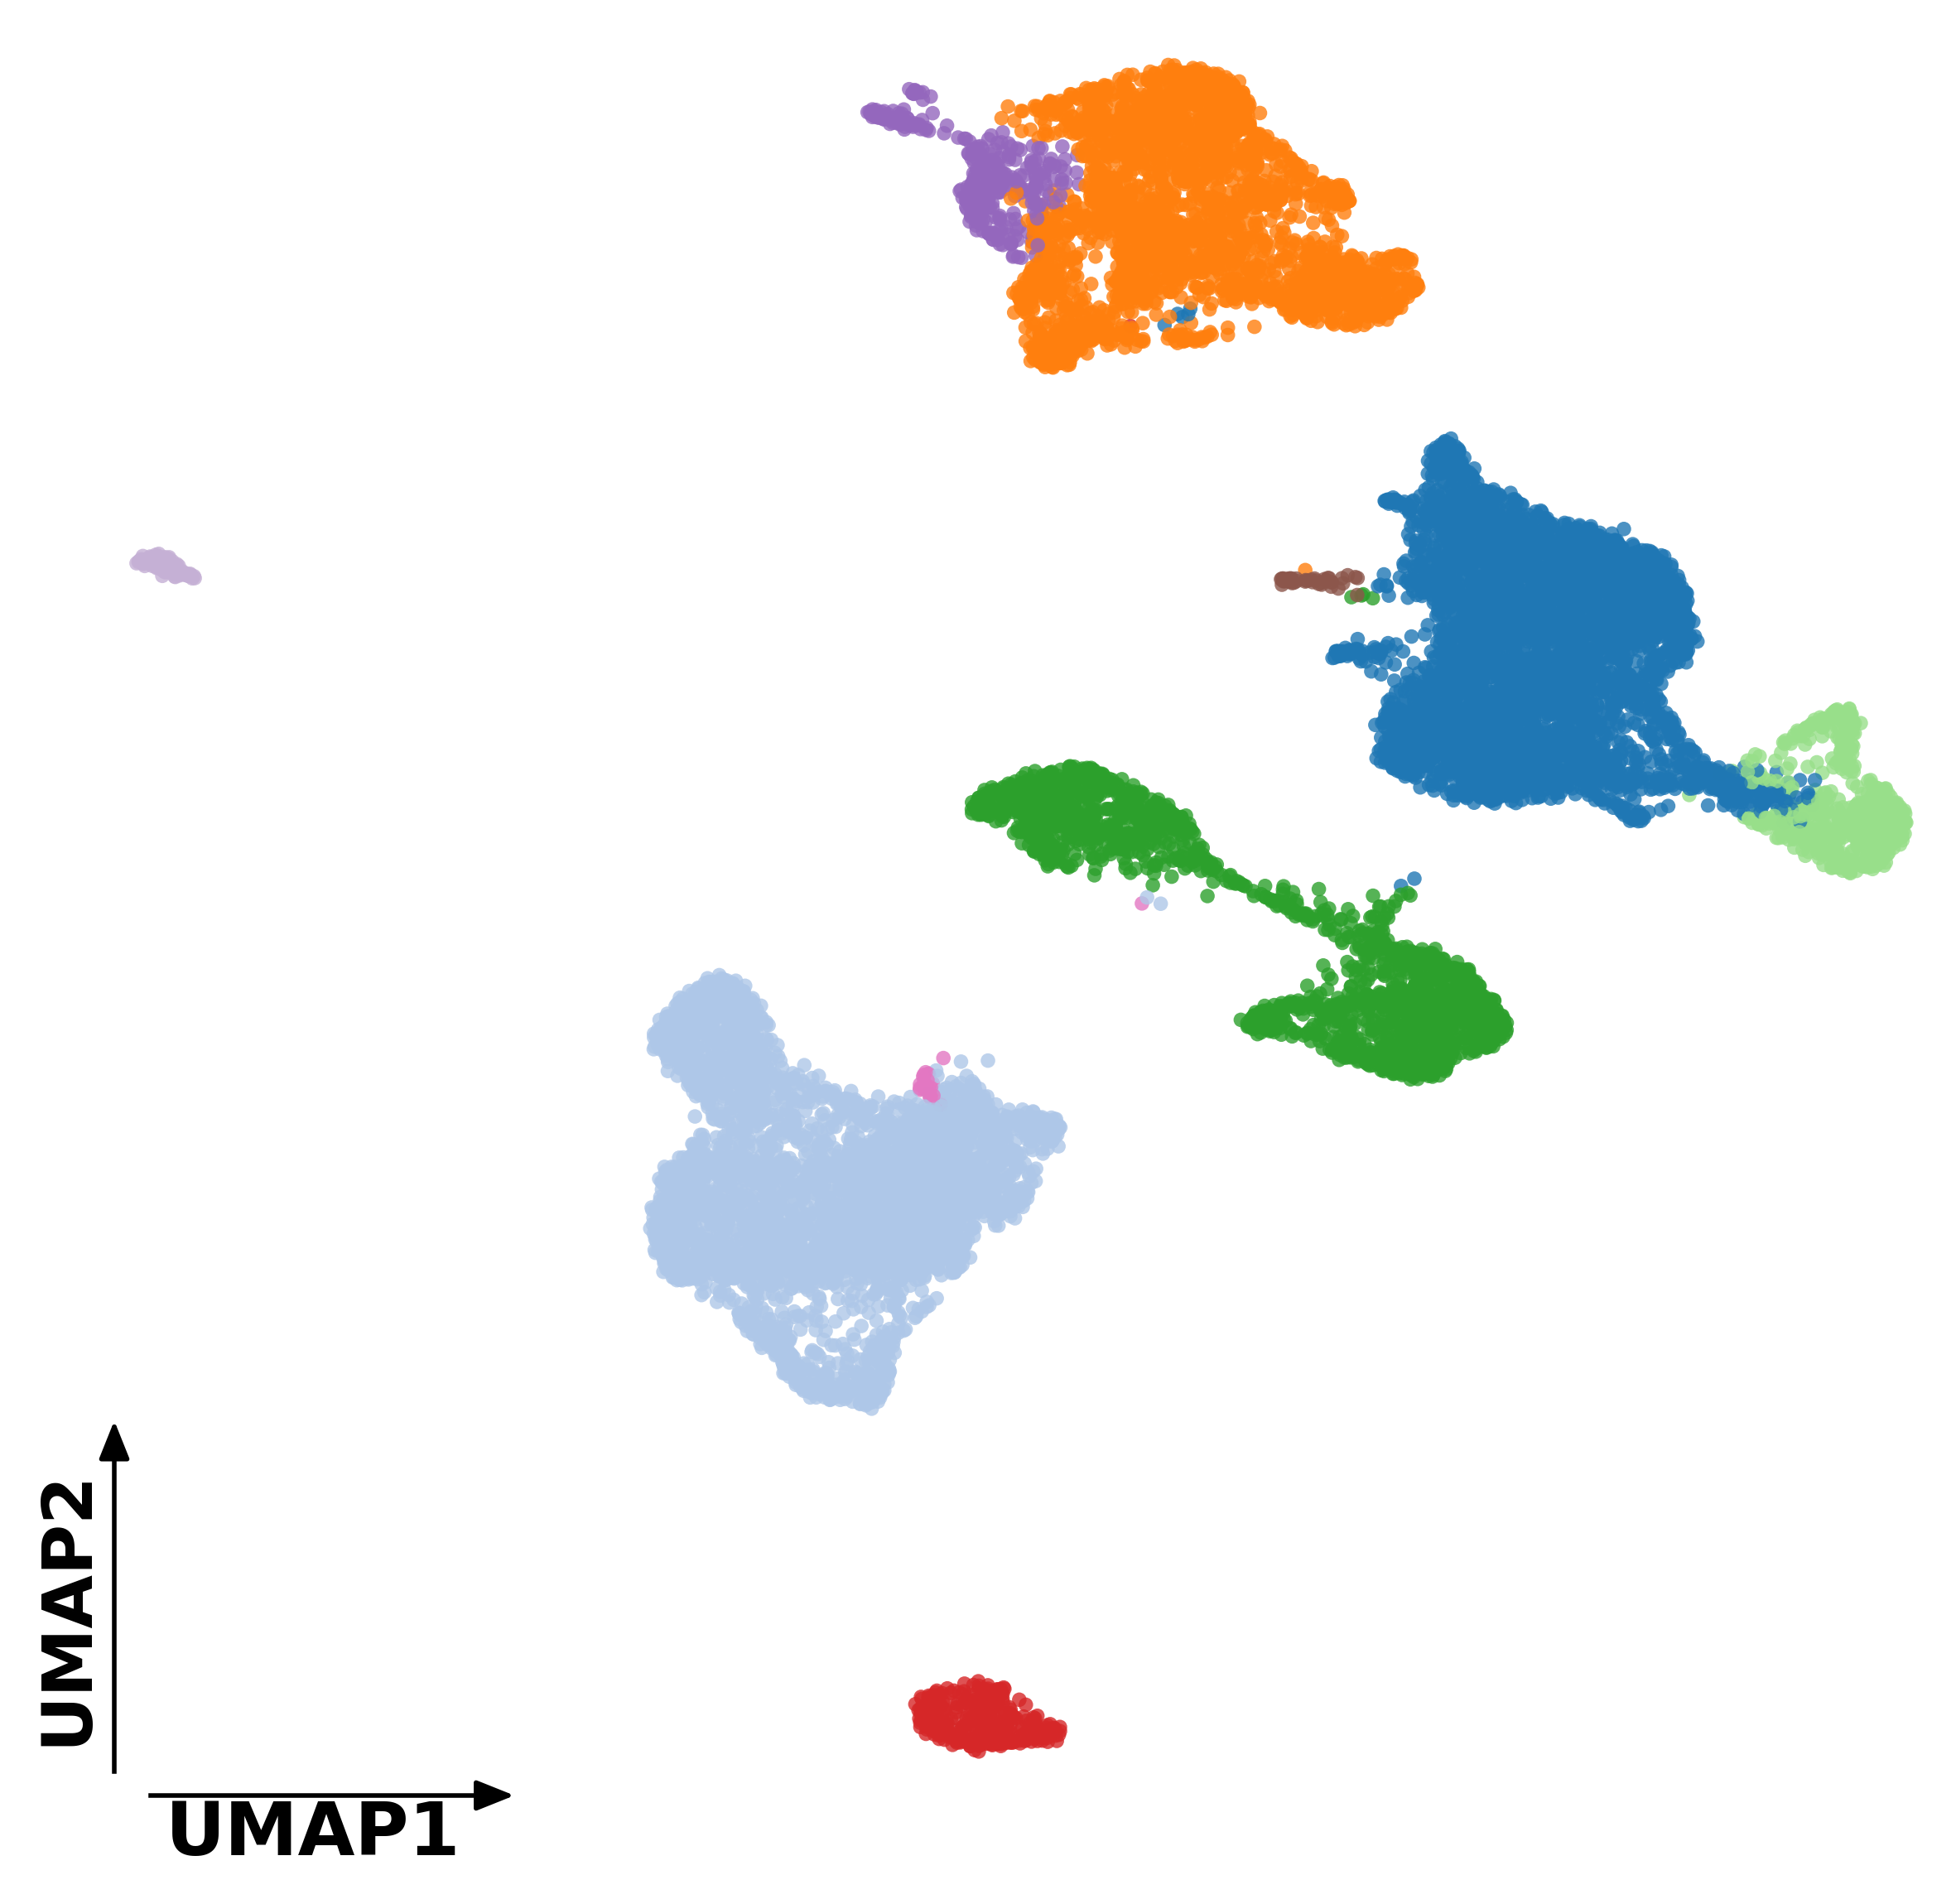

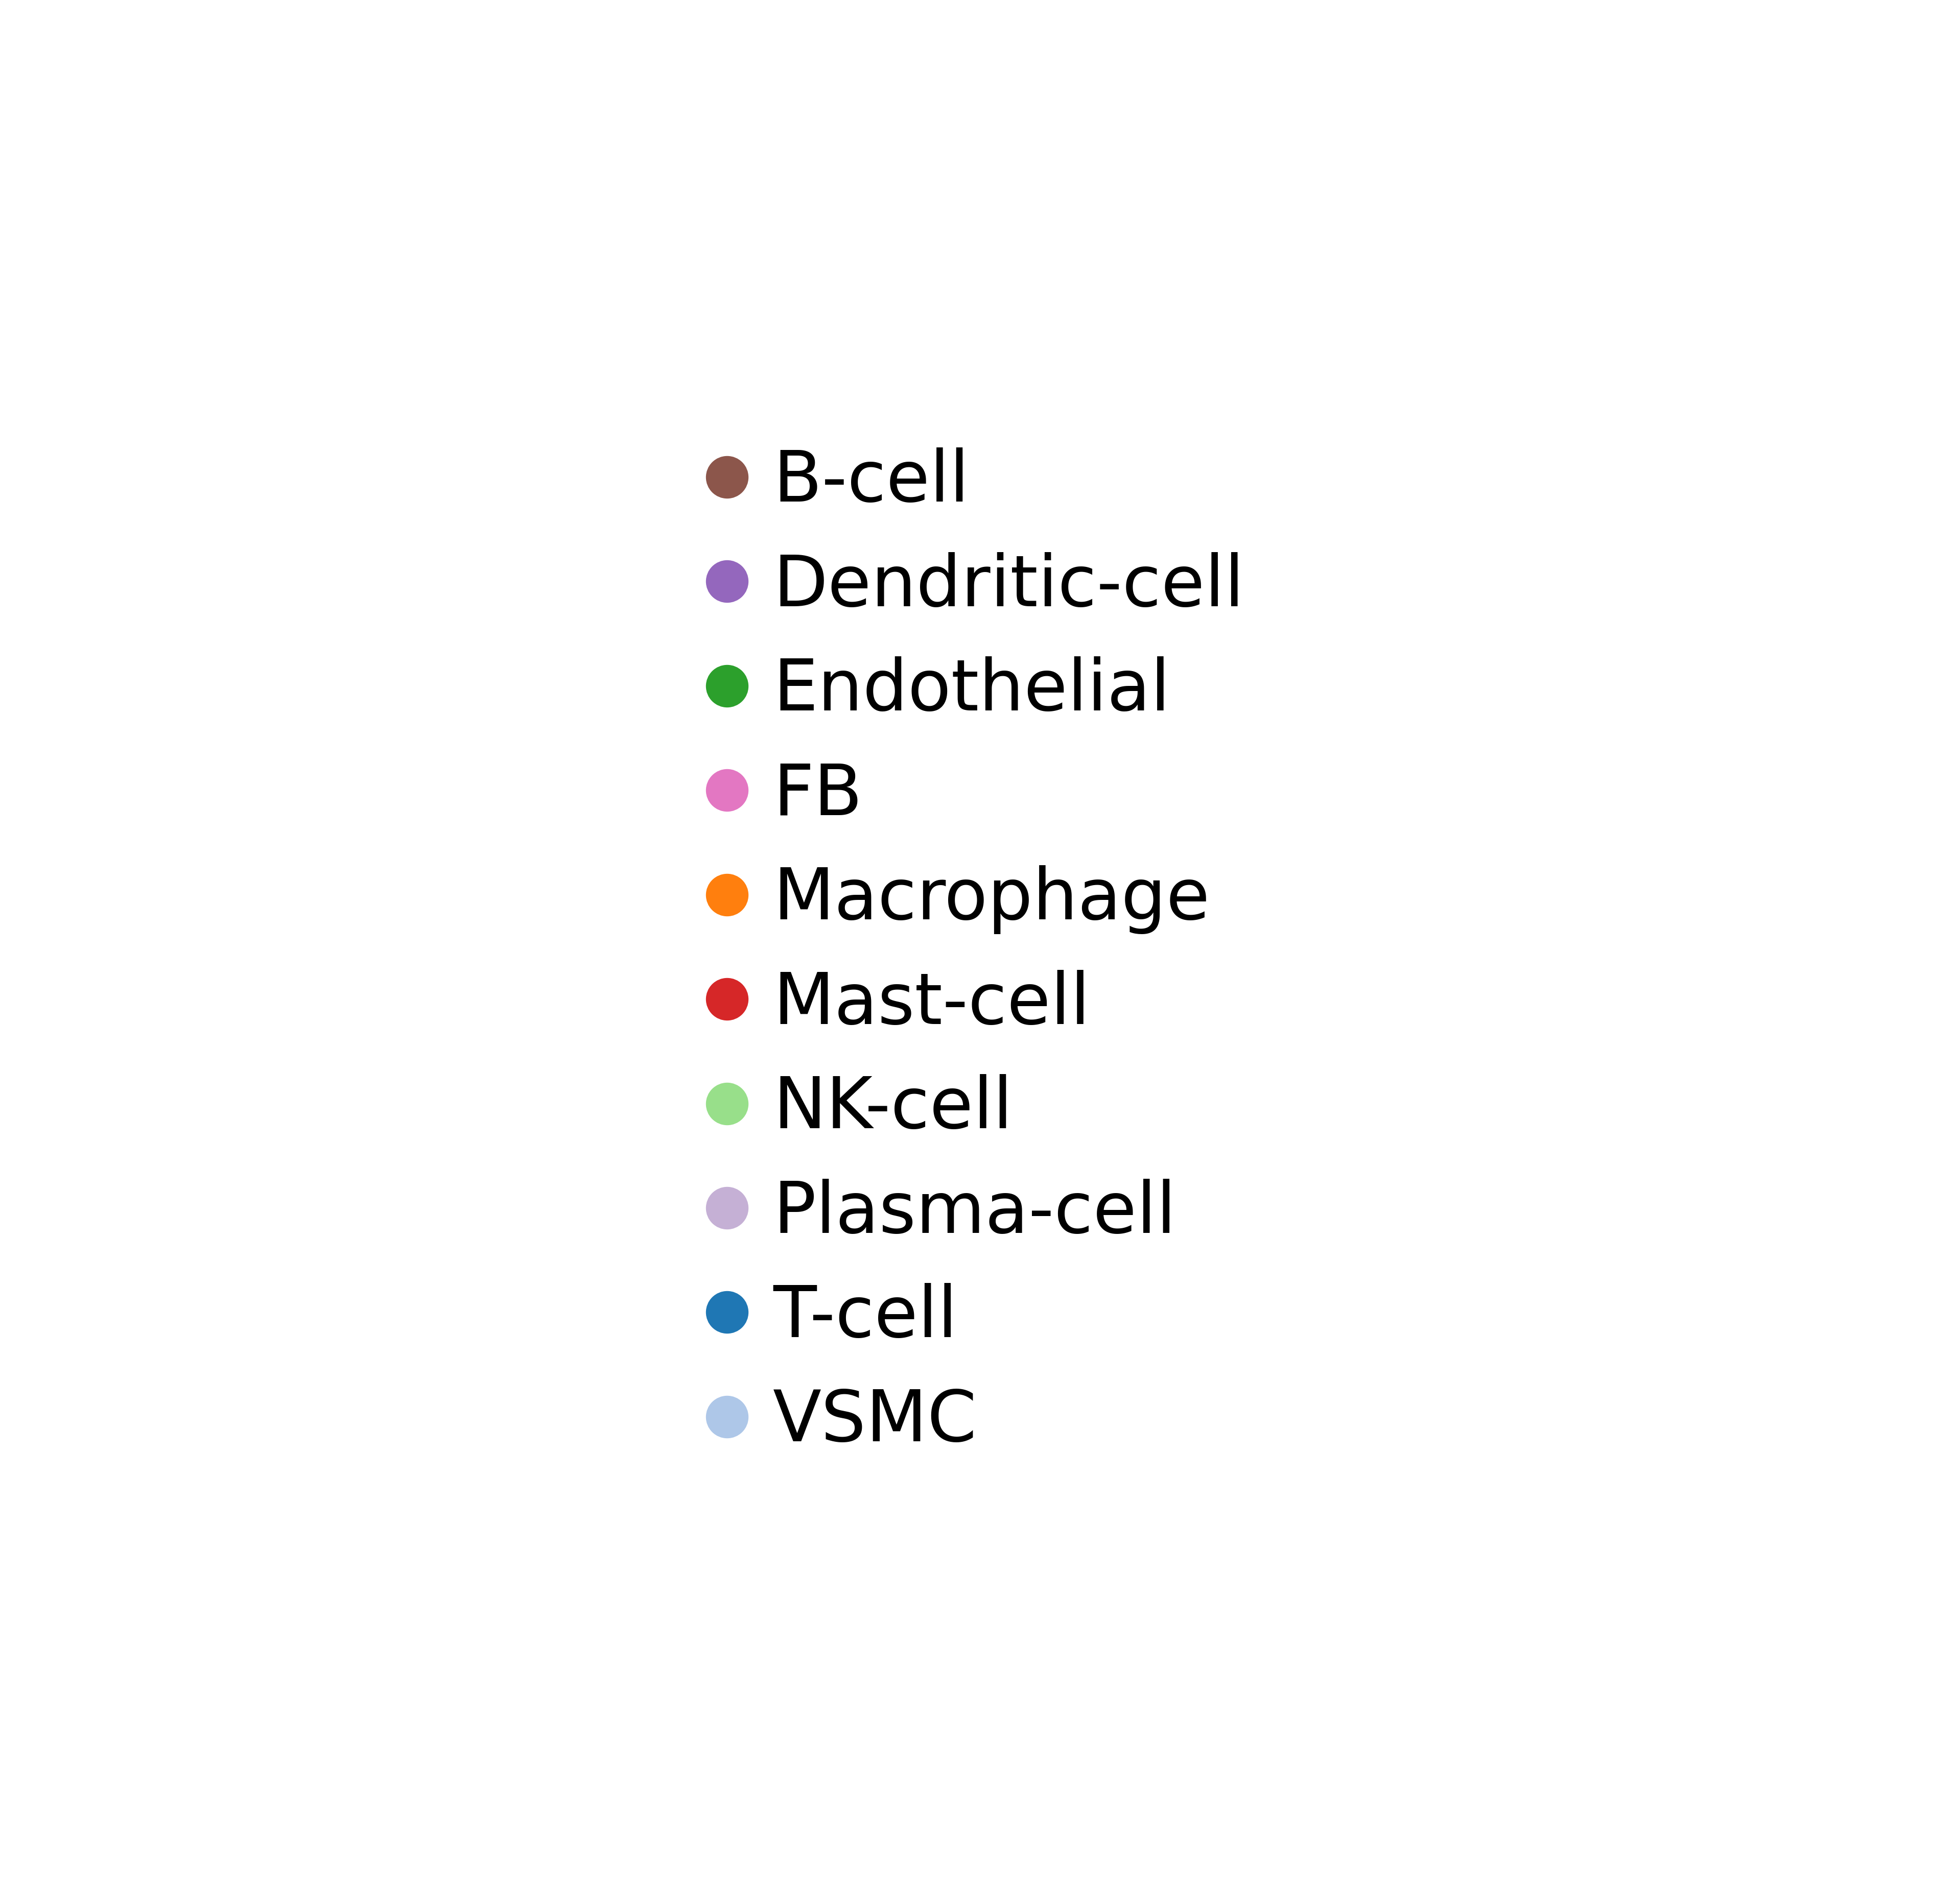

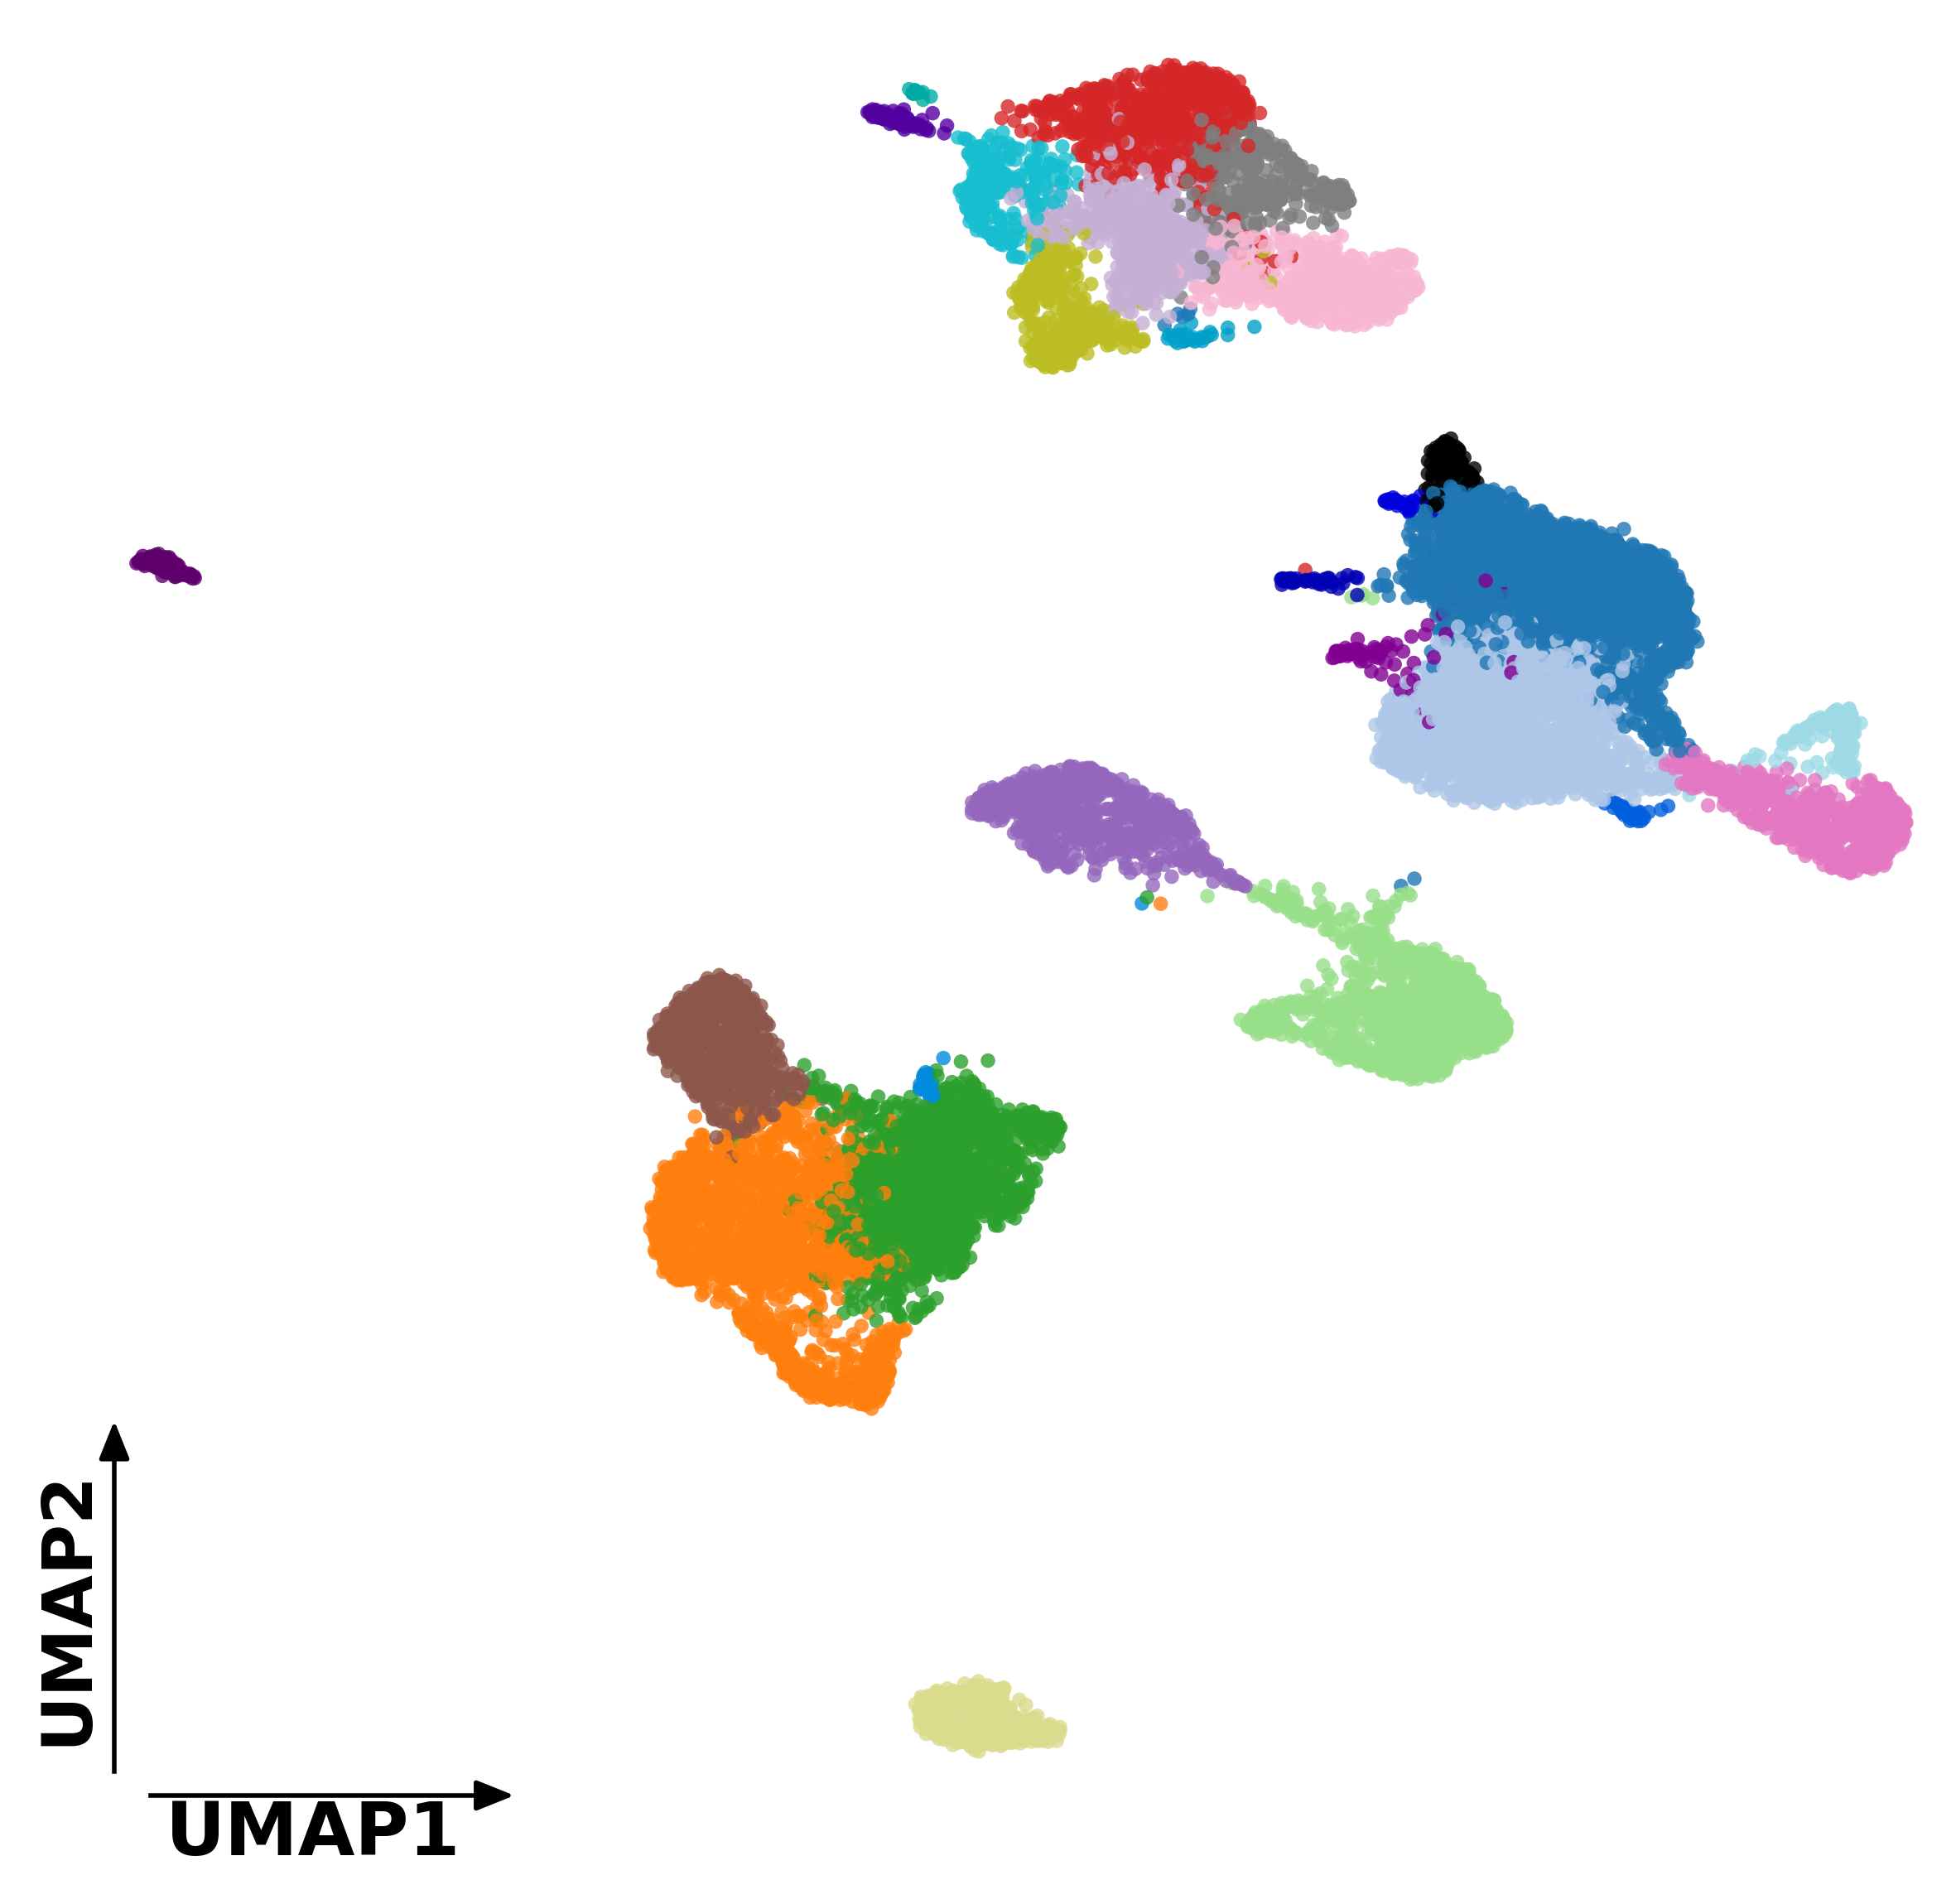

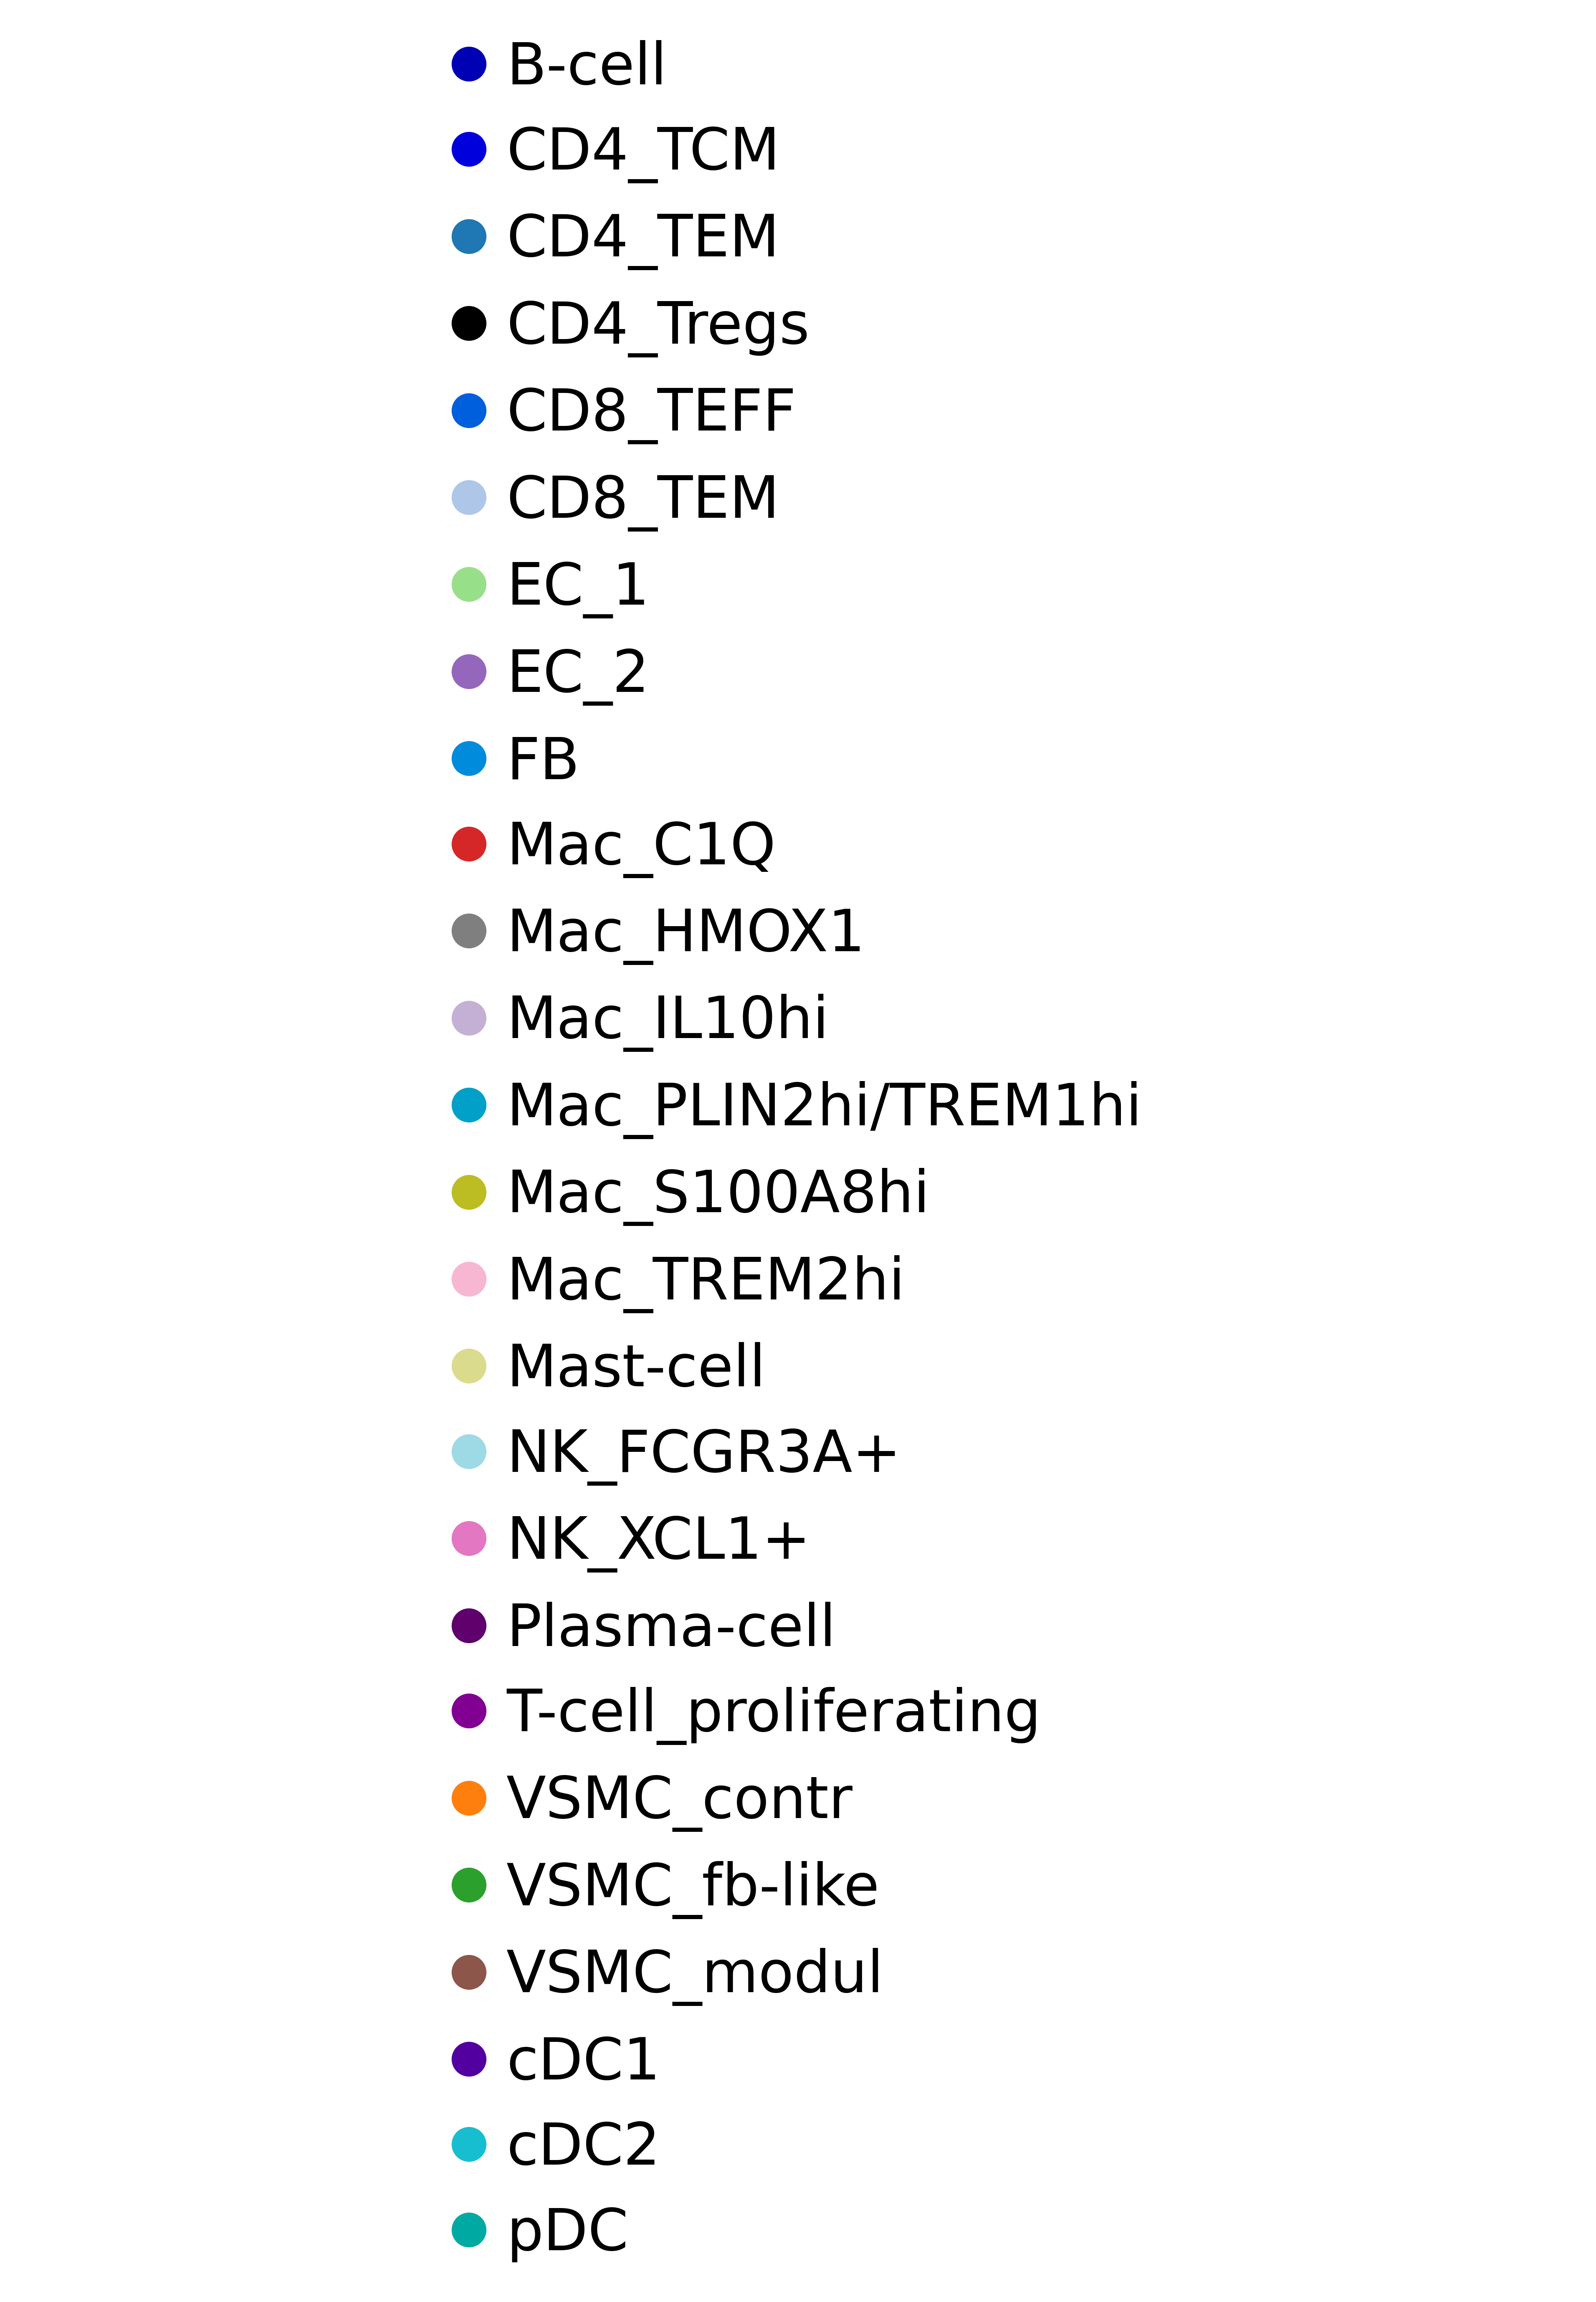

In [17]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
proc_dir='../../xenium_data/processed_data/baysor_processed_output'


for intron_status in ['with_intron','without_intron'][:1]:  
    
    for ref_genome in ref_genomes[:1]:
        
        adata=adata_dict[intron_status][ref_genome]
    
        cell_cols=['final_high_level_celltype','final_low_level_celltype']
    
        #adata.obs=adata.obs.drop(columns=['final_high_level_celltypes','final_low_level_celltypes'])
        
        for n,col in enumerate(cell_cols[:]):
            ncols=1
            nrows=1#int(np.ceil(len(cell_cols)/ncols))
            #fig=plt.figure(figsize=(ncols*5,nrows*4.5))
            width_adj_param=7
            height_adj_param=7
            heigh_width_ratio=height_adj_param/width_adj_param
    
            for leg_loc in ["on data",'right margin'][1:]:
            
                fig,ax=plt.subplots(1,1,figsize=(ncols*width_adj_param,nrows*height_adj_param))
        
                #ax=fig.add_subplot(nrows,ncols,n+1) 
        
                #suptitle='-'.join([panel,param_set_string,f'\ncells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}'])
                
                suptitle=f"scRNA-seq - {col.split('final_')[-1].replace('_',' ').capitalize()}"
                #fig.suptitle(suptitle,fontweight='bold',fontsize=10,y=0.94,x=0.5)
                #leg_loc='right margin'
    
                ### CREATE COLOR MAPPING FOR THE CLUSTERS
                #. As there are more than 20 clusters, for the N most populous clusters choose distinc colours, for less populous clusters colors that are similar suffices
                # Select distinct colors for top N categories 
                sorted_categories=adata.obs[col].value_counts()
                N_distinct = 16  # Number of highly distinguishable colors
                distinct_cmap = plt.cm.get_cmap('tab20', N_distinct)  # Or try 'hsv', 'gist_ncar'
        
                # Generate a gradient colormap for remaining categories
                remaining_categories = len(sorted_categories)# - N_distinct
                #remaining_colors = list(mcolors.CSS4_COLORS.values())[:remaining_categories]  # Use Tableau colors
                #remaining_colors = list(mcolors.XKCD_COLORS.values())[:remaining_categories]  # Use Tableau colors
                remaining_cmap = plt.cm.get_cmap('nipy_spectral', remaining_categories)  # Or try 'hsv', 'gist_ncar' 'nipy_spectral'
            
        
                
                # Create color mapping
                clusters_color_mapping = {}
        
                # Assign gradient-based colors to the remaining categories
                for i, cat in enumerate(sorted_categories[:N_distinct].index):
                    #print(i / remaining_categories)
                    clusters_color_mapping[cat] = distinct_cmap(i)
                
                # Assign distinct colors to the top categories
                for i, cat in enumerate(sorted_categories[N_distinct:].index):
                    clusters_color_mapping[cat] = remaining_cmap(i)
        
                #if col in cell_cols:
                #   leg_loc="on data"
                sc.pl.umap(adata, 
                           color=col,
                           show=False,
                           palette=clusters_color_mapping,
                           ax=ax,
                           size=18,
                           #vmin=0.5,
                           #vmax=1,
                           s=40,
                           vmin='p1',
                           vmax='p99',
                           alpha=0.8,
                           legend_fontsize=8,
                           legend_fontweight='semibold',
                           legend_loc=leg_loc)
        
                
                ax.set_title(None)
                            
                #ax.set_xlabel('UMAP1',fontsize=12, fontweight='bold',x=0.15*(height_adj_param/width_adj_param))
                #ax.set_ylabel('UMAP2',fontsize=12, fontweight='bold',y=0.15)
                ax.set_xlabel(None)
                ax.set_ylabel(None)
        
                 # Adding small x and y axes in the lower-left corner
                ax.spines['bottom'].set_color('black')
                ax.spines['bottom'].set_linewidth(1)
                ax.spines['left'].set_color('black')
                ax.spines['left'].set_linewidth(1)
                
                # Hide top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
    
                ## As there is some epmty space on the lower an higher values of both x and y axis, make the x and y axes bit shorter
                # in order to enlarge the UMAP area containing dots
                ax.set_xlim(ax.get_xlim()[0]*0.87,ax.get_xlim()[1]*0.95)
                ax.set_ylim(ax.get_ylim()[0]*0.95,ax.get_ylim()[1]*0.95)
        
                # Set custom limits for small axes
                # Set custom bounds for equally long axes
                # Set custom limits for small axes
                # Set custom bounds for equally long axes
    
                x_axis_length = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.2  # Define axis length
                x_axis_offset=x_axis_length*0.1
                #x_axis_offset=x_axis_length*1
                y_axis_length = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.2 * (1/heigh_width_ratio)  # Define axis length
                y_axis_offset=x_axis_offset#y_axis_length*0.1 
                
                x_start, x_end = ax.get_xlim()[0]+x_axis_offset, ax.get_xlim()[0] + x_axis_length
                y_start, y_end = ax.get_ylim()[0]+y_axis_offset, ax.get_ylim()[0] + y_axis_length
                
                ax.spines['bottom'].set_bounds(x_start, x_end)
                ax.spines['left'].set_bounds(y_start, y_end)
                
                # Add arrows to axis tips
                arrow_style = mpatches.ArrowStyle("-|>", head_length=0.5, head_width=0.2)
                ax.annotate('', xy=(x_end+0.8, ax.get_ylim()[0]), xytext=(x_end - 0.001 * x_axis_length, ax.get_ylim()[0]), 
                            arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
                ax.annotate('', xy=(ax.get_xlim()[0], y_end+0.8), xytext=(ax.get_xlim()[0], y_end - 0.001 * y_axis_length), 
                            arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
        
                
                ## Add label titles
                ax_label_offset=0.8
                ax.text((x_start+x_end)/2, 
                         ax.get_ylim()[0]-ax_label_offset,
                        'UMAP1',
                        weight='bold',
                        fontsize=16,
                        horizontalalignment='center',
                        #verticalalignment='center',
                        verticalalignment='center_baseline')
                
                ax.text(ax.get_xlim()[0]-ax_label_offset,#*(heigh_width_ratio),
                        (y_start+y_end)/2,
                        'UMAP2',
                        weight='bold',
                        fontsize=15, 
                        horizontalalignment='center',
                        rotation_mode='anchor',
                        rotation=90,
                        verticalalignment='center')
                
    
                # If there is a legend, remove it and add a customized one
                if leg_loc=='right margin':
                    
                    ax.legend_.remove()
    
                    
                    legend_handles=[Line2D([0],[0],marker="o",color=c,lw=0,label=l,markerfacecolor=c,markersize=7,)
                                        for l, c in zip(list(adata.obs[col].cat.categories), adata.uns[f"{col}_colors"])]
                    '''                
                    # Make new Legend
                    l1 = ax.legend(handles=legend_handles,                
                                   frameon=False,
                                   ncols=1,
                                   loc='upper left',
                                   bbox_to_anchor=(1, 0.75),
                                   #title="Cell type",
                                  )
                    '''             
        
                ## SAvefig    
                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','UMAP'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig2','UMAP',f'{ref_genome}_{intron_status}_{col}_legend_{leg_loc}_UMAP.png')
                fig.savefig(fn, dpi=300, bbox_inches='tight')
                
                ##### SAVE LEGEND FOR CELL TYPE AND REGIONS AS SEPARATE FIGURES
                if leg_loc=='right margin':
                    # Create a new figure for the legend
                    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
                    legend_ax.axis('off')  # Turn off the axis for a clean legend
                    l1 = legend_ax.legend(handles=legend_handles,                
                                           frameon=False,
                                           ncols=1,
                                           markerscale=2,
                                           fontsize=25,
                                           loc='center',
                                           #bbox_to_anchor=(1, 0.75),
                                           #title="Cell type",
                                                )
    
                    os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','UMAP'),exist_ok=True)
                    fn=os.path.join(proc_dir,'figure_plots','Fig2','UMAP',f'{ref_genome}_{intron_status}_{col}_legend_{leg_loc}_UMAP_legend.png')
                    legend_fig.savefig(fn, dpi=300, bbox_inches='tight')

                
                ### Save source data for plot               
                umap_coords_df=pd.DataFrame(data=adata.obsm['X_umap'],
                                             columns=['UMAP1','UMAP2'],
                                             index=adata.obs_names)    
                source_df=pd.concat([umap_coords_df,adata.obs.loc[umap_coords_df.index,col]],axis=1)
                source_df.index.name='Cell_ID'
                
                source_dir=os.path.join(proc_dir,'source_data','first_revision')
                os.makedirs(source_dir,exist_ok=True)

                if col=='final_high_level_celltype':                        
                    fn=os.path.join(source_dir,'Fig2D.xlsx')
                
                if col=='final_low_level_celltype':                        
                    fn=os.path.join(source_dir,'Fig2E.xlsx')

                source_df.to_excel(fn)


,UMAP1,UMAP2,final_low_level_celltype
TTCAATCAGGTGATCG-1,13.142877,0.411826,EC_1
GTATTTCGTGGATACG-1,7.769873,21.376660,cDC2
GGGATGAAGAAATTGC-1,7.798682,19.579952,cDC2
TTGTGGAAGGTGCAGT-1-3,5.374227,-2.385345,VSMC_fb-like
GGTTGTACACCATATG-1-2,10.279885,20.055683,Mac_IL10hi
...,...,...,...
GGGACCTCAAGGTTCT-1,4.391837,-1.188159,VSMC_fb-like
ATCGATGCACGTAACT-1,5.106092,-9.168180,VSMC_contr
TGACTTTGTCCAACTA-1,14.049734,7.629033,CD8_TEM
TTAGGCAGTACGCTTA-1-1,13.091784,-0.462334,EC_1


In [ ]:
colors=['final_low_level_celltypes']+['ENSG00000183765', 'ENSG00000225746',
                                      'ENSG00000248323', 'ENSG00000249669', 'ENSG00000198670', 'ENSG00000170160', 'ENSG00000150337', 'ENSG00000069122', 'ENSG00000133392']
ncols=2
nrows=int(np.ceil(len(colors)/ncols))

fig=plt.figure(figsize=(ncols*5,nrows*5))


for n,cellt in enumerate(colors):
    
    try:
        ax=fig.add_subplot(nrows,ncols,n+1)
        sc.pl.umap(adata, color=cellt,
                   ax=ax,
                   show=False,
                   size=12.5,
                   vmin='p1',
                   vmax='p99',
                   legend_fontsize=5.5,
                   ncols=1,
                   legend_loc='on data',
                   layer='acosh')
        if n>0:
            ax.set_title(adata.var.loc[cellt,'HGNC_NAME'])
    except KeyError:
        print(f'Could not find {cellt} in data!')
        continue


In [ ]:
{l:c for l, c in zip(list(adata.obs[col].cat.categories), adata.uns[f"{col}_colors"]}